In [49]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import EMD

os.chdir("/mnt/data/ProjetMeteo/Analyse_Meteo")
Path.cwd()

raw_french_temp_array = np.load("month_mean_serie.npy")

In [50]:
import pandas as pd

# ==============================================================================
# 1. PARSE THE RAW TEXT FILES
# ==============================================================================
# sep='\s+' instructs pandas to treat any amount of consecutive whitespace as a single delimiter.
# na_values=[-99.9, -99.90] captures the standard NOAA missing data flags.

# Load North Atlantic Oscillation
df_nao = pd.read_csv("demo_france/NAO.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)

# Load East Atlantic Pattern
df_ea = pd.read_csv("demo_france/EA.txt", sep='\s+', na_values=[-99.9, -99.90])

# ==============================================================================
# 2. STANDARDIZE THE COLUMNS
# ==============================================================================
# Ensure the columns are strictly named for accurate merging
df_nao.columns = ['Year', 'Month', 'NAO']
df_ea.columns = ['Year', 'Month', 'EA']

# ==============================================================================
# 3. MERGE INTO THE MASTER CLIMATE MATRIX
# ==============================================================================
# We perform an 'inner' merge on the Year and Month columns. 
# This strictly enforces temporal alignment. If a month is missing in one file, 
# it drops the row to prevent out-of-phase signal corruption.
df_climate = pd.merge(df_nao, df_ea, on=['Year', 'Month'], how='inner')

# ==============================================================================
# 4. BUILD THE CHRONOLOGICAL TIME INDEX
# ==============================================================================
# Convert the discrete Year and Month integer columns into a continuous DateTime object.
# We assign '01' as the day for every month to satisfy the DateTime requirement.
df_climate['Date'] = pd.to_datetime(
    df_climate['Year'].astype(str) + '-' + df_climate['Month'].astype(str) + '-01'
)

# Set the continuous Date vector as the strict mathematical index of the DataFrame
df_climate.set_index('Date', inplace=True)

# Drop the now redundant discrete temporal columns
df_climate.drop(columns=['Year', 'Month'], inplace=True)

# ==============================================================================
# 5. VERIFY MATRIX INTEGRITY
# ==============================================================================
print(df_climate.info())
print("\nFirst 5 rows:")
print(df_climate.head())

<class 'pandas.DataFrame'>
DatetimeIndex: 915 entries, 1950-01-01 to 2026-03-01
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NAO     915 non-null    float64
 1   EA      915 non-null    float64
dtypes: float64(2)
memory usage: 21.4 KB
None

First 5 rows:
             NAO    EA
Date                  
1950-01-01  0.92 -2.71
1950-02-01  0.40  0.66
1950-03-01 -0.36  0.82
1950-04-01  0.73  0.28
1950-05-01 -0.59 -0.51


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_744259/45244839.py:10: SyntaxWarning: invalid escape sequence '\s'
  df_nao = pd.read_csv("demo_france/NAO.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)
/tmp/ipykernel_744259/45244839.py:13: SyntaxWarning: invalid escape sequence '\s'
  df_ea = pd.read_csv("demo_france/EA.txt", sep='\s+', na_values=[-99.9, -99.90])


In [51]:
df_climate = df_climate[:912]
df_climate['raw'] = raw_french_temp_array

In [ ]:
df_sca = pd.read_csv("demo_france/SCA.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)

df_amo = pd.read_csv("demo_france/AMO.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)

df_pdo = pd.read_csv("demo_france/PDO.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_744259/3345909977.py:1: SyntaxWarning: invalid escape sequence '\s'
  df_sca = pd.read_csv("demo_france/SCA2.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)
/tmp/ipykernel_744259/3345909977.py:3: SyntaxWarning: invalid escape sequence '\s'
  df_amo = pd.read_csv("demo_france/AMO.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)
/tmp/ipykernel_744259/3345909977.py:5: SyntaxWarning: invalid escape sequence '\s'
  df_pdo = pd.read_csv("demo_france/PDO.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)


In [53]:
# ==============================================================================
# 1. DYNAMIC COLUMN MAPPING
# ==============================================================================
# Reset the index to ensure no data is hidden in the index structure
df_raw = df_pdo
df_raw = df_raw.reset_index(drop=True)

# Dynamically assess the shape of the imported matrix
num_cols = df_raw.shape[1]

if num_cols == 14:
    # Condition A: The arbitrary index (0, 1, 2) was parsed as a data column
    df_raw.columns = ['Drop_Index', 'Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    df_clean = df_raw.drop(columns=['Drop_Index'])
elif num_cols == 13:
    # Condition B: The data parsed strictly as Year + 12 Months
    df_raw.columns = ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    df_clean = df_raw.copy()
else:
    raise ValueError(f"Matrix Dimension Error: Expected 13 or 14 columns, but detected {num_cols}.")

# ==============================================================================
# 2. CLEANING THE DATA MATRIX
# ==============================================================================
# Remove the faulty row and replace placeholders
# We force 'Year' to numeric first to ensure strict equality checking
df_clean['Year'] = pd.to_numeric(df_clean['Year'], errors='coerce')
df_clean = df_clean.dropna(subset=['Year']) # Drop if the header row was imported as data
df_clean = df_clean[df_clean['Year'] != -9999]
df_clean = df_clean.replace(-9999.00, np.nan)

# ==============================================================================
# 3. STRUCTURAL TRANSFORMATION (WIDE TO LONG)
# ==============================================================================
# Melt the dataframe: Year remains the identifier, months become a variable column
df_long = df_clean.melt(id_vars=['Year'], var_name='Month', value_name='Target_Value')

# Map string months to integers for datetime conversion
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df_long['Month_Num'] = df_long['Month'].map(month_map)

# ==============================================================================
# 4. TIME SERIES INDEXING
# ==============================================================================
# Construct standard Datetime objects (YYYY-MM-01)
# Ensure Year is strictly an integer string for the datetime parser
df_long['Date'] = pd.to_datetime(
    df_long['Year'].astype(int).astype(str) + '-' + 
    df_long['Month_Num'].astype(str) + '-01'
)

# Sort chronologically
df_ts = df_long.sort_values('Date')

# Set the Date as the index and isolate the single dimension
df_1d = df_ts.set_index('Date')[['Target_Value']]

# Drop the future unrecorded months
df_final = df_1d.dropna()


In [56]:
df_climate = df_climate[:912]
df_climate['AMO'] = df_amo[2][:912].values
df_climate['SCA'] = df_sca[2][:912].values
df_climate['PDO'] = df_final.values
df_climate

,NAO,EA,raw,AMO,PDO,SCA
Date,,,,,,
1950-01-01,0.9200,-2.71,2.148903,-0.03,-1.61,0.78
1950-02-01,0.4000,0.66,5.969903,-0.13,-2.17,-0.94
1950-03-01,-0.3600,0.82,7.083308,-0.16,-1.89,-0.22
1950-04-01,0.7300,0.28,8.031222,-0.22,-1.99,0.46
1950-05-01,-0.5900,-0.51,13.992700,-0.23,-3.19,0.28
...,...,...,...,...,...,...
2025-08-01,0.2588,1.71,20.582577,0.83,-3.23,-1.60
2025-09-01,-0.7994,3.60,15.437160,0.76,-2.31,0.52
2025-10-01,-0.9584,0.08,12.110127,1.01,-2.37,-0.84


In [57]:
from PyEMD import CEEMDAN
from scipy.fft import fft, fftfreq

def compute_dominant_period(time_series, sampling_interval=1.0):
    """
    Computes the dominant period of a discrete time series using the Fast Fourier Transform (FFT).
    
    Parameters:
    time_series (ndarray): The 1D input array (e.g., an isolated IMF).
    sampling_interval (float): The time between samples (default 1.0 month).
    
    Returns:
    float: The dominant period in the same units as the sampling interval.
    """
    N = len(time_series)
    # Subtract mean to remove the zero-frequency (DC) component
    yf = fft(time_series - np.mean(time_series))
    xf = fftfreq(N, d=sampling_interval)
    
    # Isolate positive frequencies (Nyquist limit)
    positive_freq_indices = np.where(xf > 0)
    frequencies = xf[positive_freq_indices]
    power_spectrum = np.abs(yf[positive_freq_indices])**2
    
    if len(power_spectrum) == 0:
        return np.inf
        
    # Extract the period of maximum spectral power
    peak_idx = np.argmax(power_spectrum)
    dominant_freq = frequencies[peak_idx]
    
    return 1.0 / dominant_freq if dominant_freq > 0 else np.inf

def extract_ceemdan_cycle_fft(time_series, min_period_months, max_period_months, trials=1000, epsilon=0.2):
    """
    Executes CEEMDAN and reconstructs the signal autonomously by selecting IMFs 
    whose dominant FFT periods fall strictly within the defined target band.
    
    Parameters:
    time_series (ndarray or Series): The raw 1D input data.
    min_period_months (float): The minimum acceptable period (e.g., 60 for 5 years).
    max_period_months (float): The maximum acceptable period (e.g., 240 for 20 years).
    trials (int): Ensemble size.
    epsilon (float): Standard deviation of added noise relative to the signal.
    
    Returns:
    ndarray: The reconstructed time series.
    ndarray: The full matrix of all extracted IMFs.
    list: The integer indices of the dynamically retained IMFs.
    """
    s = np.array(time_series)
    ponderated_epsilon = epsilon * np.std(s)
    ceemdan = CEEMDAN(parallel=True, seed=0, trials= trials, epsilon=ponderated_epsilon)
    
    
    print(f"Executing CEEMDAN... (Length: {len(s)})")
    all_imfs = ceemdan(s)
    
    reconstructed_cycle = np.zeros(len(s))
    num_imfs = all_imfs.shape[0] - 1  # Exclude the residual (last row)
    retained_indices = []
    
    for i in range(num_imfs):
        period = compute_dominant_period(all_imfs[i])
        
        # Evaluate against the defined physical bandpass bounds
        if min_period_months <= period <= max_period_months:
            reconstructed_cycle += all_imfs[i]
            retained_indices.append(i)
            print(f"  -> Retaining IMF {i} (Dominant Period: {period:.2f} months)")
        else:
            print(f"  -> Discarding IMF {i} (Dominant Period: {period:.2f} months)")
            
    return reconstructed_cycle, all_imfs, retained_indices

# ==============================================================================
# EXECUTION AND RECONSTRUCTION
# ==============================================================================
# Define the target physical band in months. 
# Example: > 5 years (60 months) and < 30 years (360 months) to isolate decadal cycles
target_min_months = 180.0
target_max_months = 912.0

print("Processing Atlantic Multidecadal Oscillation (AMO)...")
amo_cycle, amo_all_imfs, amo_kept = extract_ceemdan_cycle_fft(df_climate['AMO'], target_min_months, target_max_months)

print("\nProcessing Target Temperature (Y)...")
y_cycle, y_all_imfs, y_kept = extract_ceemdan_cycle_fft(df_climate['raw'], target_min_months, target_max_months)

print("\nProcessing North Atlantic Oscillation (NAO)...")
nao_cycle, nao_all_imfs, nao_kept = extract_ceemdan_cycle_fft(df_climate['NAO'], target_min_months, target_max_months)

print("\nProcessing East Atlantic Pattern (EA)...")
ea_cycle, ea_all_imfs, ea_kept = extract_ceemdan_cycle_fft(df_climate['EA'], target_min_months, target_max_months)

print("\nProcessing Scandinavian Blocking (SCA)...")
sca_cycle, sca_all_imfs, sca_kept = extract_ceemdan_cycle_fft(df_climate['SCA'], target_min_months, target_max_months)

print("\nProcessing Pacific Decadal Oscillation (PDO)...")
pdo_cycle, pdo_all_imfs, pdo_kept = extract_ceemdan_cycle_fft(df_climate['PDO'], target_min_months, target_max_months)

# ==============================================================================
# REBUILDING THE GAM FEATURE MATRIX
# ==============================================================================
# Insert the non-stationary, low-frequency cycles back into a new DataFrame
df_gam_filtered = pd.DataFrame({
    'Temp_Cycle': y_cycle,
    'NAO_Cycle': nao_cycle,
    'EA_Cycle': ea_cycle,
    'SCA_Cycle': sca_cycle,
    'AMO_Cycle': amo_cycle,
    # The secular trend is strictly the final row of the target temperature matrix
    'PDO_Cycle': pdo_cycle
})

print("\nCEEMDAN Data Engineering Complete. Ready for GAM Tensor Integration.")

Processing Atlantic Multidecadal Oscillation (AMO)...
Executing CEEMDAN... (Length: 912)
  -> Discarding IMF 0 (Dominant Period: 4.54 months)
  -> Discarding IMF 1 (Dominant Period: 12.16 months)
  -> Discarding IMF 2 (Dominant Period: 29.42 months)
  -> Discarding IMF 3 (Dominant Period: 43.43 months)
  -> Discarding IMF 4 (Dominant Period: 114.00 months)
  -> Retaining IMF 5 (Dominant Period: 228.00 months)

Processing Target Temperature (Y)...
Executing CEEMDAN... (Length: 912)
  -> Discarding IMF 0 (Dominant Period: 3.12 months)
  -> Discarding IMF 1 (Dominant Period: 12.00 months)
  -> Discarding IMF 2 (Dominant Period: 12.00 months)
  -> Discarding IMF 3 (Dominant Period: 28.50 months)
  -> Discarding IMF 4 (Dominant Period: 91.20 months)
  -> Retaining IMF 5 (Dominant Period: 182.40 months)
  -> Retaining IMF 6 (Dominant Period: 456.00 months)

Processing North Atlantic Oscillation (NAO)...
Executing CEEMDAN... (Length: 912)
  -> Discarding IMF 0 (Dominant Period: 3.37 months)
 

In [669]:
df_gam_filtered = pd.DataFrame({
    'Temp_Cycle': y_cycle,
    'NAO_Cycle': nao_cycle,
    'EA_Cycle': ea_cycle,
    'SCA_Cycle': sca_cycle,
    'AMO_Cycle': amo_cycle,
    # The secular trend is strictly the final row of the target temperature matrix
    'PDO_Cycle': pdo_cycle
})

In [338]:
import numpy as np
from scipy.signal import find_peaks

def calculate_terminal_truncation(target_wave: np.ndarray) -> int:
    """
    Computes the exact terminal index required to excise the CEEMDAN 
    unanchored spline artifact.
    """
    # 1. Isolate the mathematical derivatives (crests and troughs)
    maxima_indices, _ = find_peaks(target_wave)
    minima_indices, _ = find_peaks(-target_wave)
    
    # 2. Concatenate and chronologically sort all turning points
    all_extrema = np.sort(np.concatenate((maxima_indices, minima_indices)))
    
    if len(all_extrema) == 0:
        raise ValueError("No physical extrema found. Matrix is strictly monotonic.")
        
    # 3. Isolate the final physical anchor
    last_anchor_index = all_extrema[0]
    total_length = len(target_wave)
    
    # Calculate the unanchored tail
    artifact_length = last_anchor_index
    
    print(f"Total Array Length: {total_length}")
    print(f"Final Physical Anchor Index: {last_anchor_index}")
    print(f"Required Terminal Truncation: Drop the last {artifact_length} months.")
    
    return last_anchor_index

# Execution
# Replace 'y_target_imf' with your exact un-truncated multidecadal temperature array
optimal_end_index = calculate_terminal_truncation(y_all_imfs[5])

# The strict asymmetric truncation
# Keep all initial historical data (start at 0), slice strictly at the final anchor
#y_truncated = y_target_imf[:optimal_end_index]
#X_truncated = X_tensor[:optimal_end_index, :]

Total Array Length: 912
Final Physical Anchor Index: 47
Required Terminal Truncation: Drop the last 47 months.


In [339]:
df_gam_filtered = df_gam_filtered[47:901]

In [364]:
df_gam_filtered

,Temp_Cycle,NAO_Cycle,EA_Cycle,SCA_Cycle,AMO_Cycle,PDO_Cycle
0,-0.002871,-0.143496,-0.024832,-0.157613,0.025933,-1.293278
1,-0.003995,-0.144135,-0.024928,-0.158668,0.025877,-1.299060
2,-0.005381,-0.144729,-0.025012,-0.159718,0.025818,-1.304011
3,-0.007028,-0.145276,-0.025084,-0.160765,0.025757,-1.308100
4,-0.008929,-0.145774,-0.025143,-0.161809,0.025693,-1.311317
...,...,...,...,...,...,...
907,0.526352,-0.071511,0.239795,-0.168090,0.897886,-2.403774
908,0.524938,-0.069979,0.239824,-0.170429,0.897526,-2.398319
909,0.523350,-0.068308,0.239812,-0.172662,0.897039,-2.392047
910,0.521590,-0.066502,0.239759,-0.174782,0.896428,-2.385025


Rendering Spectral Matrix: Target Global Temperature
Mathematical Modes Extracted for Cyclic Tensor: [5, 6]


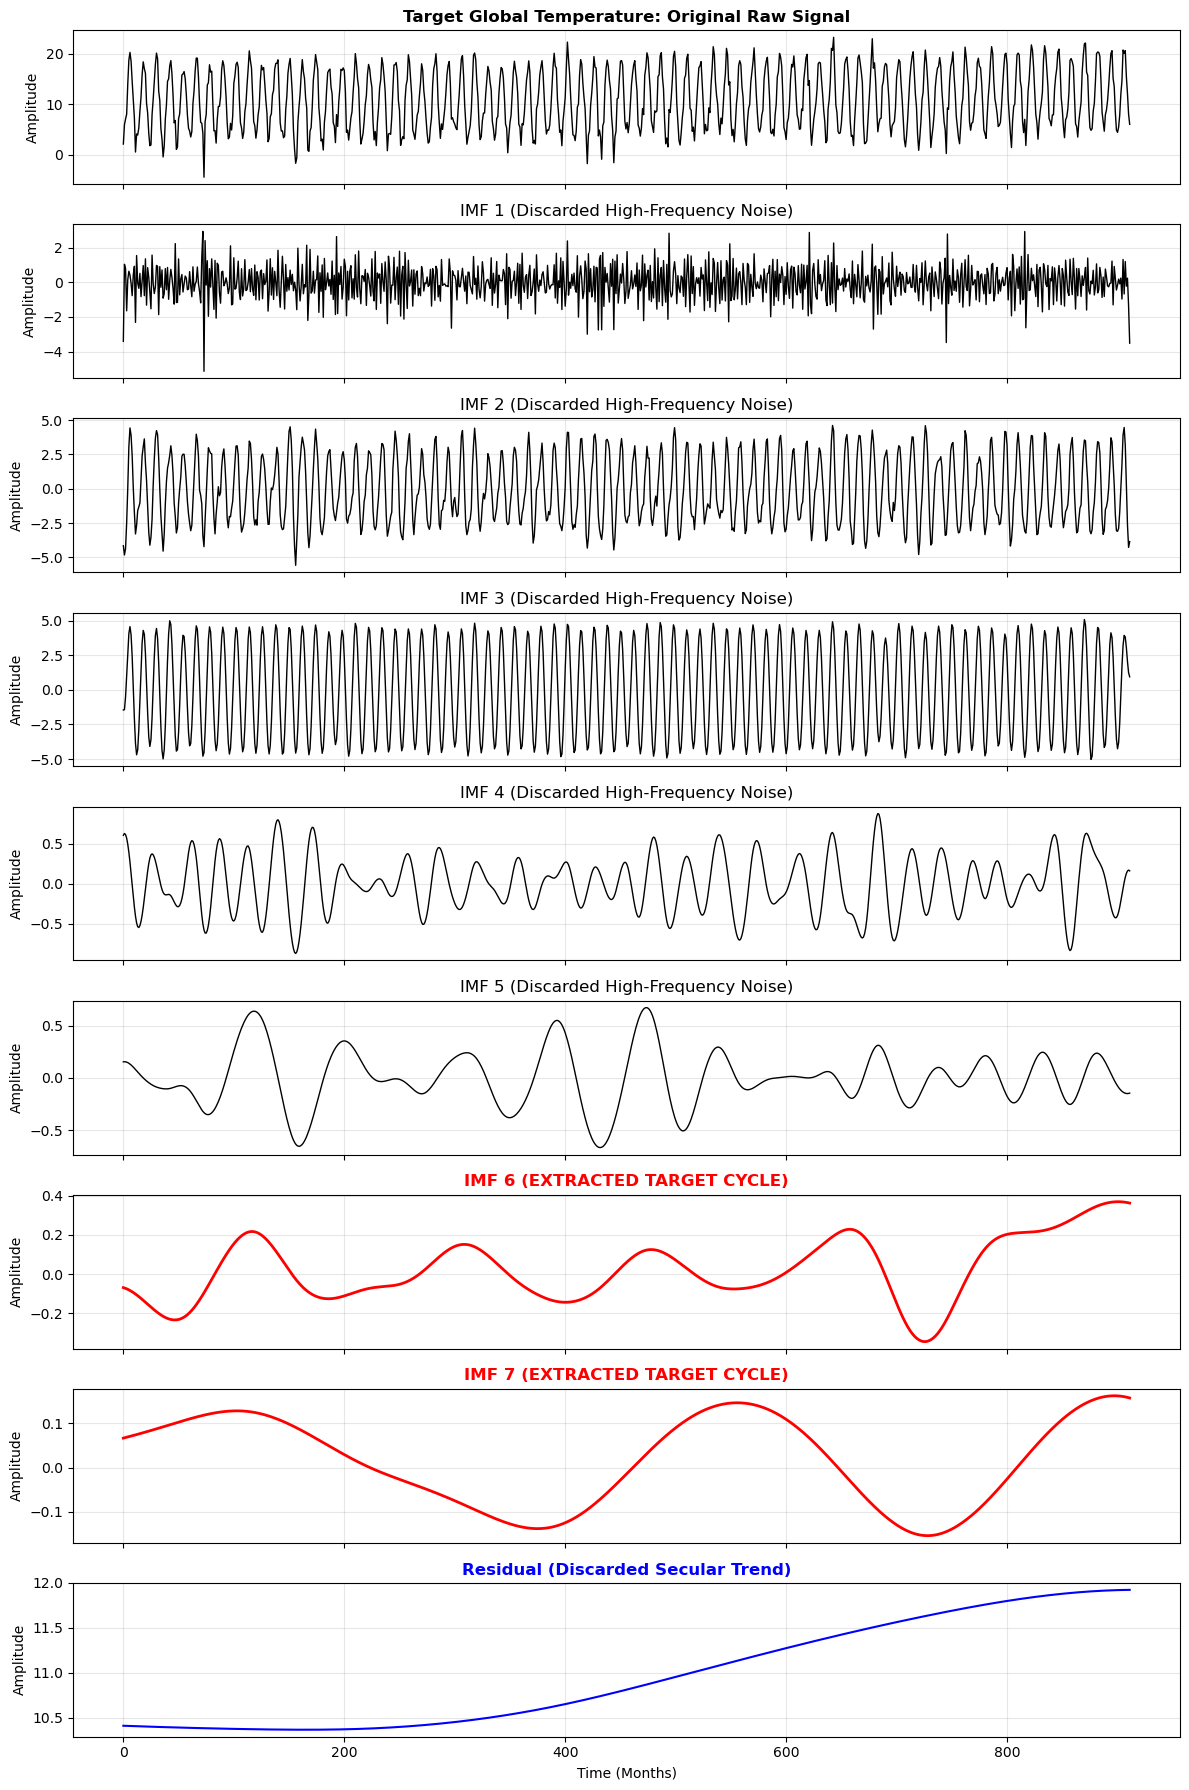

Rendering Spectral Matrix: North Atlantic Oscillation (NAO)
Mathematical Modes Extracted for Cyclic Tensor: [5, 6]


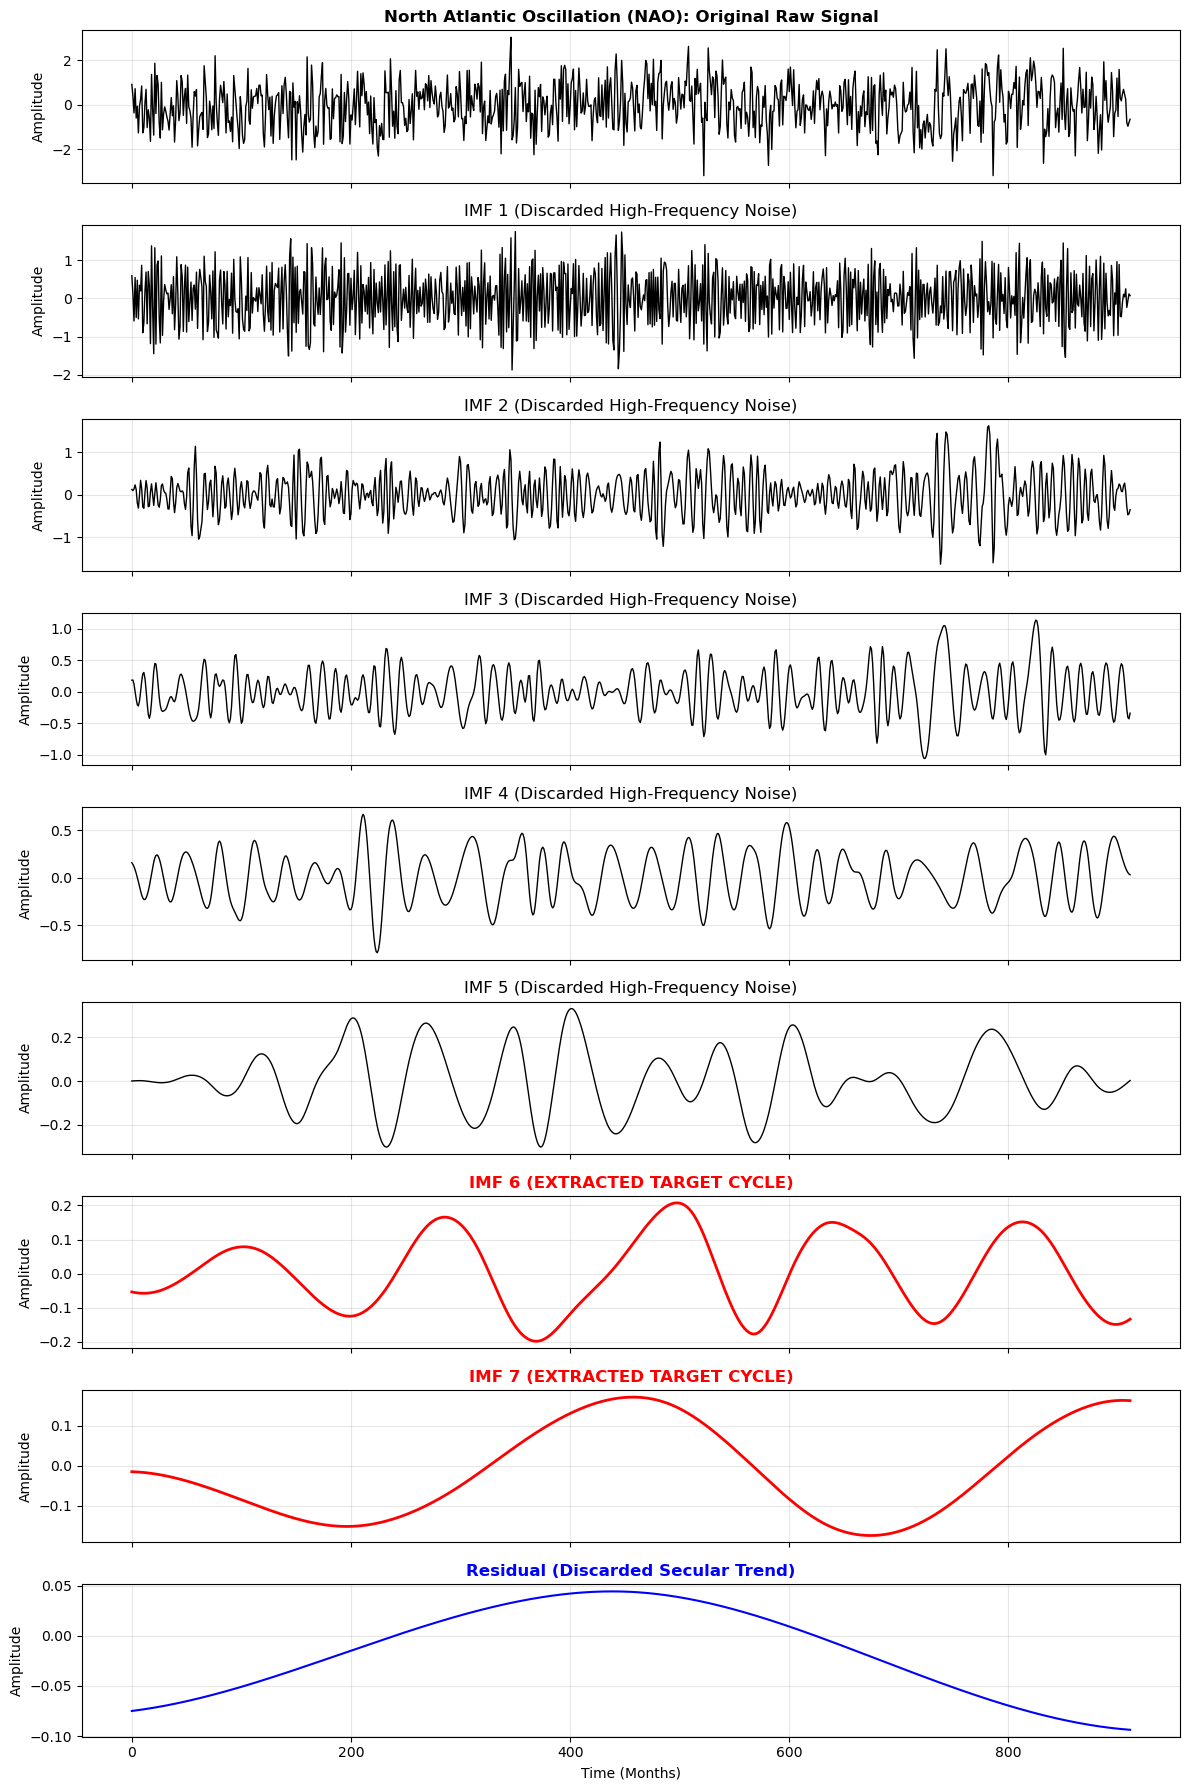

Rendering Spectral Matrix: East Atlantic Pattern (EA)
Mathematical Modes Extracted for Cyclic Tensor: [6]


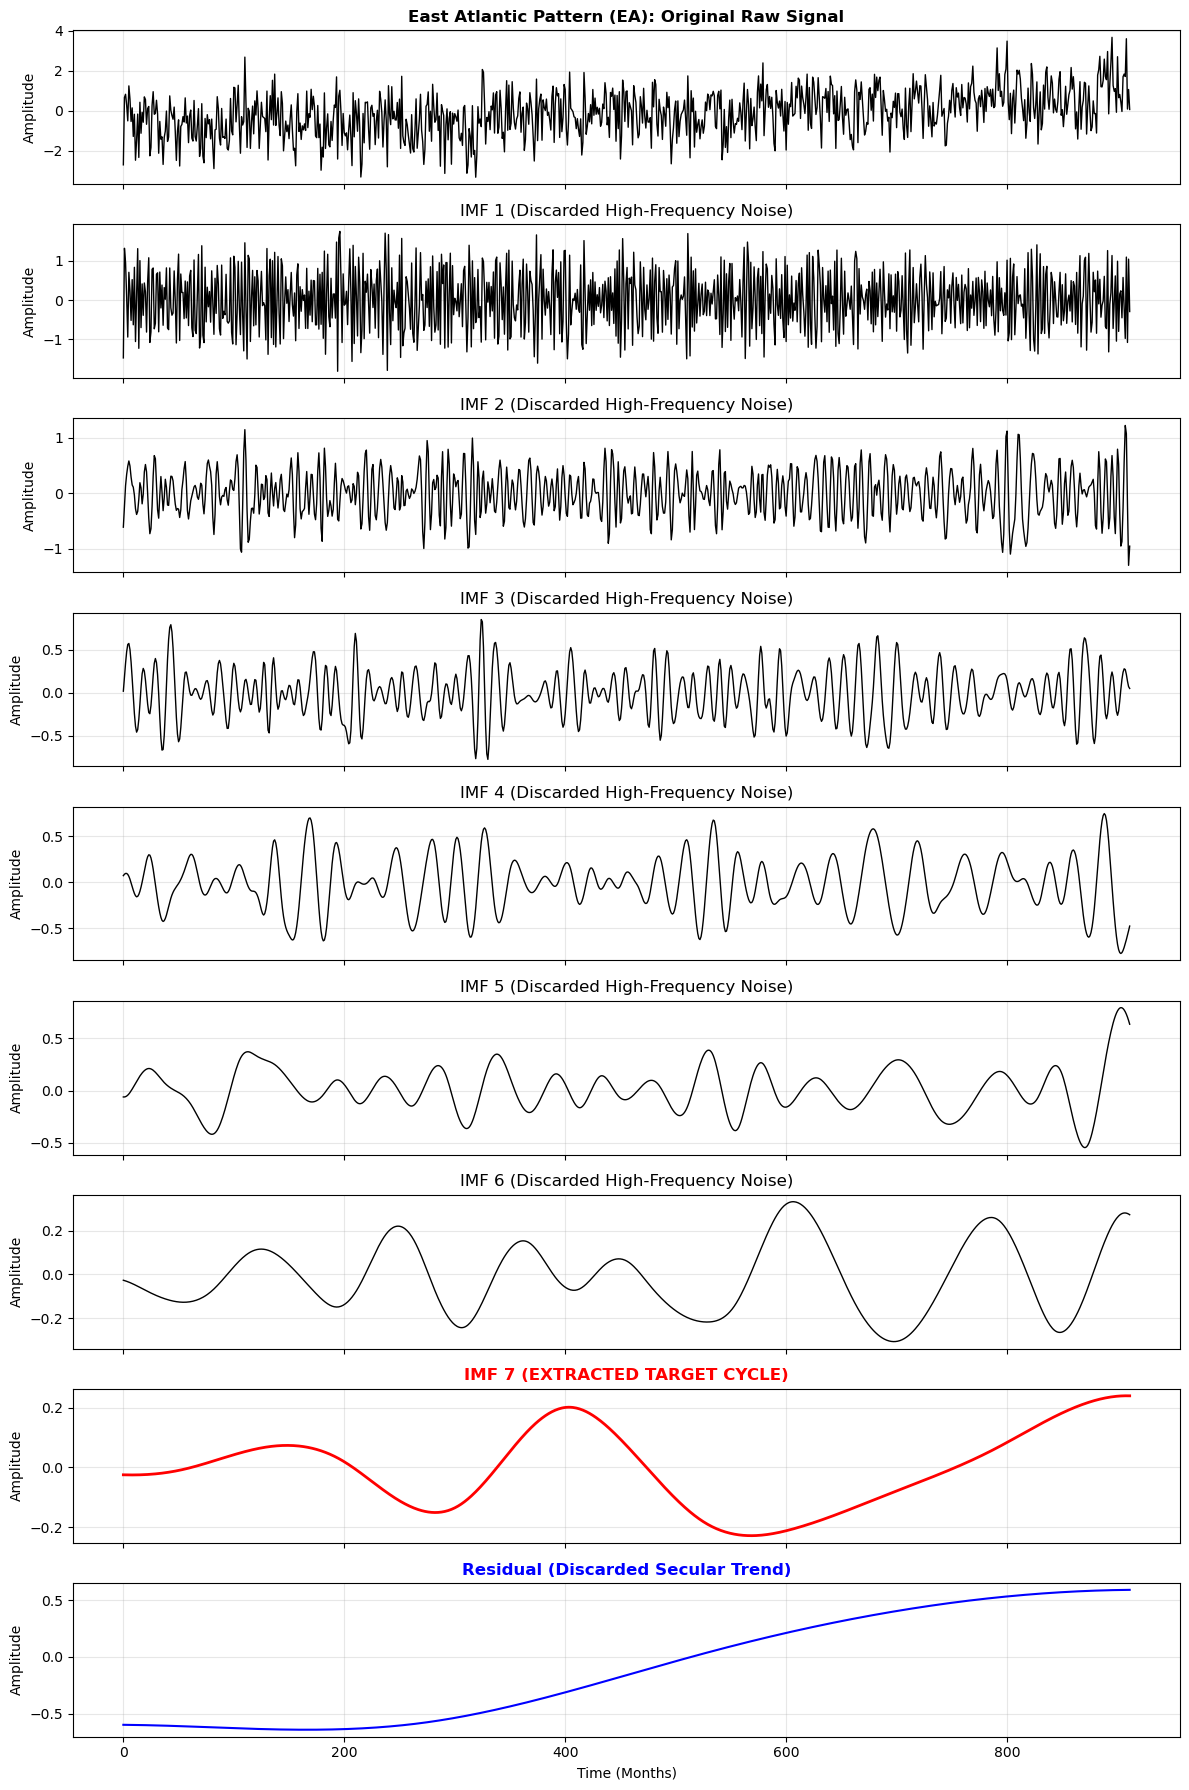

Rendering Spectral Matrix: Scandinavian Blocking (SCA)
Mathematical Modes Extracted for Cyclic Tensor: [5, 6]


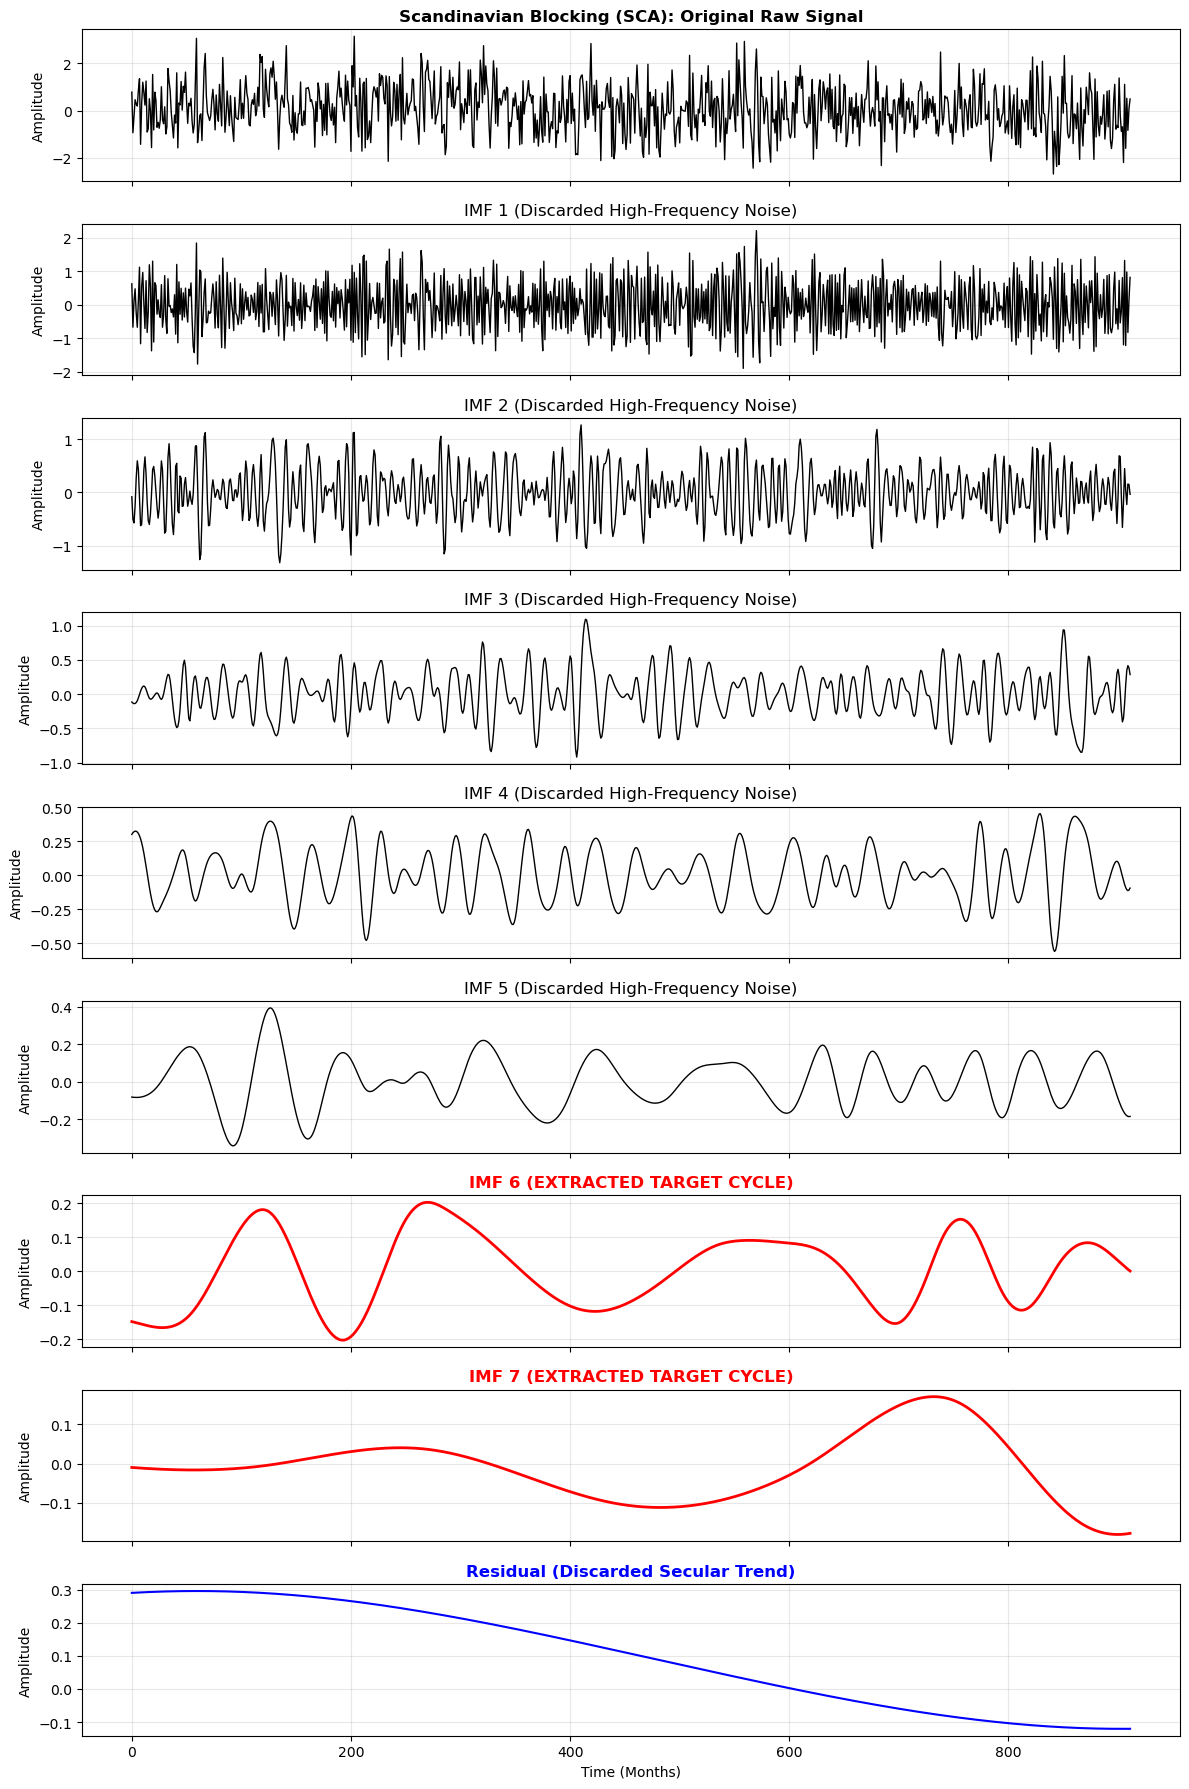

Rendering Spectral Matrix: Atlantic Multidecadal Oscillation (AMO)
Mathematical Modes Extracted for Cyclic Tensor: [5]


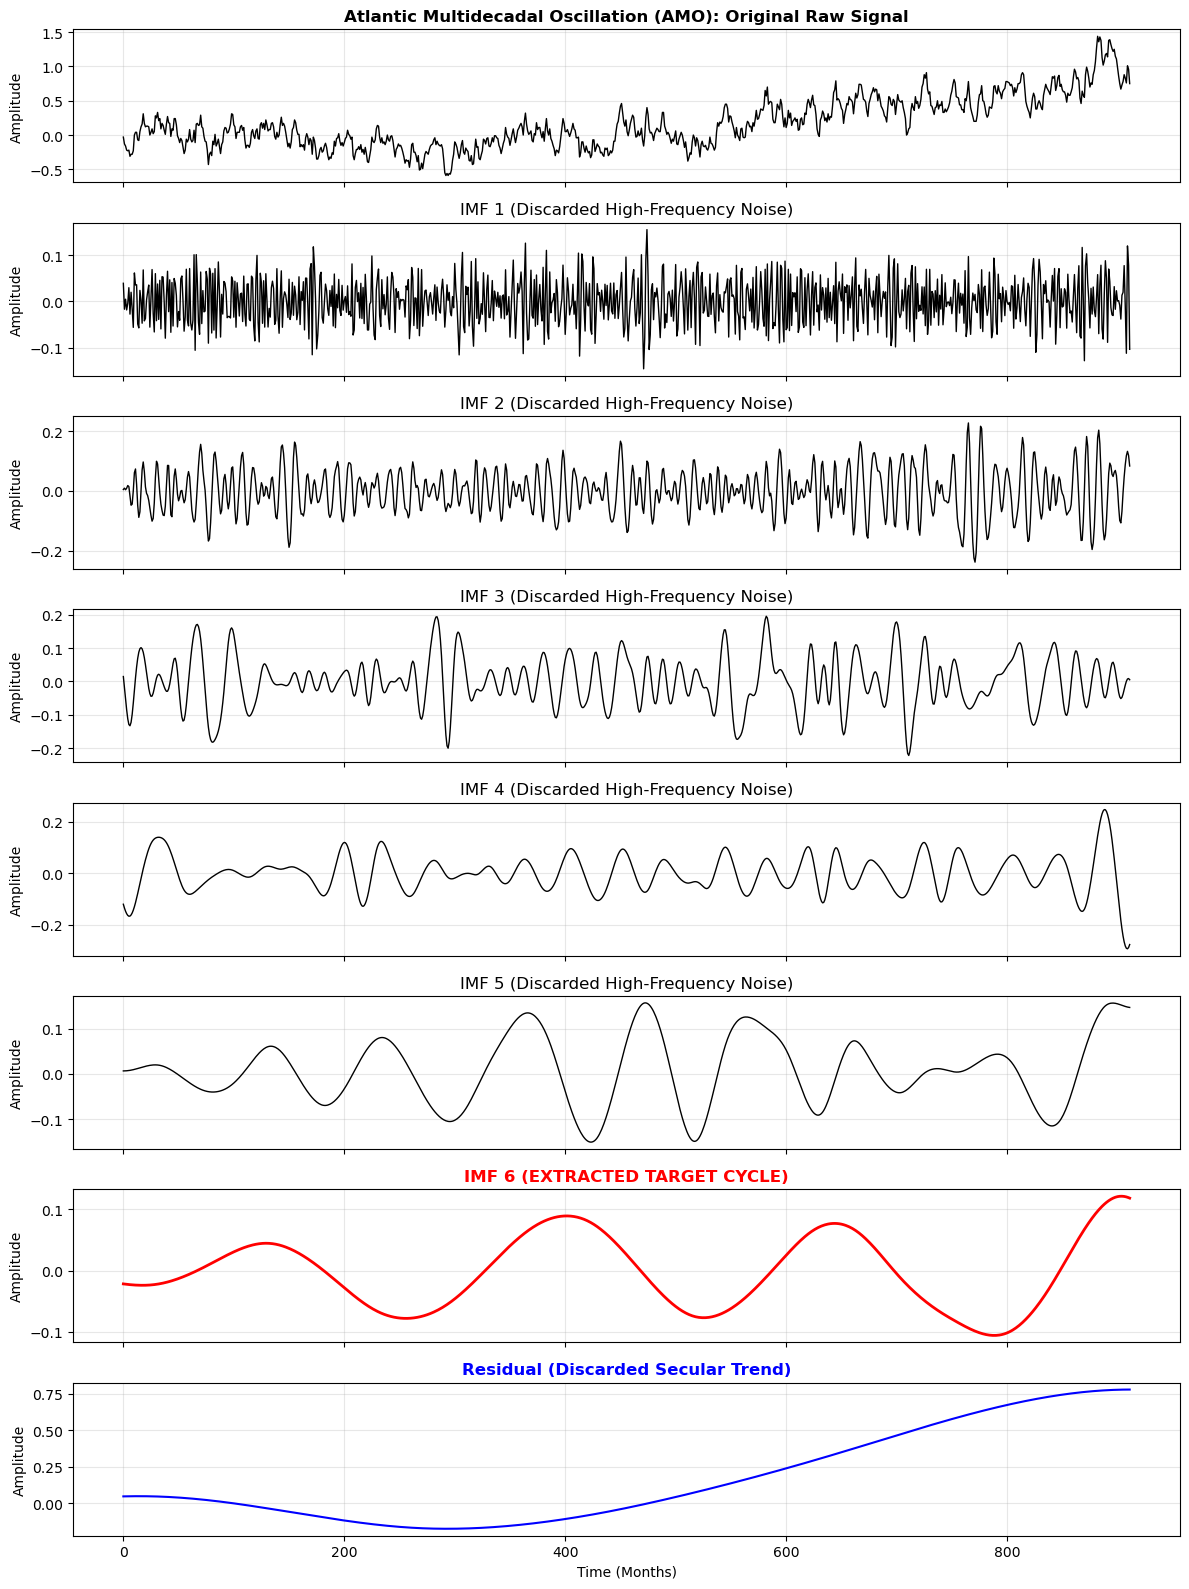

Rendering Spectral Matrix: Pacific Decadal Oscillation (PDO)
Mathematical Modes Extracted for Cyclic Tensor: [4, 5, 6]


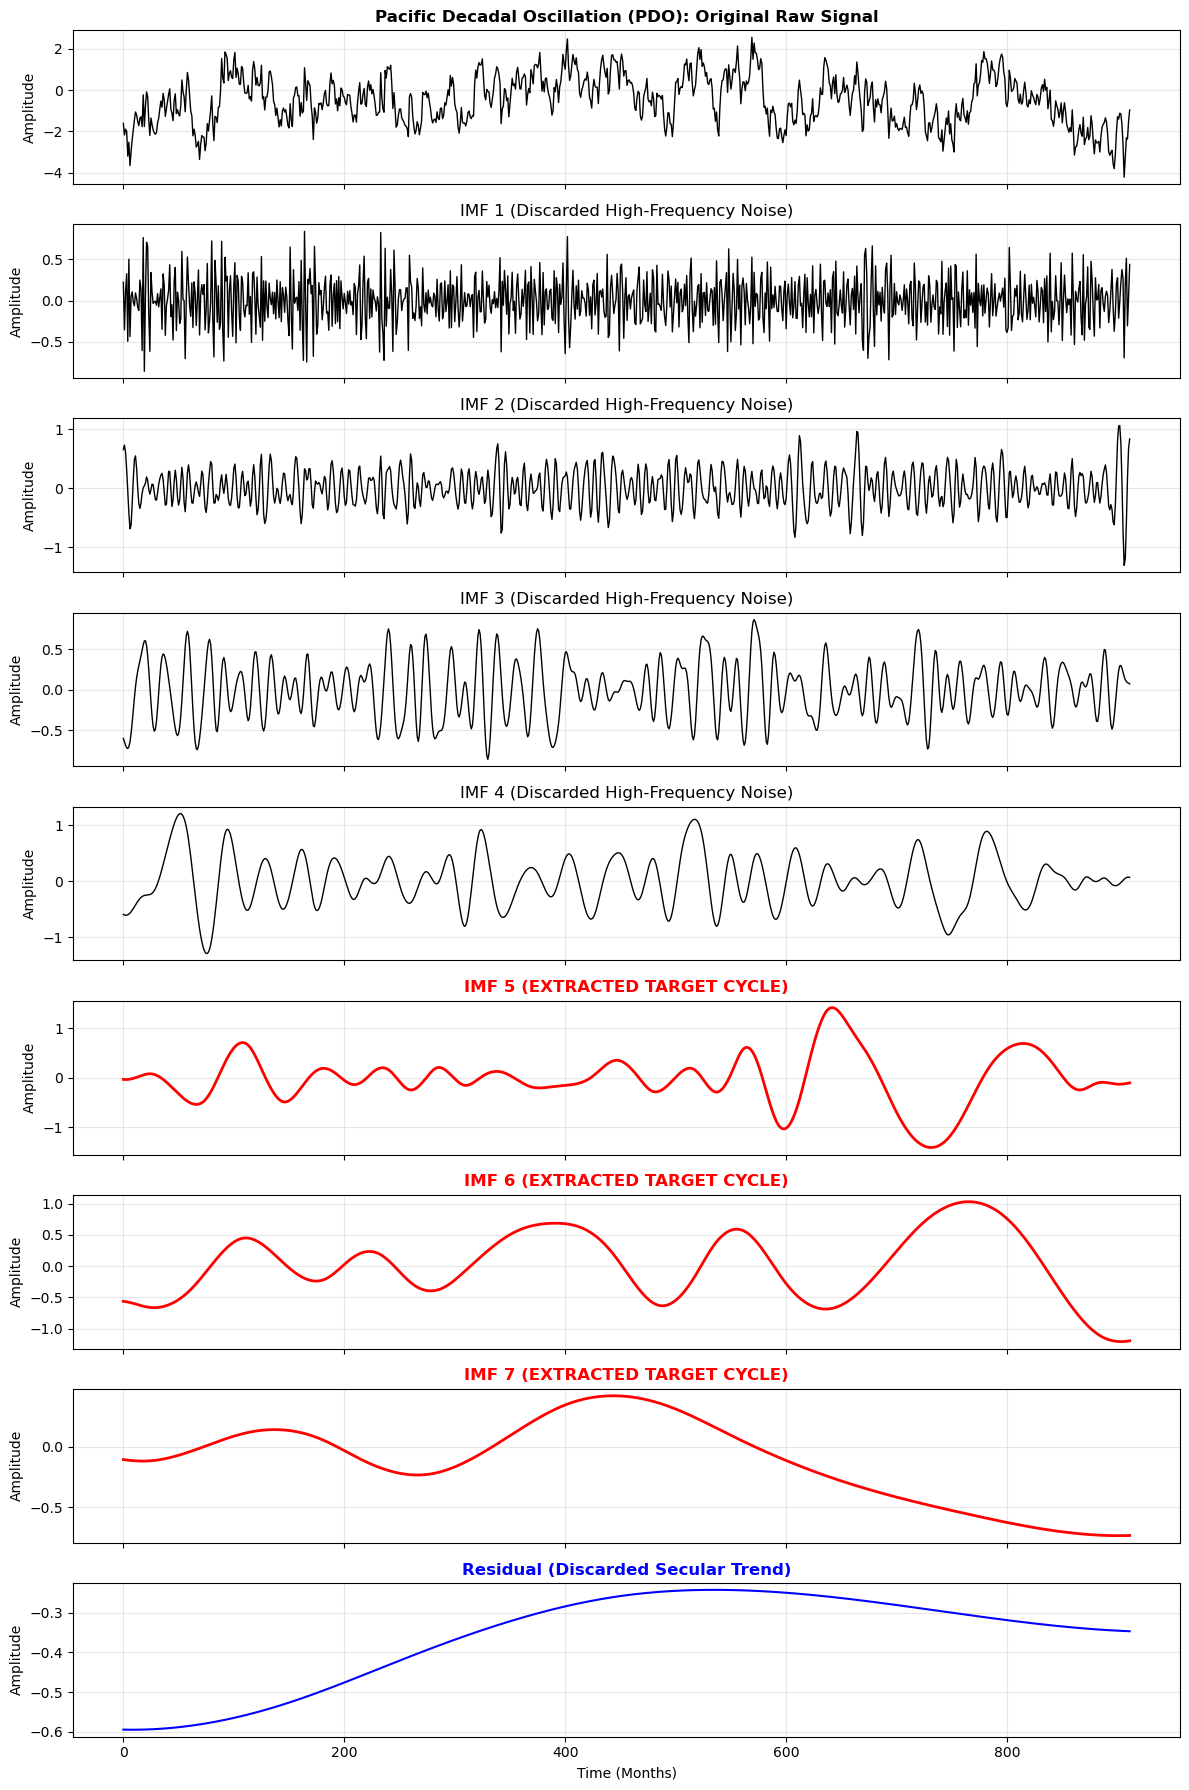

In [290]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ceemdan_decomposition(original_series, all_imfs, extracted_indices, title_prefix="Variable"):
    """
    Plots the full CEEMDAN decomposition matrix, highlighting the specific 
    low-frequency IMFs that were extracted to build the cyclic feature matrix.
    
    Parameters:
    original_series (ndarray): The raw 1D input data.
    all_imfs (ndarray): The 2D array output from PyEMD (IMFs + Residual).
    extracted_indices (list): The Python indices (0-based) of the targeted IMFs.
    title_prefix (str): Label for the specific variable being plotted.
    """
    # The last row of the matrix is strictly the residual, not an IMF
    num_imfs = all_imfs.shape[0] - 1 
    time_axis = np.arange(len(original_series))
    
    # Create a dynamic figure height based on the number of extracted modes
    fig, axes = plt.subplots(num_imfs + 2, 1, figsize=(12, 2 * (num_imfs + 2)), sharex=True)
    
    # ==============================================================================
    # 1. Plot the Original Raw Signal
    # ==============================================================================
    axes[0].plot(time_axis, original_series, color='black', linewidth=1)
    axes[0].set_title(f"{title_prefix}: Original Raw Signal", fontweight='bold')
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(True, alpha=0.3)
    
    # ==============================================================================
    # 2. Plot the Intrinsic Mode Functions (IMFs)
    # ==============================================================================
    for i in range(num_imfs):
        ax = axes[i + 1]
        
        # Check if this specific IMF is part of your target cyclic reconstruction
        if i in extracted_indices:
            color = 'red'
            linewidth = 2.0
            # Note: Adding 1 to 'i' maps 0-based Python indexing to standard 1-based IMF literature
            title = f"IMF {i + 1} (EXTRACTED TARGET CYCLE)" 
            ax.set_title(title, color=color, fontweight='bold')
        else:
            color = 'black'
            linewidth = 1.0
            title = f"IMF {i + 1} (Discarded High-Frequency Noise)"
            ax.set_title(title)
            
        ax.plot(time_axis, all_imfs[i], color=color, linewidth=linewidth)
        ax.set_ylabel("Amplitude")
        ax.grid(True, alpha=0.3)
    
    # ==============================================================================
    # 3. Plot the Non-Stationary Residual
    # ==============================================================================
    axes[-1].plot(time_axis, all_imfs[-1], color='blue', linewidth=1.5)
    axes[-1].set_title("Residual (Discarded Secular Trend)", color='blue', fontweight='bold')
    axes[-1].set_xlabel("Time (Months)")
    axes[-1].set_ylabel("Amplitude")
    axes[-1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# ==============================================================================
# EXECUTION
# ==============================================================================
# Execute this function for each of your preprocessed variables.
# For example, to plot the North Atlantic Oscillation decomposition:
execution_batch = [
    (df_climate['raw'].values, y_all_imfs, y_kept, "Target Global Temperature"),
    (df_climate['NAO'].values, nao_all_imfs, nao_kept, "North Atlantic Oscillation (NAO)"),
    (df_climate['EA'].values, ea_all_imfs, ea_kept, "East Atlantic Pattern (EA)"),
    (df_climate['SCA'].values, sca_all_imfs, sca_kept, "Scandinavian Blocking (SCA)"),
    (df_climate['AMO'].values, amo_all_imfs, amo_kept, "Atlantic Multidecadal Oscillation (AMO)"),
    (df_climate['PDO'].values, pdo_all_imfs, pdo_kept, "Pacific Decadal Oscillation (PDO)")
]

# Iterate and compute visual matrices
for raw_data, imf_matrix, target_indices, var_name in execution_batch:
    print(f"Rendering Spectral Matrix: {var_name}")
    print(f"Mathematical Modes Extracted for Cyclic Tensor: {target_indices}")
    
    plot_ceemdan_decomposition(
        original_series=raw_data, 
        all_imfs=imf_matrix, 
        extracted_indices=target_indices, 
        title_prefix=var_name
    )

In [670]:
# Apply the transformation
df_gam_filtered['NAO_Cycle'] = (df_gam_filtered['NAO_Cycle'] - np.mean(df_gam_filtered['NAO_Cycle'])) / np.std(df_gam_filtered['NAO_Cycle'])
df_gam_filtered['AMO_Cycle'] = (df_gam_filtered['AMO_Cycle'] - np.mean(df_gam_filtered['AMO_Cycle'])) / np.std(df_gam_filtered['AMO_Cycle'])
df_gam_filtered['SCA_Cycle'] = (df_gam_filtered['SCA_Cycle'] - np.mean(df_gam_filtered['SCA_Cycle'])) / np.std(df_gam_filtered['SCA_Cycle'])
df_gam_filtered['EA_Cycle'] = (df_gam_filtered['EA_Cycle'] - np.mean(df_gam_filtered['EA_Cycle'])) / np.std(df_gam_filtered['EA_Cycle'])
df_gam_filtered['Temp_Cycle'] = (df_gam_filtered['Temp_Cycle'] - np.mean(df_gam_filtered['Temp_Cycle'])) / np.std(df_gam_filtered['Temp_Cycle'])
df_gam_filtered['PDO_Cycle'] = (df_gam_filtered['PDO_Cycle'] - np.mean(df_gam_filtered['PDO_Cycle'])) / np.std(df_gam_filtered['PDO_Cycle'])

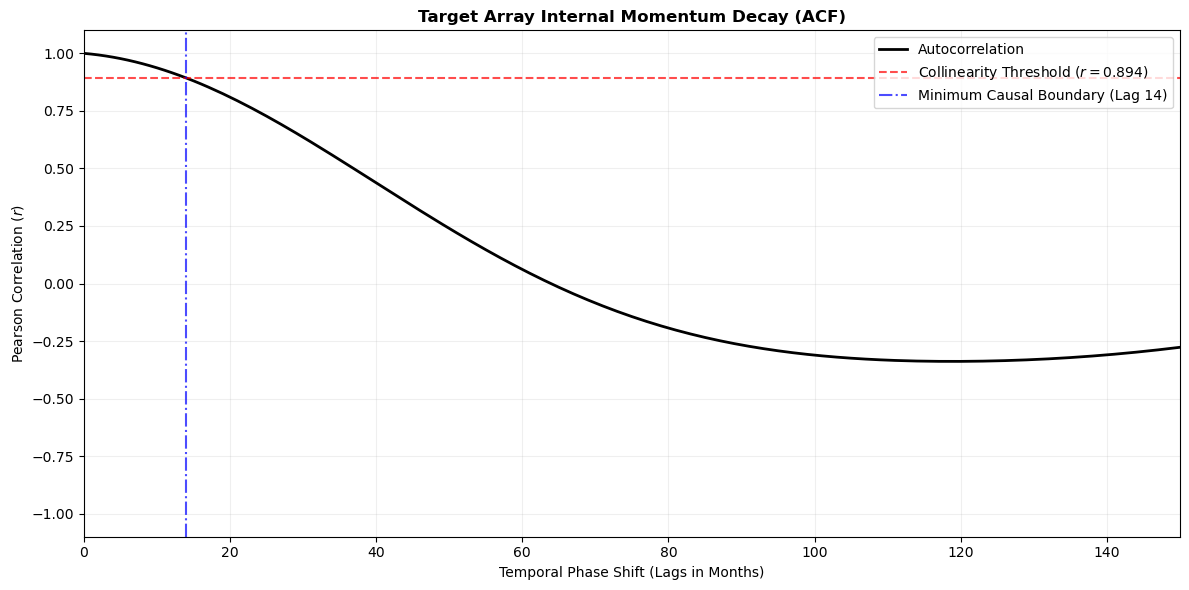

--- AUTOCORRELATION BOUNDARY DIAGNOSTIC ---
Target Threshold: r < 0.894
Absolute Minimum Valid Predictive Lag: 14 Months
14


In [632]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf

def extract_minimum_causal_lag(target_array, threshold=0.80, max_lags=120):
    """
    Computes the Autocorrelation Function (ACF) to determine the exact 
    mathematical boundary where collinear momentum decays.
    
    Parameters:
    - target_array: 1D array or pandas Series of the CEEMDAN target cycle.
    - threshold: The maximum allowable collinearity (default: 0.80).
    - max_lags: Chronological depth of the ACF computation.
    
    Returns:
    - int: The absolute minimum valid lag for predictive matrices.
    """
    # 1. Compute the exact Autocorrelation matrix
    acf_values = acf(target_array, nlags=max_lags, fft=True)
    
    # 2. Isolate the mathematical boundary
    # Find the first index where the autocorrelation drops strictly below the threshold
    decay_indices = np.where(acf_values < threshold)[0]
    
    if len(decay_indices) == 0:
        raise ValueError(f"Autocorrelation does not decay below {threshold} within {max_lags} lags. Increase max_lags.")
        
    minimum_valid_lag = decay_indices[0]
    
    # 3. Generate the diagnostic topological visualization
    plt.figure(figsize=(12, 6))
    lags = np.arange(len(acf_values))
    
    # Plot the continuous decay curve
    plt.plot(lags, acf_values, color='black', linewidth=2, label='Autocorrelation')
    
    # Map the threshold and boundary coordinates
    plt.axhline(threshold, color='red', linestyle='--', alpha=0.7, 
                label=f'Collinearity Threshold ($r = {threshold}$)')
    plt.axvline(minimum_valid_lag, color='blue', linestyle='-.', alpha=0.7,
                label=f'Minimum Causal Boundary (Lag {minimum_valid_lag})')
    
    # Plot formatting
    plt.title('Target Array Internal Momentum Decay (ACF)', fontweight='bold')
    plt.xlabel('Temporal Phase Shift (Lags in Months)')
    plt.ylabel('Pearson Correlation ($r$)')
    plt.xlim(0, max_lags)
    plt.ylim(-1.1, 1.1)
    plt.grid(True, alpha=0.2)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    print("--- AUTOCORRELATION BOUNDARY DIAGNOSTIC ---")
    print(f"Target Threshold: r < {threshold}")
    print(f"Absolute Minimum Valid Predictive Lag: {minimum_valid_lag} Months")
    
    return minimum_valid_lag

#min_lag = extract_minimum_causal_lag(df_gam_filtered['Temp_Cycle'].values, threshold=0, max_lags=150)
min_lag = extract_minimum_causal_lag(df_gam_filtered['Temp_Cycle'].values, threshold=0.894, max_lags=150)
print(min_lag)

In [623]:
np.sqrt(0.8)

np.float64(0.8944271909999159)

In [530]:
def compute_dynamic_boundaries(imf_metadata):
    """
    Dynamically computes the maximum thermodynamic lag bound for cross-correlation 
    to physically prevent mathematical wave aliasing and phase inversions.
    
    Parameters:
    imf_metadata (dict): A dictionary mapping the variable name to a list of 
                         dominant periods (in months) of its RETAINED IMFs.
                         
    Returns:
    dict: The exact integer bounds to feed into the target_lag_correlation function.
    """
    dynamic_bounds = {}
    
    print("--- COMPUTING DYNAMIC SPECTRAL BOUNDARIES ---")
    for predictor, periods in imf_metadata.items():
        # Ensure only strictly positive numerical periods are evaluated
        valid_periods = [p for p in periods if p > 0 and not np.isinf(p)]
        
        if not valid_periods:
            print(f"Warning: No valid periods for {predictor}. Defaulting to 120.")
            dynamic_bounds[predictor] = 120
            continue
            
        # Extract the fastest macroscopic wave in the retained composite
        p_crit = min(valid_periods)
        
        # Calculate strict cutoff just prior to the λ/2 phase inversion
        max_bound = int(np.floor(p_crit * 0.45))
        
        # Absolute safety overrides (Optional, based on oceanic physics)
        # Prevents micro-boundaries if a high-frequency IMF bypassed the bandpass
        if max_bound < 24: 
            max_bound = 24
            
        dynamic_bounds[predictor] = max_bound
        
        print(f"{predictor}:")
        print(f"  -> Retained Periods: {[round(p, 1) for p in valid_periods]} months")
        print(f"  -> Critical Wave (P_crit): {p_crit:.1f} months")
        print(f"  -> Inversion Threshold (λ/2): {p_crit / 2:.1f} months")
        print(f"  -> ASSIGNED LAG BOUNDARY: {max_bound} months\n")
        
    return dynamic_bounds

# ==============================================================================
# EXECUTION PIPELINE INTEGRATION
# ==============================================================================
# Input the exact dominant periods of the IMFs you retained for each variable.
# (These values are derived directly from the console output of your FFT function).

retained_imf_periods = {    
    'SCA_Cycle': [228.0, 456],
    'EA_Cycle': [456.0],
    'NAO_Cycle': [182.4, 452.5], 
    'AMO_Cycle': [228] ,
    'PDO_Cycle': [182.4, 304.0, 912.0]
}

# 1. Compute the strict mathematical limits
calculated_physical_bounds = compute_dynamic_boundaries(retained_imf_periods)


--- COMPUTING DYNAMIC SPECTRAL BOUNDARIES ---
SCA_Cycle:
  -> Retained Periods: [228.0, 456] months
  -> Critical Wave (P_crit): 228.0 months
  -> Inversion Threshold (λ/2): 114.0 months
  -> ASSIGNED LAG BOUNDARY: 102 months

EA_Cycle:
  -> Retained Periods: [456.0] months
  -> Critical Wave (P_crit): 456.0 months
  -> Inversion Threshold (λ/2): 228.0 months
  -> ASSIGNED LAG BOUNDARY: 205 months

NAO_Cycle:
  -> Retained Periods: [182.4, 452.5] months
  -> Critical Wave (P_crit): 182.4 months
  -> Inversion Threshold (λ/2): 91.2 months
  -> ASSIGNED LAG BOUNDARY: 82 months

AMO_Cycle:
  -> Retained Periods: [228] months
  -> Critical Wave (P_crit): 228.0 months
  -> Inversion Threshold (λ/2): 114.0 months
  -> ASSIGNED LAG BOUNDARY: 102 months

PDO_Cycle:
  -> Retained Periods: [182.4, 304.0, 912.0] months
  -> Critical Wave (P_crit): 182.4 months
  -> Inversion Threshold (λ/2): 91.2 months
  -> ASSIGNED LAG BOUNDARY: 82 months



Processing Atlantic Multidecadal Oscillation (AMO)...
Executing CEEMDAN... (Length: 912)
  -> Discarding IMF 0 (Dominant Period: 4.54 months)
  -> Discarding IMF 1 (Dominant Period: 12.16 months)
  -> Discarding IMF 2 (Dominant Period: 29.42 months)
  -> Discarding IMF 3 (Dominant Period: 43.43 months)
  -> Discarding IMF 4 (Dominant Period: 114.00 months)
  -> Retaining IMF 5 (Dominant Period: 228.00 months)

Processing Target Temperature (Y)...
Executing CEEMDAN... (Length: 912)
  -> Discarding IMF 0 (Dominant Period: 3.12 months)
  -> Discarding IMF 1 (Dominant Period: 12.00 months)
  -> Discarding IMF 2 (Dominant Period: 12.00 months)
  -> Discarding IMF 3 (Dominant Period: 28.50 months)
  -> Discarding IMF 4 (Dominant Period: 91.20 months)
  -> Retaining IMF 5 (Dominant Period: 182.40 months)
  -> Retaining IMF 6 (Dominant Period: 456.00 months)

Processing North Atlantic Oscillation (NAO)...
Executing CEEMDAN... (Length: 912)
  -> Discarding IMF 0 (Dominant Period: 3.37 months)
  -> Discarding IMF 1 (Dominant Period: 9.70 months)
  -> Discarding IMF 2 (Dominant Period: 11.84 months)
  -> Discarding IMF 3 (Dominant Period: 32.57 months)
  -> Discarding IMF 4 (Dominant Period: 70.15 months)
  -> Retaining IMF 5 (Dominant Period: 182.40 months)
  -> Retaining IMF 6 (Dominant Period: 456.00 months)

Processing East Atlantic Pattern (EA)...
Executing CEEMDAN... (Length: 912)
  -> Discarding IMF 0 (Dominant Period: 2.49 months)
  -> Discarding IMF 1 (Dominant Period: 8.29 months)
  -> Discarding IMF 2 (Dominant Period: 11.84 months)
  -> Discarding IMF 3 (Dominant Period: 26.82 months)
  -> Discarding IMF 4 (Dominant Period: 114.00 months)
  -> Discarding IMF 5 (Dominant Period: 130.29 months)
  -> Retaining IMF 6 (Dominant Period: 456.00 months)

Processing Scandinavian Blocking (SCA)...
Executing CEEMDAN... (Length: 912)
  -> Discarding IMF 0 (Dominant Period: 2.31 months)
  -> Discarding IMF 1 (Dominant Period: 8.44 months)
  -> Discarding IMF 2 (Dominant Period: 18.24 months)
  -> Discarding IMF 3 (Dominant Period: 31.45 months)
  -> Discarding IMF 4 (Dominant Period: 70.15 months)
  -> Retaining IMF 5 (Dominant Period: 228.00 months)
  -> Retaining IMF 6 (Dominant Period: 456.00 months)

Processing Pacific Decadal Oscillation (PDO)...
Executing CEEMDAN... (Length: 912)
  -> Discarding IMF 0 (Dominant Period: 4.09 months)
  -> Discarding IMF 1 (Dominant Period: 11.12 months)
  -> Discarding IMF 2 (Dominant Period: 16.58 months)
  -> Discarding IMF 3 (Dominant Period: 39.65 months)
  -> Retaining IMF 4 (Dominant Period: 182.40 months)
  -> Retaining IMF 5 (Dominant Period: 304.00 months)
  -> Retaining IMF 6 (Dominant Period: 912.00 months)

CEEMDAN Data Engineering Complete. Ready for GAM Tensor Integration.

Executing Forward Causality Correlation against Temp_Cycle...

--- TARGET MULTIDECADAL LAG SUMMARY ---
Predictor     Target Extraction Window  Peak Correlation (r)  Optimal Lag (Months)                Physical Dynamic
NAO_Cycle Temp_Cycle        1 to 82 mo                0.5451                    20 Macroscopic Thermodynamic Delay
AMO_Cycle Temp_Cycle       1 to 102 mo               -0.5125                    79 Macroscopic Thermodynamic Delay
 EA_Cycle Temp_Cycle       1 to 205 mo                0.3898                   114 Macroscopic Thermodynamic Delay
SCA_Cycle Temp_Cycle       1 to 102 mo               -0.2787                    84 Macroscopic Thermodynamic Delay
PDO_Cycle Temp_Cycle        1 to 82 mo               -0.0967                    15 Macroscopic Thermodynamic Delay


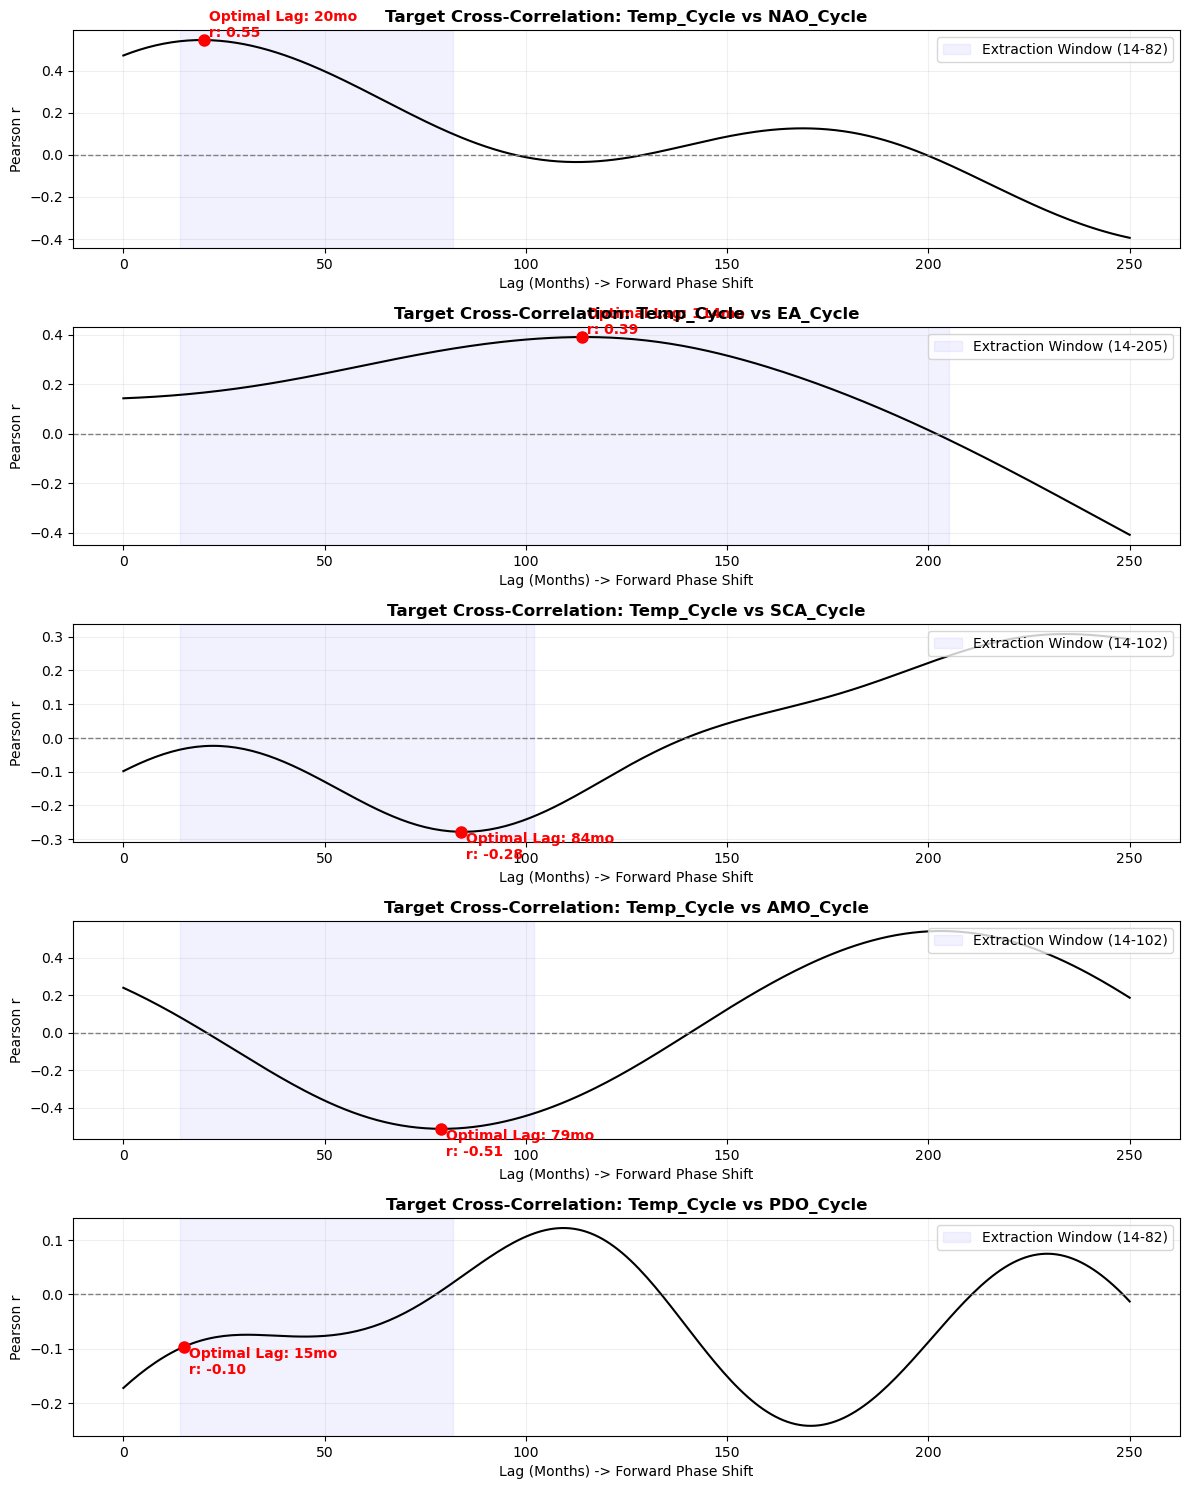

In [633]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def target_lag_correlation(df, target_var, predictors, max_lag_plot=240, search_bounds=None):
    if search_bounds is None:
        search_bounds = {p: 120 for p in predictors}

    cross_corr_data = {}
    summary_stats = []
    
    # Base array for all tested lags
    lags = np.arange(0, max_lag_plot + 1)
    
    print(f"Executing Forward Causality Correlation against {target_var}...")
    
    for predictor in predictors:
        correlations = []
        
        for lag in lags:
            shifted_predictor = df[predictor].shift(lag)
            corr = df[target_var].corr(shifted_predictor)
            correlations.append(corr)
            
        correlations = np.array(correlations)
        cross_corr_data[predictor] = correlations
        
        # ==============================================================================
        # MATHEMATICAL EXTRACTION BLOCK
        # ==============================================================================
        upper_bound = search_bounds.get(predictor, 120)
        
        # STRICT BOUNDING: Lag must be > 0 AND <= upper_bound
        valid_indices = np.where((lags <= upper_bound) & (lags > 14))[0]
        valid_lags = lags[valid_indices]
        valid_correlations = correlations[valid_indices]
        
        max_abs_idx = np.argmax(np.abs(valid_correlations))
        peak_corr = valid_correlations[max_abs_idx]
        optimal_lag = valid_lags[max_abs_idx]
            
        summary_stats.append({
            "Predictor": predictor,
            "Target": target_var,
            "Extraction Window": f"1 to {upper_bound} mo",
            "Peak Correlation (r)": round(peak_corr, 4),
            "Optimal Lag (Months)": optimal_lag,
            "Physical Dynamic": "Macroscopic Thermodynamic Delay"
        })
        
    df_summary = pd.DataFrame(summary_stats).sort_values(by="Peak Correlation (r)", key=abs, ascending=False)
    
    return df_summary, cross_corr_data, lags, search_bounds

# ==============================================================================
# EXECUTION
# ==============================================================================
target = 'Temp_Cycle'
# Excluded EA based on previous structural analysis
predictors_to_test = ['NAO_Cycle', 'EA_Cycle', 'SCA_Cycle', 'AMO_Cycle', 'PDO_Cycle'] 

physical_bounds = calculated_physical_bounds


df_target_summary, target_corr_data, lag_axis, applied_bounds = target_lag_correlation(
    df=df_gam_filtered, 
    target_var=target, 
    predictors=predictors_to_test, 
    max_lag_plot=250, 
    search_bounds=physical_bounds
)

print("\n--- TARGET MULTIDECADAL LAG SUMMARY ---")
print(df_target_summary.to_string(index=False))

# ==============================================================================
# VISUALIZATION BLOCK
# ==============================================================================
num_plots = len(predictors_to_test)
fig, axes = plt.subplots(num_plots, 1, figsize=(12, 3 * num_plots))
if num_plots == 1:
    axes = [axes]

for i, (predictor, corr_array) in enumerate(target_corr_data.items()):
    ax = axes[i]
    ax.plot(lag_axis, corr_array, color='black', linewidth=1.5)
    
    bound_limit = applied_bounds.get(predictor, 120)
    
    # STRICT BOUNDING IN THE PLOT: Synchronized with the math block
    valid_indices = np.where((lag_axis <= bound_limit) & (lag_axis > 14))[0]
    valid_corrs = corr_array[valid_indices]
    
    max_idx = np.argmax(np.abs(valid_corrs))
    peak_lag = lag_axis[valid_indices][max_idx]
    peak_r = valid_corrs[max_idx]
    
    # Baselines and Bounding Area Highlight
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    # Start the blue shading strictly at 1, not 0
    ax.axvspan(14, bound_limit, color='blue', alpha=0.05, label=f'Extraction Window (14-{bound_limit})')
    
    # Highlight Valid Peak
    ax.plot(peak_lag, peak_r, 'ro', markersize=8)
    ax.text(peak_lag, peak_r, f' Optimal Lag: {peak_lag}mo\n r: {peak_r:.2f}', 
             color='red', fontweight='bold', 
             va='bottom' if peak_r > 0 else 'top')
    
    ax.set_title(f"Target Cross-Correlation: {target} vs {predictor}", fontweight='bold')
    ax.set_xlabel("Lag (Months) -> Forward Phase Shift")
    ax.set_ylabel("Pearson r")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()
plt.close(fig)

In [328]:
df_gam_filtered

,Temp_Cycle,NAO_Cycle,EA_Cycle,SCA_Cycle,AMO_Cycle,PDO_Cycle
0,-0.002871,-0.068578,-0.024832,-0.157613,-0.021582,-0.698792
1,-0.003995,-0.069357,-0.024928,-0.158668,-0.021813,-0.704517
2,-0.005381,-0.070092,-0.025012,-0.159718,-0.022034,-0.709419
3,-0.007028,-0.070782,-0.025084,-0.160765,-0.022245,-0.713466
4,-0.008929,-0.071425,-0.025143,-0.161809,-0.022446,-0.716648
...,...,...,...,...,...,...
896,0.530132,0.013727,0.236827,-0.137530,0.118540,-2.048465
897,0.530686,0.013667,0.237289,-0.140537,0.119325,-2.055109
898,0.531061,0.013776,0.237715,-0.143521,0.119999,-2.060674
899,0.531258,0.014049,0.238103,-0.146474,0.120560,-2.065057


In [672]:
df_gam_filtered['Trend'] = ((y_all_imfs[-1] - np.min(y_all_imfs[-1]))/np.std(y_all_imfs[-1]))+1
df_gam_filtered['Inv_Trend'] = 1/(((y_all_imfs[-1] - np.min(y_all_imfs[-1]))/np.std(y_all_imfs[-1]))+1)

In [ ]:
np.mean(df)

In [411]:
df_gam_filtered['AMO2'] = df_gam_filtered["AMO_Cycle"]

In [720]:
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet, 
                                  HuberRegressor, BayesianRidge, OrthogonalMatchingPursuit, Lars)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from pygam import LinearGAM, s, l, te



pure_oceanic_architectures = {

    # =========================================================================
    # CLASS 1: SKLEARN LINEAR & PENALIZED OPTIMIZATION (Models 01 - 10)
    # Computes global additive scalars without spline geometry.
    # =========================================================================
    "01_OLS_Bivariate": lambda: make_pipeline(StandardScaler(), LinearRegression()),
    "02_Ridge_Standard_L2": lambda: make_pipeline(StandardScaler(), Ridge(alpha=10.0)),
    "03_Ridge_Heavy_L2": lambda: make_pipeline(StandardScaler(), Ridge(alpha=100.0)),
    "04_Lasso_Feature_Selection": lambda: make_pipeline(StandardScaler(), Lasso(alpha=0.01, max_iter=10000)),
    "05_Lasso_Strict_Selection": lambda: make_pipeline(StandardScaler(), Lasso(alpha=0.1, max_iter=10000)),
    "06_ElasticNet_Balanced": lambda: make_pipeline(StandardScaler(), ElasticNet(alpha=0.05, l1_ratio=0.5)),
    "07_Huber_Robust_Phase": lambda: make_pipeline(StandardScaler(), HuberRegressor(epsilon=1.35, alpha=0.01, max_iter=2000)),
    "08_Bayesian_Ridge_Prob": lambda: make_pipeline(StandardScaler(), BayesianRidge(max_iter=1000)),
    "09_OMP_Strict_Sparsity": lambda: make_pipeline(StandardScaler(), OrthogonalMatchingPursuit(n_nonzero_coefs=2)),
    "10_Lars_Algorithm": lambda: make_pipeline(StandardScaler(), Lars(n_nonzero_coefs=2)),

    # =========================================================================
    # CLASS 2: ADDITIVE GENERALIZED GEOMETRY (Models 11 - 20)
    # Isolates the independent, uncoupled topological forcing of the arrays.
    # =========================================================================
    "11_GAM_Add_Strict_Linear": lambda: LinearGAM(l(0) + l(1)),
    "12_GAM_Add_NAO_Only_Linear": lambda: LinearGAM(l(0)),
    "13_GAM_Add_AMO_Only_Linear": lambda: LinearGAM(l(1)),
    "14_GAM_Add_Linear_Spline_Proxy": lambda: LinearGAM(s(0, spline_order=1, n_splines=2) + s(1, spline_order=1, n_splines=2)),
    "15_GAM_Add_AMOQuad_NAOLin": lambda: LinearGAM(l(0) + s(1, spline_order=2, n_splines=3)),
    "16_GAM_Add_NAOQuad_AMOLin": lambda: LinearGAM(s(0, spline_order=2, n_splines=3) + l(1)),
    "16bis_GAM_Add_NAOQuad_AMOLin": lambda: LinearGAM(s(0, spline_order=1, n_splines=2) + l(1)),
    "17_GAM_Add_Dual_Quadratic": lambda: LinearGAM(s(0, spline_order=2, n_splines=3) + s(1, spline_order=2, n_splines=3)),
    "18_GAM_Add_Cubic_Heavily_Penalized": lambda: LinearGAM(s(0, n_splines=4, lam=1000) + s(1, n_splines=4, lam=1000)),
    "19_GAM_Add_NAOLin_AMOCubic_Penalized": lambda: LinearGAM(l(0) + s(1, n_splines=4, lam=500)),
    "20_GAM_Add_Dual_Extreme_Smoothing": lambda: LinearGAM(s(0, n_splines=4, lam=5000) + s(1, n_splines=4, lam=5000)),

    # =========================================================================
    # CLASS 3: VARYING COEFFICIENTS (VC) MODULATION (Models 21 - 30)
    # Computes algebraic scaling without mapping continuous tensor surfaces.
    # =========================================================================
    "21_GAM_VC_NAO_Mods_AMO_Lin": lambda: LinearGAM(s(1, by=0, spline_order=1, n_splines=2)),
    "22_GAM_VC_AMO_Mods_NAO_Lin": lambda: LinearGAM(s(0, by=1, spline_order=1, n_splines=2)),
    "23_GAM_VC_NAO_Mods_AMO_Plus_Base": lambda: LinearGAM(l(0) + s(1, by=0, spline_order=1, n_splines=2)),
    "24_GAM_VC_AMO_Mods_NAO_Plus_Base": lambda: LinearGAM(l(1) + s(0, by=1, spline_order=1, n_splines=2)),
    "25_GAM_VC_Cross_Linear_Modulation": lambda: LinearGAM(s(0, by=1, spline_order=1, n_splines=2) + s(1, by=0, spline_order=1, n_splines=2)),
    "26_GAM_VC_NAO_Mods_AMOQuad": lambda: LinearGAM(s(1, by=0, spline_order=2, n_splines=3)),
    "27_GAM_VC_AMOQuad_Mods_NAO": lambda: LinearGAM(s(0, by=1, spline_order=2, n_splines=3)),
    "28_GAM_VC_NAO_Mods_AMOQuad_Plus_Base": lambda: LinearGAM(l(0) + s(1, by=0, spline_order=2, n_splines=3)),
    "29_GAM_VC_Cross_Modulation_Plus_Main": lambda: LinearGAM(l(0) + l(1) + s(0, by=1, spline_order=1, n_splines=2)),
    "30_GAM_VC_Dual_Quad_Modulation": lambda: LinearGAM(s(0, by=1, spline_order=2, n_splines=3, lam=500) + s(1, by=0, spline_order=2, n_splines=3, lam=500)),

    # =========================================================================
    # CLASS 4: CONTINUOUS TENSOR PLANES (Models 31 - 40)
    # Maps phase interference across full 3D coordinate intersections.
    # =========================================================================
    "31_GAM_TE_Bilinear_Plane": lambda: LinearGAM(te(0, 1, spline_order=1, n_splines=[2, 2])),
    "32_GAM_TE_Asym_NAOLin_AMOQuad": lambda: LinearGAM(te(0, 1, spline_order=[1, 2], n_splines=[2, 3])),
    "33_GAM_TE_Asym_NAOQuad_AMOLin": lambda: LinearGAM(te(0, 1, spline_order=[2, 1], n_splines=[3, 2])),
    "34_GAM_TE_Symmetric_Quadratic": lambda: LinearGAM(te(0, 1, spline_order=2, n_splines=[3, 3])),
    "35_GAM_TE_Symmetric_Quadratic_Dense": lambda: LinearGAM(te(0, 1, spline_order=2, n_splines=[4, 4], lam=100)),
    "36_GAM_TE_Asym_NAOLin_AMOCubic": lambda: LinearGAM(te(0, 1, spline_order=[1, 3], n_splines=[2, 4], lam=500)),
    "37_GAM_TE_Asym_NAOCubic_AMOLin": lambda: LinearGAM(te(0, 1, spline_order=[3, 1], n_splines=[4, 2], lam=500)),
    "38_GAM_TE_Symmetric_Cubic_Penalized": lambda: LinearGAM(te(0, 1, spline_order=3, n_splines=[4, 4], lam=1000)),
    "39_GAM_TE_Bilinear_Plus_Main_Effects": lambda: LinearGAM(te(0, 1, spline_order=1, n_splines=[2, 2]) + l(0) + l(1)),
    "40_GAM_TE_Asym_Plane_Plus_NAOBase": lambda: LinearGAM(te(0, 1, spline_order=[1, 2], n_splines=[2, 3]) + l(0)),

    # =========================================================================
    # CLASS 5: THERMODYNAMIC MONOTONIC CONSTRAINTS (Models 41 - 50)
    # Forces splines to align with strict unidirectional physical laws 
    # to prevent outlier-driven phase inversions at the vector tails.
    # =========================================================================
    "41_GAM_Mono_Inc_AMO_Plus_NAOLin": lambda: LinearGAM(l(0) + s(1, constraints='monotonic_inc', n_splines=4)),
    "42_GAM_Mono_Inc_NAO_Plus_AMOLin": lambda: LinearGAM(s(0, constraints='monotonic_inc', n_splines=4) + l(1)),
    "43_GAM_Mono_Inc_Dual": lambda: LinearGAM(s(0, constraints='monotonic_inc', n_splines=4) + s(1, constraints='monotonic_inc', n_splines=4)),
    "44_GAM_Mono_Dec_NAO_Inc_AMO": lambda: LinearGAM(s(0, constraints='monotonic_dec', n_splines=4) + s(1, constraints='monotonic_inc', n_splines=4)),
    "45_GAM_Mono_Quad_AMO_Plus_NAOLin": lambda: LinearGAM(l(0) + s(1, spline_order=2, n_splines=3, constraints='monotonic_inc')),
    "46_GAM_Mono_Quad_Dual": lambda: LinearGAM(s(0, spline_order=2, n_splines=3, constraints='monotonic_inc') + s(1, spline_order=2, n_splines=3, constraints='monotonic_inc')),
    "47_GAM_TE_Bilinear_Plus_Mono_AMO": lambda: LinearGAM(te(0, 1, spline_order=1, n_splines=[2, 2]) + s(1, constraints='monotonic_inc', n_splines=4)),
    "48_GAM_TE_Asym_Plus_Mono_AMO": lambda: LinearGAM(te(0, 1, spline_order=[1, 2], n_splines=[2, 3], lam=100) + s(1, constraints='monotonic_inc', n_splines=4)),
    "49_GAM_VC_AMOModsNAO_Plus_MonoAMO": lambda: LinearGAM(s(0, by=1, spline_order=1, n_splines=2) + s(1, constraints='monotonic_inc', n_splines=4)),
    "50_GAM_VC_Dual_Mono_Constraint": lambda: LinearGAM(s(1, by=0, spline_order=1, n_splines=2) + s(0, constraints='monotonic_inc', n_splines=4) + s(1, constraints='monotonic_inc', n_splines=4)),


    # =========================================================================
    # 1. PURE LINEAR BASELINE
    # Zero localized phase deformation.
    # =========================================================================

    # =========================================================================
    # 2. SYMMETRIC ADDITIVE SPLINES 
    # Both vectors map to the exact same polynomial degree and knot count.
    # =========================================================================
    "GAM_Sym_Ord1_Knot2": lambda: LinearGAM(s(0, spline_order=1, n_splines=2) + s(1, spline_order=1, n_splines=2)),
    "GAM_Sym_Ord1_Knot3": lambda: LinearGAM(s(0, spline_order=1, n_splines=3) + s(1, spline_order=1, n_splines=3)),
    "GAM_Sym_Ord2_Knot3": lambda: LinearGAM(s(0, spline_order=2, n_splines=3) + s(1, spline_order=2, n_splines=3)),

    # =========================================================================
    # 3. ASYMMETRIC ADDITIVE (Linear vs. Spline)
    # One vector operates linearly; the other expands into a low-dim spline.
    # =========================================================================
    "GAM_Asym_V0_Ord1Knot2_V1_Lin": lambda: LinearGAM(s(0, spline_order=1, n_splines=2) + l(1)),
    "GAM_Asym_V0_Lin_V1_Ord1Knot2": lambda: LinearGAM(l(0) + s(1, spline_order=1, n_splines=2)),
    "GAM_Asym_V0_Ord1Knot3_V1_Lin": lambda: LinearGAM(s(0, spline_order=1, n_splines=3) + l(1) + l(0)),

    "TREND_GAM_Asym_V0_Ord1Knot3_V1_Lin": lambda: LinearGAM(s(0, by=2, spline_order=1, n_splines=3) + l(1)),
    "TREND2_GAM_Asym_V0_Ord1Knot3_V1_Lin": lambda: LinearGAM(s(0, by=2, spline_order=2, n_splines=3) + l(1)),

    
    "GAM_Asym_V0_Lin_V1_Ord1Knot3": lambda: LinearGAM(l(0) + s(1, spline_order=1, n_splines=3)),
    "GAM_Asym_V0_Ord2Knot3_V1_Lin": lambda: LinearGAM(s(0, spline_order=2, n_splines=3) + l(1)),
    "GAM_Asym_V0_Lin_V1_Ord2Knot3": lambda: LinearGAM(l(0) + s(1, spline_order=2, n_splines=3)),

    # =========================================================================
    # 4. ASYMMETRIC ADDITIVE (Spline vs. Spline)
    # Both vectors are splines, but operate at disparate geometric scales.
    # =========================================================================
    "GAM_Cross_V0_O1K2_V1_O1K3": lambda: LinearGAM(s(0, spline_order=1, n_splines=2) + s(1, spline_order=1, n_splines=3)),
    "GAM_Cross_V0_O1K3_V1_O1K2": lambda: LinearGAM(s(0, spline_order=1, n_splines=3) + s(1, spline_order=1, n_splines=2)),
    "aaaa": lambda: LinearGAM(s(0, spline_order=1, n_splines=4) + s(1, spline_order=1, n_splines=2)),
    "GAM_Cross_V0_O1K2_V1_O2K3": lambda: LinearGAM(s(0, spline_order=1, n_splines=2) + s(1, spline_order=2, n_splines=3)),
    "GAM_Cross_V0_O2K3_V1_O1K2": lambda: LinearGAM(s(0, spline_order=2, n_splines=3) + s(1, spline_order=1, n_splines=2)),
    "GAM_Cross_V0_O1K3_V1_O2K3": lambda: LinearGAM(s(0, spline_order=1, n_splines=3) + s(1, spline_order=2, n_splines=3)),
    "GAM_Cross_V0_O2K3_V1_O1K3": lambda: LinearGAM(s(0, spline_order=2, n_splines=3) + s(1, spline_order=1, n_splines=3)),

    # =========================================================================
    # 5. SYMMETRIC TENSOR PRODUCTS
    # Computes the coupled 3D interference matrix at equal resolutions.
    # =========================================================================
    "GAM_Tensor_Sym_O1K2": lambda: LinearGAM(te(0, 1, spline_order=1, n_splines=[2, 2])),
    "GAM_Tensor_Sym_O1K3": lambda: LinearGAM(te(0, 1, spline_order=1, n_splines=[3, 3])),
    "GAM_Tensor_Sym_O2K3": lambda: LinearGAM(te(0, 1, spline_order=2, n_splines=[3, 3])),

    # =========================================================================
    # 6. ASYMMETRIC TENSOR PRODUCTS
    # Computes 3D interference matching disparate basis functions.
    # =========================================================================
    "GAM_Tensor_Asym_O1_K2_K3": lambda: LinearGAM(te(0, 1, spline_order=1, n_splines=[2, 3])),
    "GAM_Tensor_Asym_O1_K3_K2": lambda: LinearGAM(te(0, 1, spline_order=1, n_splines=[3, 2])),
    "GAM_Tensor_Asym_V0_O1K2_V1_O2K3": lambda: LinearGAM(te(0, 1, spline_order=[1, 2], n_splines=[2, 3])),
    "GAM_Tensor_Asym_V0_O2K3_V1_O1K2": lambda: LinearGAM(te(0, 1, spline_order=[2, 1], n_splines=[3, 2])),
    "GAM_Tensor_Asym_V0_O1K3_V1_O2K3": lambda: LinearGAM(te(0, 1, spline_order=[1, 2], n_splines=[3, 3])),
    "GAM_Tensor_Asym_V0_O2K3_V1_O1K3": lambda: LinearGAM(te(0, 1, spline_order=[2, 1], n_splines=[3, 3]))}

    # =========================================================================
    # 7. VARYING COEFFICIENT MODELS
    # Spline geometry strictly multiplied by the algebraic scalar of the other.
    # =========================================================================
a=  {"GAM_VC_V0_O1K2_Mods_V1": lambda: LinearGAM(s(0, by=1, spline_order=1, n_splines=2)),
    "GAM_VC_V1_O1K2_Mods_V0": lambda: LinearGAM(s(1, by=0, spline_order=1, n_splines=2)),
    "GAM_VC_V0_O1K3_Mods_V1": lambda: LinearGAM(s(0, by=1, spline_order=1, n_splines=3)),
    "GAM_VC_V1_O1K3_Mods_V0": lambda: LinearGAM(s(1, by=0, spline_order=1, n_splines=3)),
    "GAM_VC_V0_O2K3_Mods_V1": lambda: LinearGAM(s(0, by=1, spline_order=2, n_splines=3)),
    "GAM_VC_V1_O2K3_Mods_V0": lambda: LinearGAM(s(1, by=0, spline_order=2, n_splines=3)),
    "GAM_TrendMods_V0_O1K2_Plus_V1_Lin": lambda: LinearGAM(s(0, by=2, spline_order=1, n_splines=2) + l(1)),
    "GAM_TrendMods_V0_O1K3_Plus_V1_Lin": lambda: LinearGAM(s(0, by=2, spline_order=1, n_splines=3) + l(1)),
    "GAM_TrendMods_V0_O2K3_Plus_V1_Lin": lambda: LinearGAM(s(0, by=2, spline_order=2, n_splines=3) + l(1)),
    "GAM_TrendMods_V0_O1K2_Plus_V1_Lin": lambda: LinearGAM(s(0, by=2, spline_order=1, n_splines=2) + l(1)),
    # =========================================================================
    # CLASS 9: PURE OCEANIC MODULATION
    # The Trend (V2) strictly scales the AMO (V1). NAO (V0) remains static.
    # Includes permutations mapping against your previously optimal V0_O2K3 baseline.
    # =========================================================================
    "GAM_TrendMods_V1_O1K2_Plus_V0_Lin": lambda: LinearGAM(l(0) + s(1, by=2, spline_order=1, n_splines=2)),
    "GAM_TrendMods_V1_O1K3_Plus_V0_Lin": lambda: LinearGAM(l(0) + s(1, by=2, spline_order=1, n_splines=3)),
    "GAM_TrendMods_V1_O2K3_Plus_V0_Lin": lambda: LinearGAM(l(0) + s(1, by=2, spline_order=2, n_splines=3)),
    "GAM_TrendMods_V1_O1K2_Plus_V0_O2K3": lambda: LinearGAM(s(0, spline_order=2, n_splines=3) + s(1, by=2, spline_order=1, n_splines=2)),
    "GAM_TrendMods_V1_O2K3_Plus_V0_O2K3": lambda: LinearGAM(s(0, spline_order=2, n_splines=3) + s(1, by=2, spline_order=2, n_splines=3)),

    # =========================================================================
    # CLASS 10: DUAL MODULATION (Strict Multiplicative Scaling)
    # The Trend dynamically scales BOTH the ocean baseline and atmospheric extremes.
    # =========================================================================
    "GAM_TrendMods_Dual_Sym_O1K2": lambda: LinearGAM(s(0, by=2, spline_order=1, n_splines=2) + s(1, by=2, spline_order=1, n_splines=2)),
    "GAM_TrendMods_Dual_Sym_O1K3": lambda: LinearGAM(s(0, by=2, spline_order=1, n_splines=3) + s(1, by=2, spline_order=1, n_splines=3)),
    "GAM_TrendMods_Dual_Sym_O2K3": lambda: LinearGAM(s(0, by=2, spline_order=2, n_splines=3) + s(1, by=2, spline_order=2, n_splines=3)),
    "GAM_TrendMods_Dual_Asym_V0_O2K3_V1_O1K2": lambda: LinearGAM(s(0, by=2, spline_order=2, n_splines=3) + s(1, by=2, spline_order=1, n_splines=2)),

    # =========================================================================
    # CLASS 11: FULL INTERACTION (Modulation + Additive Trend Baseline)
    # Tests if the trend possesses independent additive variance + multiplicative scaling.
    # =========================================================================
    "GAM_FullInteract_V0_O2K3_V1_Lin": lambda: LinearGAM(s(0, by=2, spline_order=2, n_splines=3) + l(1) + l(2)),
    "GAM_FullInteract_V1_O1K2_V0_O2K3": lambda: LinearGAM(s(0, spline_order=2, n_splines=3) + s(1, by=2, spline_order=1, n_splines=2) + l(2)),
    "GAM_FullInteract_Dual_Asym_Base": lambda: LinearGAM(s(0, by=2, spline_order=2, n_splines=3) + s(1, by=2, spline_order=1, n_splines=2) + l(2))}



test_architecture = {

    "test1": lambda: LinearGAM(s(0, constraints='monotonic_inc',spline_order=1, n_splines=3) + l(1)),

    "test1_reworked": lambda: LinearGAM(s(0, by=3,spline_order=1, n_splines=3) + l(1)),

    "test1_reworked2": lambda: LinearGAM(s(0, by=3,spline_order=1, constraints='monotonic_inc', n_splines=3) + l(1)),

    "test2": lambda: LinearGAM(s(0, constraints='monotonic_inc',spline_order=2, n_splines=3) + l(1)),

    "test3": lambda: LinearGAM(s(0, constraints='monotonic_inc',spline_order=1, n_splines=3) + s(1, by=2, spline_order=1, n_splines=2)),

    "test4": lambda: LinearGAM(s(0, constraints='monotonic_inc',spline_order=2, n_splines=3) + s(1, spline_order=1, n_splines=2)),

    "last": lambda: LinearGAM(te(0,1, by=2, spline_order=[1, 1], n_splines=[2, 2])),
    

    "Simple Modelisation": lambda: LinearGAM(l(0)+l(1)),

    "Simple Modelisation + Trend": lambda: LinearGAM(l(0)+l(1)+l(2)),

    "SplineLinearLinear" : lambda: LinearGAM(s(0, spline_order=2, n_splines=3) + l(1) + l(2)),

    "Triple_spline" : lambda: LinearGAM(s(0, spline_order=2, n_splines=3) + s(1, spline_order=1, n_splines=2) + s(2, spline_order=2, n_splines=3)),

    "Basic": lambda: LinearGAM(s(0, spline_order=2, n_splines=3) + s(1, spline_order=1, n_splines=2)),

    "NAO AMO": lambda: LinearGAM(s(0, by=2, spline_order=2, n_splines=3) + s(1, by=2, spline_order=1, n_splines=2)),

    "NAO 1/AMO": lambda: LinearGAM(s(0, by=2, spline_order=2, n_splines=3) + s(1, by=3, spline_order=1, n_splines=2)),

    "1/NAO AMO": lambda: LinearGAM(s(0, by=3, spline_order=2, n_splines=3) + s(1, by=2, spline_order=1, n_splines=2)),

    "1/NAO 1/AMO": lambda: LinearGAM(s(0, by=3, spline_order=2, n_splines=3) + s(1, by=3, spline_order=1, n_splines=2)),

    "RNAO AMO": lambda: LinearGAM(s(0, by=2, spline_order=1, n_splines=2) + s(1, by=2, spline_order=1, n_splines=2)),

    "RNAO 1/AMO": lambda: LinearGAM(s(0, by=2, spline_order=1, n_splines=2) + s(1, by=3, spline_order=1, n_splines=2)),

    "R1/NAO AMO": lambda: LinearGAM(s(0, by=3, spline_order=1, n_splines=2) + s(1, by=2, spline_order=1, n_splines=2)),

    "R1/NAO 1/AMO": lambda: LinearGAM(s(0, by=3, spline_order=1, n_splines=2) + s(1, by=3, spline_order=1, n_splines=2)),

    "QNAO AMO": lambda: LinearGAM(s(0, by=2, spline_order=2, n_splines=3) + s(1, by=2, spline_order=2, n_splines=3)),

    "QNAO 1/AMO": lambda: LinearGAM(s(0, by=2, spline_order=2, n_splines=3) + s(1, by=3, spline_order=2, n_splines=3)),

    "Q1/NAO AMO": lambda: LinearGAM(s(0, by=3, spline_order=2, n_splines=3) + s(1, by=2, spline_order=2, n_splines=3)),

    "Q1/NAO 1/AMO": lambda: LinearGAM(s(0, by=3, spline_order=2, n_splines=3) + s(1, by=3, spline_order=2, n_splines=3)),

    "QRNAO AMO": lambda: LinearGAM(s(0, by=2, spline_order=1, n_splines=2) + s(1, by=2, spline_order=2, n_splines=3)),

    "QRNAO 1/AMO": lambda: LinearGAM(s(0, by=2, spline_order=1, n_splines=2) + s(1, by=3, spline_order=2, n_splines=3)),

    "QR1/NAO AMO": lambda: LinearGAM(s(0, by=3, spline_order=1, n_splines=2) + s(1, by=2, spline_order=2, n_splines=3)),

    "QR1/NAO 1/AMO": lambda: LinearGAM(s(0, by=3, spline_order=1, n_splines=2) + s(1, by=3, spline_order=2, n_splines=3))
}

final_testing = { 
    "LinAMO": lambda: LinearGAM(l(1)),
    "linNAO": lambda: LinearGAM(l(0)),
    "linNAOAMO": lambda: LinearGAM(l(0)+l(1)),
    "linNAOSplinAMO": lambda: LinearGAM(l(0)+s(1, spline_order=1, n_splines=2)),
    "linAMOSplinNAO": lambda: LinearGAM(l(1)+s(0, spline_order=1, n_splines=2)),
    "linAMOSplin2NAO": lambda: LinearGAM(l(1)+s(1, spline_order=2, n_splines=3)),
    "linNAOSplin2AMO": lambda: LinearGAM(l(0)+s(1, spline_order=2, n_splines=3)),
    "linNAOSplin3AMO": lambda: LinearGAM(l(0)+s(1, spline_order=1, n_splines=3)),
    "linAMOSplin3NAO": lambda: LinearGAM(l(1)+s(0, spline_order=1, n_splines=3)),
    "SplinNAOSplinAMO": lambda: LinearGAM(s(0, spline_order=1, n_splines=2)+s(1, spline_order=1, n_splines=2)),
    "SplinAMOSplinNAO": lambda: LinearGAM(s(1, spline_order=1, n_splines=2)+s(0, spline_order=1, n_splines=2)),
    "SplinAMOSplin2NAO": lambda: LinearGAM(s(1, spline_order=1, n_splines=2)+s(1, spline_order=2, n_splines=3)),
    "SplinNAOSplin2AMO": lambda: LinearGAM(s(0, spline_order=1, n_splines=2)+s(1, spline_order=2, n_splines=3)),
    "SplinNAOSplin3AMO": lambda: LinearGAM(s(0, spline_order=1, n_splines=2)+s(1, spline_order=1, n_splines=3)),
    "SplinAMOSplin3NAO": lambda: LinearGAM(s(1, spline_order=1, n_splines=2)+s(0, spline_order=1, n_splines=3)),
    "linNAOSplinAMO": lambda: LinearGAM(l(0)+s(1, by=0,spline_order=1, n_splines=2)),
    "linAMOSplinNAO": lambda: LinearGAM(l(1)+s(0, by=1,spline_order=1, n_splines=2)),
    "linAMOSplin2NAO": lambda: LinearGAM(l(1)+s(1, by=0,spline_order=2, n_splines=3)),
    "linNAOSplin2AMO": lambda: LinearGAM(l(0)+s(1, by=0,spline_order=2, n_splines=3)),
    "linNAOSplin3AMO": lambda: LinearGAM(l(0)+s(1, by=0,spline_order=1, n_splines=3)),
    "linAMOSplin3NAO": lambda: LinearGAM(l(1)+s(0, by=1,spline_order=1, n_splines=3)),
    "SplinNAOSplinAMO": lambda: LinearGAM(s(0, by=1,spline_order=1, n_splines=2)+s(1, spline_order=1, n_splines=2)),
    "SplinAMOSplinNAO": lambda: LinearGAM(s(1, by=0,spline_order=1, n_splines=2)+s(0, spline_order=1, n_splines=2)),
    "SplinAMOSplin2NAO": lambda: LinearGAM(s(1, by=0,spline_order=1, n_splines=2)+s(1, spline_order=2, n_splines=3)),
    "SplinNAOSplin2AMO": lambda: LinearGAM(s(0, by=1,spline_order=1, n_splines=2)+s(1, spline_order=2, n_splines=3)),
    "SplinNAOSplin3AMO": lambda: LinearGAM(s(0, by=1,spline_order=1, n_splines=2)+s(1, spline_order=1, n_splines=3)),
    "SplinAMOSplin3NAO": lambda: LinearGAM(s(1, by=0,spline_order=1, n_splines=2)+s(0, spline_order=1, n_splines=3)),
    "tensor": lambda: LinearGAM(te(0,1, spline_order=[1,1], n_splines=[2,2])),
    #"hybrid": lambda: LinearGAM(s(0, 1, spline_order=1, n_splines=3)),
    "test": lambda: LinearGAM(s(0, by=1, spline_order=1, n_splines=2) + s(1, by=2, spline_order=1, n_splines=2) + s(0, by=2, spline_order=1, n_splines=2)),
    "test3": lambda: LinearGAM(l(0) + s(1, by=0, spline_order=1, n_splines=2)),
    "test2": lambda: LinearGAM(te(0, 1,2, spline_order=[1, 1,1], n_splines=[2, 2,2])),
    "test4": lambda: LinearGAM(l(1) + s(0, by=2, spline_order=1, n_splines=2)),
    "lin+": lambda: LinearGAM(s(0, spline_order=0, n_splines=1))
}

gam_architectures_dict = {
    "aaaa": lambda: LinearGAM(s(0, spline_order=1, n_splines=4) + s(1, spline_order=1, n_splines=2)),

    # CATEGORY 1: ATMOSPHERIC KNOT DENSITY SCANS
    "Cat1_NAO_o1_k3__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=3) + s(1, spline_order=1, n_splines=2)),
    "Cat1_NAO_o1_k5__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=5) + s(1, spline_order=1, n_splines=2)),
    "Cat1_NAO_o1_k6__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=6) + s(1, spline_order=1, n_splines=2)),
    "Cat1_NAO_o1_k8__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=8) + s(1, spline_order=1, n_splines=2)),
    "Cat1_NAO_o1_k10__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=10) + s(1, spline_order=1, n_splines=2)),

    # CATEGORY 2: OCEANIC KNOT DENSITY SCANS
    "Cat2_NAO_o1_k4__AMO_o1_k3": lambda: LinearGAM(s(0, spline_order=1, n_splines=4) + s(1, spline_order=1, n_splines=3)),
    "Cat2_NAO_o1_k4__AMO_o1_k4": lambda: LinearGAM(s(0, spline_order=1, n_splines=4) + s(1, spline_order=1, n_splines=4)),
    "Cat2_NAO_o1_k4__AMO_o1_k5": lambda: LinearGAM(s(0, spline_order=1, n_splines=4) + s(1, spline_order=1, n_splines=5)),
    "Cat2_NAO_o1_k4__AMO_o1_k6": lambda: LinearGAM(s(0, spline_order=1, n_splines=4) + s(1, spline_order=1, n_splines=6)),
    "Cat2_NAO_o1_k4__AMO_o1_k8": lambda: LinearGAM(s(0, spline_order=1, n_splines=4) + s(1, spline_order=1, n_splines=8)),

    # CATEGORY 3: ASYMMETRIC QUADRATIC CURVATURE (NAO)
    "Cat3_NAO_o2_k3__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=2, n_splines=3) + s(1, spline_order=1, n_splines=2)),
    "Cat3_NAO_o2_k4__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=2, n_splines=4) + s(1, spline_order=1, n_splines=2)),
    "Cat3_NAO_o2_k5__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=2, n_splines=5) + s(1, spline_order=1, n_splines=2)),
    "Cat3_NAO_o2_k6__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=2, n_splines=6) + s(1, spline_order=1, n_splines=2)),
    "Cat3_NAO_o2_k8__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=2, n_splines=8) + s(1, spline_order=1, n_splines=2)),

    # CATEGORY 4: ASYMMETRIC QUADRATIC CURVATURE (AMO)
    "Cat4_NAO_o1_k4__AMO_o2_k3": lambda: LinearGAM(s(0, spline_order=1, n_splines=4) + s(1, spline_order=2, n_splines=3)),
    "Cat4_NAO_o1_k4__AMO_o2_k4": lambda: LinearGAM(s(0, spline_order=1, n_splines=4) + s(1, spline_order=2, n_splines=4)),
    "Cat4_NAO_o1_k4__AMO_o2_k5": lambda: LinearGAM(s(0, spline_order=1, n_splines=4) + s(1, spline_order=2, n_splines=5)),
    "Cat4_NAO_o1_k4__AMO_o2_k6": lambda: LinearGAM(s(0, spline_order=1, n_splines=4) + s(1, spline_order=2, n_splines=6)),
    "Cat4_NAO_o1_k4__AMO_o2_k8": lambda: LinearGAM(s(0, spline_order=1, n_splines=4) + s(1, spline_order=2, n_splines=8)),

    # CATEGORY 5: SYMMETRIC CURVATURE & HIGH-ORDER PENALTIES
    "Cat5_NAO_o2_k4__AMO_o2_k3": lambda: LinearGAM(s(0, spline_order=2, n_splines=4) + s(1, spline_order=2, n_splines=3)),
    "Cat5_NAO_o2_k4__AMO_o2_k4": lambda: LinearGAM(s(0, spline_order=2, n_splines=4) + s(1, spline_order=2, n_splines=4)),
    "Cat5_NAO_o3_k4__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=3, n_splines=4) + s(1, spline_order=1, n_splines=2)),
    "Cat5_NAO_o1_k4__AMO_o3_k4": lambda: LinearGAM(s(0, spline_order=1, n_splines=4) + s(1, spline_order=3, n_splines=4)),
    "Cat5_NAO_o2_k6__AMO_o2_k6": lambda: LinearGAM(s(0, spline_order=2, n_splines=6) + s(1, spline_order=2, n_splines=6))
}

from pygam import LinearGAM, s

# =========================================================================
# THE SECOND-ORDER PERMUTATION MATRIX: L2 REGULARIZATION (LAMBDA)
# Nomenclature: o = spline_order, k = n_splines, L = lam (penalty)
# Default PyGAM lam is strictly 0.6.
# =========================================================================

gam_architectures_dict_v2 = {
    
    # CATEGORY 1: STIFFENING THE 'aaaa' PHASE MASTER (o1_k4)
    # Applying increasing mathematical rigidity to the piecewise linear hinges.
    "Cat1_NAO_o1_k4_L0.01__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=4, lam=0.01) + s(1, spline_order=1, n_splines=2)),
    "Cat1_NAO_o1_k4_L0.1__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=4, lam=0.1) + s(1, spline_order=1, n_splines=2)),
    "Cat1_NAO_o1_k4_L1.0__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=4, lam=1.0) + s(1, spline_order=1, n_splines=2)),
    "Cat1_NAO_o1_k4_L10.0__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=4, lam=10.0) + s(1, spline_order=1, n_splines=2)),
    "Cat1_NAO_o1_k4_L100.0__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=4, lam=100.0) + s(1, spline_order=1, n_splines=2)),

    # CATEGORY 2: STIFFENING THE 'Cat3' AMPLITUDE MASTER (o2_k4)
    # Forcing the quadratic curves to flatten slightly to recapture the 'aaaa' MDA.
    "Cat2_NAO_o2_k4_L0.01__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=2, n_splines=4, lam=0.01) + s(1, spline_order=1, n_splines=2)),
    "Cat2_NAO_o2_k4_L0.1__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=2, n_splines=4, lam=0.1) + s(1, spline_order=1, n_splines=2)),
    "Cat2_NAO_o2_k4_L1.0__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=2, n_splines=4, lam=1.0) + s(1, spline_order=1, n_splines=2)),
    "Cat2_NAO_o2_k4_L10.0__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=2, n_splines=4, lam=10.0) + s(1, spline_order=1, n_splines=2)),
    "Cat2_NAO_o2_k4_L100.0__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=2, n_splines=4, lam=100.0) + s(1, spline_order=1, n_splines=2)),

    # CATEGORY 3: HEAVILY PENALIZED AMO BASELINES
    # Permitting slight curvature in the oceanic baseline, but crushing it with 
    # massive L2 penalties so it only bends during extreme multidecadal outliers.
    "Cat3_NAO_o1_k4__AMO_o2_k3_L10": lambda: LinearGAM(s(0, spline_order=1, n_splines=4) + s(1, spline_order=2, n_splines=3, lam=10.0)),
    "Cat3_NAO_o1_k4__AMO_o2_k3_L100": lambda: LinearGAM(s(0, spline_order=1, n_splines=4) + s(1, spline_order=2, n_splines=3, lam=100.0)),
    "Cat3_NAO_o2_k4__AMO_o2_k3_L10": lambda: LinearGAM(s(0, spline_order=2, n_splines=4) + s(1, spline_order=2, n_splines=3, lam=10.0)),
    "Cat3_NAO_o2_k4__AMO_o2_k3_L100": lambda: LinearGAM(s(0, spline_order=2, n_splines=4) + s(1, spline_order=2, n_splines=3, lam=100.0)),
    "Cat3_NAO_o2_k4__AMO_o1_k3_L50": lambda: LinearGAM(s(0, spline_order=2, n_splines=4) + s(1, spline_order=1, n_splines=3, lam=50.0)),

    # CATEGORY 4: THE CUBIC SPLINE UNDER EXTREME COMPRESSION
    # A cubic spline (o3) naturally overfits out-of-sample. By applying extreme lambda 
    # values, we compress it into an ultra-smooth pseudo-quadratic geometry.
    "Cat4_NAO_o3_k4_L10__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=3, n_splines=4, lam=10.0) + s(1, spline_order=1, n_splines=2)),
    "Cat4_NAO_o3_k4_L50__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=3, n_splines=4, lam=50.0) + s(1, spline_order=1, n_splines=2)),
    "Cat4_NAO_o3_k4_L100__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=3, n_splines=4, lam=100.0) + s(1, spline_order=1, n_splines=2)),
    "Cat4_NAO_o3_k5_L50__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=3, n_splines=5, lam=50.0) + s(1, spline_order=1, n_splines=2)),
    "Cat4_NAO_o3_k5_L100__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=3, n_splines=5, lam=100.0) + s(1, spline_order=1, n_splines=2)),

    # CATEGORY 5: THE K=5 PENALTY RE-TEST
    # Your k=5 and k=6 models failed previously because they were unpenalized. 
    # We re-test the extra atmospheric node under strict mathematical compression.
    "Cat5_NAO_o1_k5_L10__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=5, lam=10.0) + s(1, spline_order=1, n_splines=2)),
    "Cat5_NAO_o2_k5_L10__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=2, n_splines=5, lam=10.0) + s(1, spline_order=1, n_splines=2)),
    "Cat5_NAO_o1_k4_L2.0__AMO_o1_k2_L2.0": lambda: LinearGAM(s(0, spline_order=1, n_splines=4, lam=2.0) + s(1, spline_order=1, n_splines=2, lam=2.0)),
    "Cat5_NAO_o2_k4_L2.0__AMO_o1_k2_L2.0": lambda: LinearGAM(s(0, spline_order=2, n_splines=4, lam=2.0) + s(1, spline_order=1, n_splines=2, lam=2.0)),
    "Cat5_NAO_o2_k4_L5.0__AMO_o1_k2_L5.0": lambda: LinearGAM(s(0, spline_order=2, n_splines=4, lam=5.0) + s(1, spline_order=1, n_splines=2, lam=5.0))
}

from pygam import LinearGAM, s

# =========================================================================
# THE THIRD-ORDER PERMUTATION MATRIX: MICRO-GRADIENT LAMBDA SCANS
# Nomenclature: o = spline_order, k = n_splines, L = lam (penalty)
# =========================================================================

gam_architectures_dict_v3 = {
    
    # CATEGORY 1: THE 'AAAA' MICRO-POCKET (o1_k4)
    # The default lam=0.6 gave the best MDA. We scan strictly around 0.6 
    # to find the absolute peak of the piecewise linear phase shifts.
    "Cat1_NAO_o1_k4_L0.4__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=4, lam=0.4) + s(1, spline_order=1, n_splines=2)),
    "Cat1_NAO_o1_k4_L0.5__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=4, lam=0.5) + s(1, spline_order=1, n_splines=2)),
    "Cat1_NAO_o1_k4_L0.65__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=4, lam=0.65) + s(1, spline_order=1, n_splines=2)),
    "Cat1_NAO_o1_k4_L0.7__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=4, lam=0.7) + s(1, spline_order=1, n_splines=2)),
    "Cat1_NAO_o1_k4_L0.8__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=4, lam=0.8) + s(1, spline_order=1, n_splines=2)),

    # CATEGORY 2: THE 'CAT3' MICRO-POCKET (o2_k4)
    # The default lam=0.6 gave the best RMSE (0.877). We scan strictly around 
    # 0.6 to see if a slight stiffening can buy back the missing MDA.
    "Cat2_NAO_o2_k4_L0.4__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=2, n_splines=4, lam=0.4) + s(1, spline_order=1, n_splines=2)),
    "Cat2_NAO_o2_k4_L0.5__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=2, n_splines=4, lam=0.5) + s(1, spline_order=1, n_splines=2)),
    "Cat2_NAO_o2_k4_L0.7__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=2, n_splines=4, lam=0.7) + s(1, spline_order=1, n_splines=2)),
    "Cat2_NAO_o2_k4_L0.8__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=2, n_splines=4, lam=0.8) + s(1, spline_order=1, n_splines=2)),
    "Cat2_NAO_o2_k4_L0.9__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=2, n_splines=4, lam=0.9) + s(1, spline_order=1, n_splines=2)),

    # CATEGORY 3: THE K=5 COMPRESSION SCANS
    # L10 gave a massive score (0.886 RMSE, 0.717 MDA). We sweep the lambda 
    # penalty gradient adjacent to 10.0 to find the optimal knot suppression.
    "Cat3_NAO_o1_k5_L5.0__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=5, lam=5.0) + s(1, spline_order=1, n_splines=2)),
    "EACat3_NAO_o1_k5_L7.5__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, by=2, n_splines=5, lam=7.5) + s(1, spline_order=1, n_splines=2)),
    "TRENDCat3_NAO_o1_k5_L7.5__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, by=3, n_splines=5, lam=7.5) + s(1, spline_order=1, n_splines=2)),
    "Cat3_NAO_o1_k5_L7.5__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=5, lam=7.5) + s(1, spline_order=1, n_splines=2)),
    "LinCat3_NAO_o1_k5_L7.5__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=5, lam=7.5) + l(1)),
    "2LinCat3_NAO_o1_k5_L7.5__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=6, lam=7.5) + l(1)),
    "WCat3_NAO_o1_k5_L7.5__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=5, lam=7.5)),
    "Cat3_NAO_o1_k5_L12.5__AMO_o1_k2":lambda:  LinearGAM(s(0, spline_order=1, n_splines=5, lam=12.5) + s(1, spline_order=1, n_splines=2)),
    "Cat3_NAO_o1_k5_L15.0__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=5, lam=15.0) + s(1, spline_order=1, n_splines=2)),
    "Cat3_NAO_o1_k5_L20.0__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=5, lam=20.0) + s(1, spline_order=1, n_splines=2)),

    # CATEGORY 4: K=6 EXTREME COMPRESSION
    # Hunting for a hidden 3rd atmospheric regime shift by permitting 6 knots
    # but strictly crushing them with extreme L2 penalties to prevent overfitting.
    "Cat4_NAO_o1_k6_L25.0__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=6, lam=25.0) + s(1, spline_order=1, n_splines=2)),
    "Cat4_NAO_o1_k6_L50.0__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=6, lam=50.0) + s(1, spline_order=1, n_splines=2)),
    "Cat4_NAO_o1_k6_L75.0__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=6, lam=75.0) + s(1, spline_order=1, n_splines=2)),
    "Cat4_NAO_o1_k6_L100.0__AMO_o1_k2":lambda:  LinearGAM(s(0, spline_order=1, n_splines=6, lam=100.0) + s(1, spline_order=1, n_splines=2)),
    "Cat4_NAO_o1_k6_L150.0__AMO_o1_k2": lambda: LinearGAM(s(0, spline_order=1, n_splines=6, lam=150.0) + s(1, spline_order=1, n_splines=2)),

    # CATEGORY 5: OCEANIC SLOPE ANCHORING
    # Utilizing the absolute best NAO geometries while applying strict L2 penalties 
    # to the AMO. This forces the oceanic linear vector to resist out-of-sample 
    # slope drift during the 64-month temporal jump.
    "Cat5_NAO_o1_k4__AMO_o1_k2_L10":lambda:  LinearGAM(s(0, spline_order=1, n_splines=4) + s(1, spline_order=1, n_splines=2, lam=10.0)),
    "Cat5_NAO_o1_k4__AMO_o1_k2_L50":lambda:  LinearGAM(s(0, spline_order=1, n_splines=4) + s(1, spline_order=1, n_splines=2, lam=50.0)),
    "Cat5_NAO_o2_k4__AMO_o1_k2_L10":lambda:  LinearGAM(s(0, spline_order=2, n_splines=4) + s(1, spline_order=1, n_splines=2, lam=10.0)),
    "Cat5_NAO_o2_k4__AMO_o1_k2_L50":lambda:  LinearGAM(s(0, spline_order=2, n_splines=4) + s(1, spline_order=1, n_splines=2, lam=50.0)),
    "Cat5_NAO_o1_k5_L10__AMO_o1_k2_L25":lambda:  LinearGAM(s(0, spline_order=1, n_splines=5, lam=10.0) + s(1, spline_order=1, n_splines=2, lam=25.0))
}
gam_combined = gam_architectures_dict | gam_architectures_dict_v2 | gam_architectures_dict_v3

combined = pure_oceanic_architectures | a | test_architecture | gam_architectures_dict

# 2. Define the fixed temporal matrix
fixed_lag_dict = {
    'NAO_Cycle': 20,
    'AMO_Cycle': 79,
    'EA_Cycle': 20
}


static_covariates = ['Pred', 'Inv_Pred']



In [657]:
np.mean(df_gam_filtered['NAO_Cycle'])

np.float64(6.232831015439475e-17)

In [724]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_squared_error

def compute_mda(y_true, y_pred):
    """
    Computes Mean Directional Accuracy by evaluating the sign of the first derivative.
    """
    # If the array is too short to compute a derivative, return NaN
    if len(y_true) < 2:
        return np.nan
        
    actual_diff = np.sign(np.diff(y_true))
    pred_diff = np.sign(np.diff(y_pred))
    
    # Calculate the proportion of matching directional signs
    mda = np.mean(actual_diff == pred_diff)
    return mda

def compute_mda(y_true, y_pred):
    """Computes Mean Directional Accuracy."""
    if len(y_true) < 2:
        return np.nan
    actual_diff = np.sign(np.diff(y_true))
    pred_diff = np.sign(np.diff(y_pred))
    return np.mean(actual_diff == pred_diff)

def grid_search_models_cv(
    df: pd.DataFrame, 
    target_col: str, 
    fixed_lags: dict, 
    static_features: list, 
    models_dict: dict, 
    n_splits: int = 5
) -> pd.DataFrame:
    
    # 1. Matrix Truncation (Align Temporal Shifts)
    max_lag = max(fixed_lags.values()) if fixed_lags else 0
    print(f"Truncating first {max_lag} steps to align forward-shifted arrays.")
    
    y_base = df[target_col].values[max_lag:]
    static_matrix = df[static_features].values[max_lag:] if static_features else np.empty((len(y_base), 0))
    
    # 2. Build the Fixed Feature Matrix
    shifted_features = []
    for feature, lag in fixed_lags.items():
        shifted_col = df[feature].shift(lag).values[max_lag:]
        shifted_features.append(shifted_col)
        
    if shifted_features:
        X_matrix = np.column_stack([*shifted_features, static_matrix])
    else:
        X_matrix = static_matrix
        
    autocorrelation_margin = 64

    kf = TimeSeriesSplit(
        n_splits=n_splits, 
        test_size=len(y_base)//10, 
        gap=autocorrelation_margin
    )
    results = []
    
    # 3. Extract Global Target Variance for Composite Scaling
    global_target_std = np.std(y_base)
    print(f"Global Target Variance (σ): {global_target_std:.4f}")
    
    total_models = len(models_dict)
    print(f"Executing Walk-Forward CV across {total_models} model architectures...\n")
    
# 4. Model Evaluation Loop
    for model_name, model_factory in models_dict.items():
        fold_rmse = []
        fold_mae = []
        fold_mda = []
        
        for train_idx, test_idx in kf.split(X_matrix):
            X_train, X_test = X_matrix[train_idx], X_matrix[test_idx]
            y_train, y_test = y_base[train_idx], y_base[test_idx]
            
            model = model_factory()
            
            try:
                model.fit(X_train, y_train)
                preds = model.predict(X_test)
                
                # Compute and append strictly raw metrics per fold
                current_rmse = np.sqrt(mean_squared_error(y_test, preds))
                current_mae = mean_absolute_error(y_test, preds)
                current_mda = compute_mda(y_test, preds)
                
                fold_rmse.append(current_rmse)
                fold_mae.append(current_mae)
                fold_mda.append(current_mda)
                
            except Exception as e:
                print(f"Fold failed for model {model_name}: {e}")
                fold_rmse.append(np.nan)
                fold_mae.append(np.nan)
                fold_mda.append(np.nan)
        
        # 5. Metric Aggregation (Strictly Outside the K-Fold Loop)
        mean_rmse = np.nanmean(fold_rmse)
        mean_mda = np.nanmean(fold_mda)
        
        # Calculate the single, uninflated true composite for the architecture
        final_amplitude = np.exp(-mean_rmse / global_target_std)
        true_composite = final_amplitude * mean_mda
        
        results.append({
            "Model_Architecture": model_name,
            "Mean_CV_RMSE": mean_rmse,
            "Std_CV_RMSE": np.nanstd(fold_rmse),
            "Mean_CV_MAE": np.nanmean(fold_mae),
            "Mean_MDA": mean_mda,
            "Mean_COMPOSITE": true_composite
        })
        
    df_results = pd.DataFrame(results)
    
    # Rank Output (Descending: 1.0 is a perfect score)
    df_ranked = df_results.sort_values(by="Mean_COMPOSITE", ascending=False).reset_index(drop=True)
    
    return df_ranked


df_architecture_results = grid_search_models_cv(
    df=df_gam_filtered,
    target_col='Temp_Cycle',
    fixed_lags=fixed_lag_dict,
    static_features=static_covariates,
    models_dict=gam_combined,
    n_splits=5
)

print(df_architecture_results.to_string(index=False))

Truncating first 79 steps to align forward-shifted arrays.
Global Target Variance (σ): 1.0319
Executing Walk-Forward CV across 81 model architectures...

                 Model_Architecture  Mean_CV_RMSE  Std_CV_RMSE  Mean_CV_MAE  Mean_MDA  Mean_COMPOSITE
  LinCat3_NAO_o1_k5_L7.5__AMO_o1_k2      0.874457     0.364561     0.759699  0.719512        0.308326
     Cat3_NAO_o1_k5_L7.5__AMO_o1_k2      0.874647     0.363942     0.760417  0.719512        0.308270
      Cat5_NAO_o1_k4__AMO_o1_k2_L50      0.893341     0.373890     0.782236  0.724390        0.304788
      Cat5_NAO_o1_k4__AMO_o1_k2_L10      0.893341     0.373890     0.782236  0.724390        0.304788
                               aaaa      0.893341     0.373890     0.782236  0.724390        0.304788
  Cat5_NAO_o1_k5_L10__AMO_o1_k2_L25      0.886356     0.346513     0.785932  0.717073        0.303758
      Cat5_NAO_o1_k5_L10__AMO_o1_k2      0.886356     0.346513     0.785932  0.717073        0.303758
          Cat3_NAO_o2_k4__AMO_

Fitting final topological architecture on continuous matrix...
Full Matrix Fit - RMSE: 0.7124 | R2: 0.5234


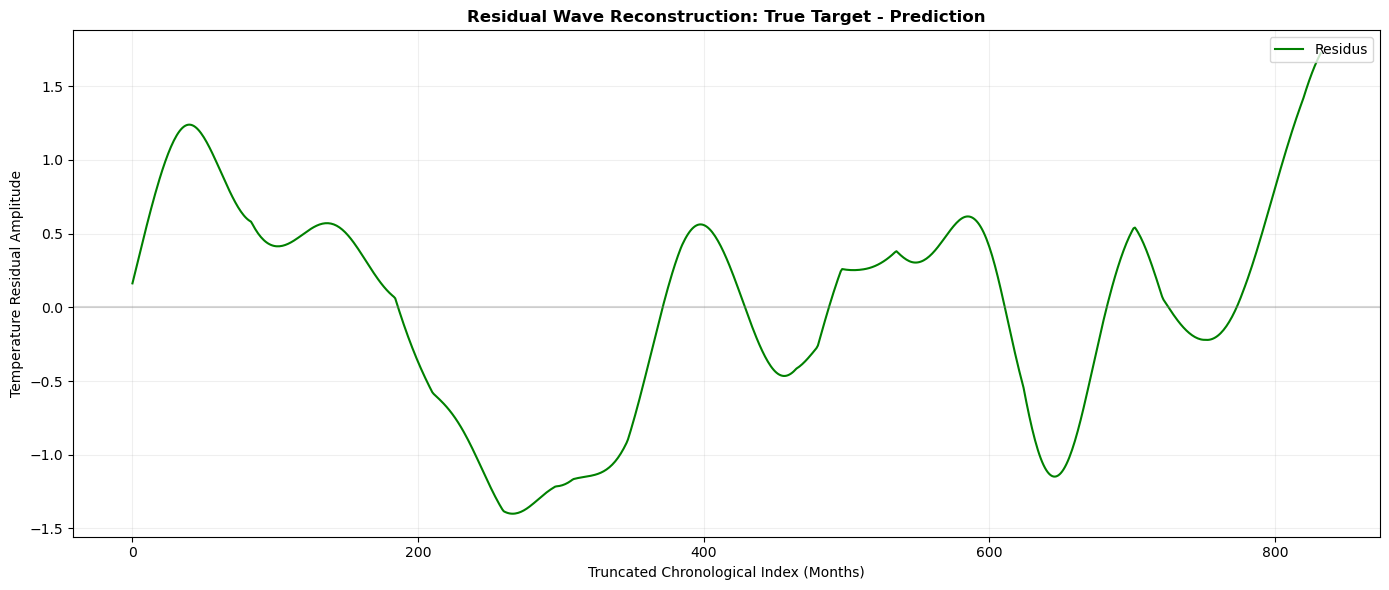

In [725]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pygam import LinearGAM, te
from sklearn.metrics import root_mean_squared_error, r2_score

# 1. Instantiate the optimal geometry

#optimal_model = LinearGAM(s(0, spline_order=1, n_splines=3) + s(1, spline_order=1, n_splines=2))
optimal_model = LinearGAM(s(0, by=1, spline_order=1, n_splines=2) + s(1, by=2, spline_order=1, n_splines=2) + s(0, by=2, spline_order=1, n_splines=3))
optimal_model = LinearGAM(te(0,1, spline_order=[1,1], n_splines=[2,2]))
optimal_model = LinearGAM(s(0, spline_order=1, n_splines=4) + s(1, spline_order=1, n_splines=2))
#optimal_model = LinearGAM(l(0) + s(1, by=2, spline_order=1, n_splines=2))
#optimal_model = LinearGAM(s(0, by=3, spline_order=1, n_splines=3) + s(1, by=2, spline_order=1, n_splines=2))
#optimal_model = LinearGAM(te(0,1))
#optimal_model = LinearGAM(l(0) +l(1))
optimal_model = LinearGAM(s(0, spline_order=1, n_splines=5, lam=7.5) + s(1, spline_order=1, n_splines=2))

optimal_model = LinearGAM(s(0, spline_order=1, n_splines=5, lam=7.5) + l(1))

# 2. Fit on the strictly truncated continuous matrix
print("Fitting final topological architecture on continuous matrix...")
y_base = df_gam_filtered['Temp_Cycle'].values[79:]
shifted_features = []
static_matrix = df_gam_filtered[static_covariates].values[79:] if static_covariates else np.empty((len(y_base), 0))
for feature, lag in fixed_lag_dict.items():
    shifted_col = df_gam_filtered[feature].shift(lag).values[79:]
    shifted_features.append(shifted_col)
        
if shifted_features:
    X_matrix = np.column_stack([*shifted_features, static_matrix])
else:
    X_matrix = static_matrix

optimal_model.fit(X_matrix, y_base)

# 3. Generate deterministic reconstruction
y_pred = optimal_model.predict(X_matrix)

# Compute final full-matrix metrics
final_rmse = np.sqrt(mean_squared_error(y_base, y_pred))
final_r2 = r2_score(y_base, y_pred)
print(f"Full Matrix Fit - RMSE: {final_rmse:.4f} | R2: {final_r2:.4f}")

# ==============================================================================
# VISUALIZATION 1: TEMPORAL RECONSTRUCTION
# ==============================================================================
plt.figure(figsize=(14, 6))

time_axis = np.arange(len(y_base))

#plt.plot(time_axis, y_base, color='black', label='True Target (Temp_Cycle)', linewidth=1.5)
#plt.plot(time_axis, y_pred, color='red', linestyle='--', label='Linear Model Prediction', linewidth=2)
plt.plot(time_axis, y_base-y_pred, color='green', label='Residus', linewidth=1.5)

plt.axhline(0, color='gray', linestyle='-', alpha=0.3)
plt.title("Residual Wave Reconstruction: True Target - Prediction", fontweight='bold')
plt.xlabel("Truncated Chronological Index (Months)")
plt.ylabel("Temperature Residual Amplitude")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

<>:44: SyntaxWarning: invalid escape sequence '\h'
<>:44: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_744259/1006992015.py:44: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Residual Error ($y - \hat{y}$)')


--- DESTRUCTIVE INTERFERENCE DIAGNOSTIC ---
Regime A [NAO- / AMO+] Count: 276 | Mean Error: 0.0841 | RMSE: 0.8268
Regime B [NAO+ / AMO-] Count: 127 | Mean Error: -0.0671 | RMSE: 0.4473


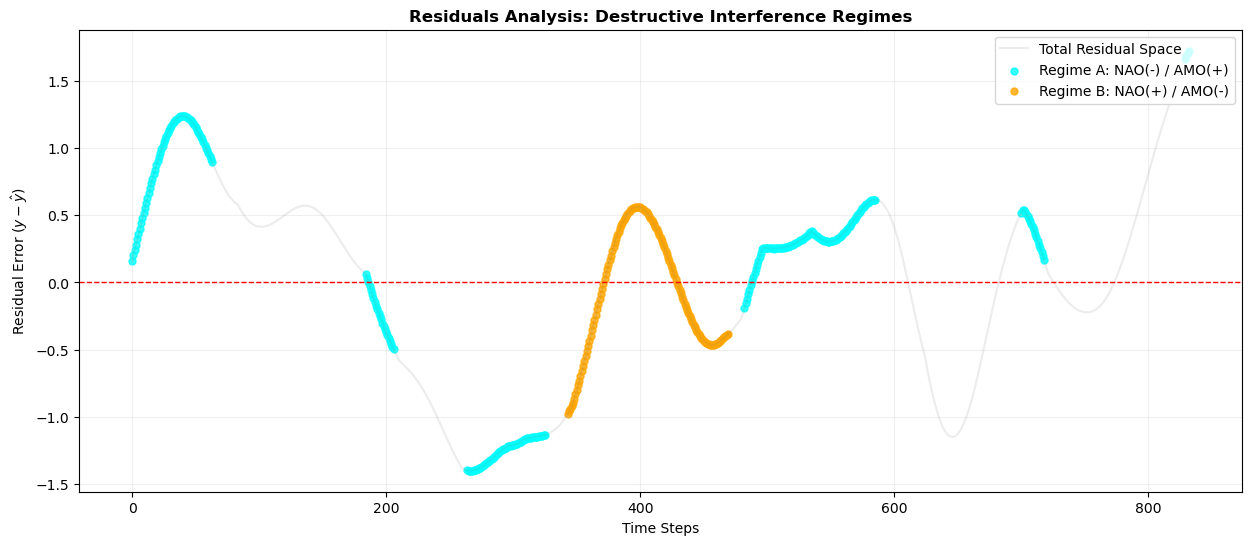

In [728]:
import numpy as np
import matplotlib.pyplot as plt

def plot_raw_opposing_signs_residuals(model, X, y, time_index=None):
    """
    Diagnostic suite for residuals during physical Destructive Interference.
    Uses raw standardized index values (X) to define regimes.
    """
    # 1. Calculate Total Prediction and Residuals
    y_pred = model.predict(X)
    residuals = y - y_pred
    
    # 2. Extract Raw Index Values
    raw_nao = X[:, 0]
    raw_amo = X[:, 1]
    
    # 3. Define the Physical Sign Masks
    # Regime A: NAO is in a negative phase, AMO is in a positive phase
    mask_nao_neg_amo_pos = (raw_nao < 0) & (raw_amo > 0)
    
    # Regime B: NAO is in a positive phase, AMO is in a negative phase
    mask_nao_pos_amo_neg = (raw_nao > 0) & (raw_amo < 0)
    
    # 4. Visualization
    plt.figure(figsize=(15, 6))
    t = time_index if time_index is not None else np.arange(len(residuals))
    
    # Plot All Residuals in background for context
    plt.plot(t, residuals, color='gray', alpha=0.15, label='Total Residual Space')
    
    # Scatter Regime A: Physical NAO(-) / AMO(+)
    plt.scatter(t[mask_nao_neg_amo_pos], residuals[mask_nao_neg_amo_pos], 
                color='cyan', s=25, alpha=0.8, edgecolors='k', 
                label='Regime A: Raw NAO(-) / AMO(+)')
    
    # Scatter Regime B: Physical NAO(+) / AMO(-)
    plt.scatter(t[mask_nao_pos_amo_neg], residuals[mask_nao_pos_amo_neg], 
                color='orange', s=25, alpha=0.8, edgecolors='k', 
                label='Regime B: Raw NAO(+) / AMO(-)')
    
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    plt.title('Residuals Analysis: Physical Opposing Sign Regimes', fontweight='bold')
    plt.xlabel('Time Steps')
    plt.ylabel('Residual Error ($y - \hat{y}$)')
    plt.legend(loc='upper right', frameon=True)
    plt.grid(True, alpha=0.2)
    
    # 5. Statistical Diagnostic
    res_a = residuals[mask_nao_neg_amo_pos]
    res_b = residuals[mask_nao_pos_amo_neg]
    
    # Calculate Mean Bias and RMSE per regime
    bias_a, rmse_a = np.mean(res_a), np.sqrt(np.mean(res_a**2))
    bias_b, rmse_b = np.mean(res_b), np.sqrt(np.mean(res_b**2))
    
    print("--- PHYSICAL SIGN INTERFERENCE DIAGNOSTIC ---")
    print(f"Regime A [NAO < 0, AMO > 0] | Count: {len(res_a)} | Bias: {bias_a:+.4f} | RMSE: {rmse_a:.4f}")
    print(f"Regime B [NAO > 0, AMO < 0] | Count: {len(res_b)} | Bias: {bias_b:+.4f} | RMSE: {rmse_b:.4f}")
    
    # Check for systematic bias shift
    bias_delta = np.abs(bias_a - bias_b)
    print(f"Inter-Regime Bias Delta: {bias_delta:.4f}")
    if bias_delta > 0.1:
        print("ALERT: Model exhibits a phase-dependent systematic bias.")
    
    plt.show()

# Execution:
plot_opposing_regime_residuals(optimal_model, X_matrix, y_base)

<>:46: SyntaxWarning: invalid escape sequence '\h'
<>:46: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_744259/952670083.py:46: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Residual Error ($y - \hat{y}$)')


Regime               | N     | Bias       | RMSE      
-------------------------------------------------------
Both Positive        | 135   |  -0.1120 |   0.4962
Both Negative        | 192   |  -0.1120 |   0.7719
NAO(-) / AMO(+)      | 243   |  +0.0412 |   0.6166
NAO(+) / AMO(-)      | 263   |  +0.1012 |   0.8335


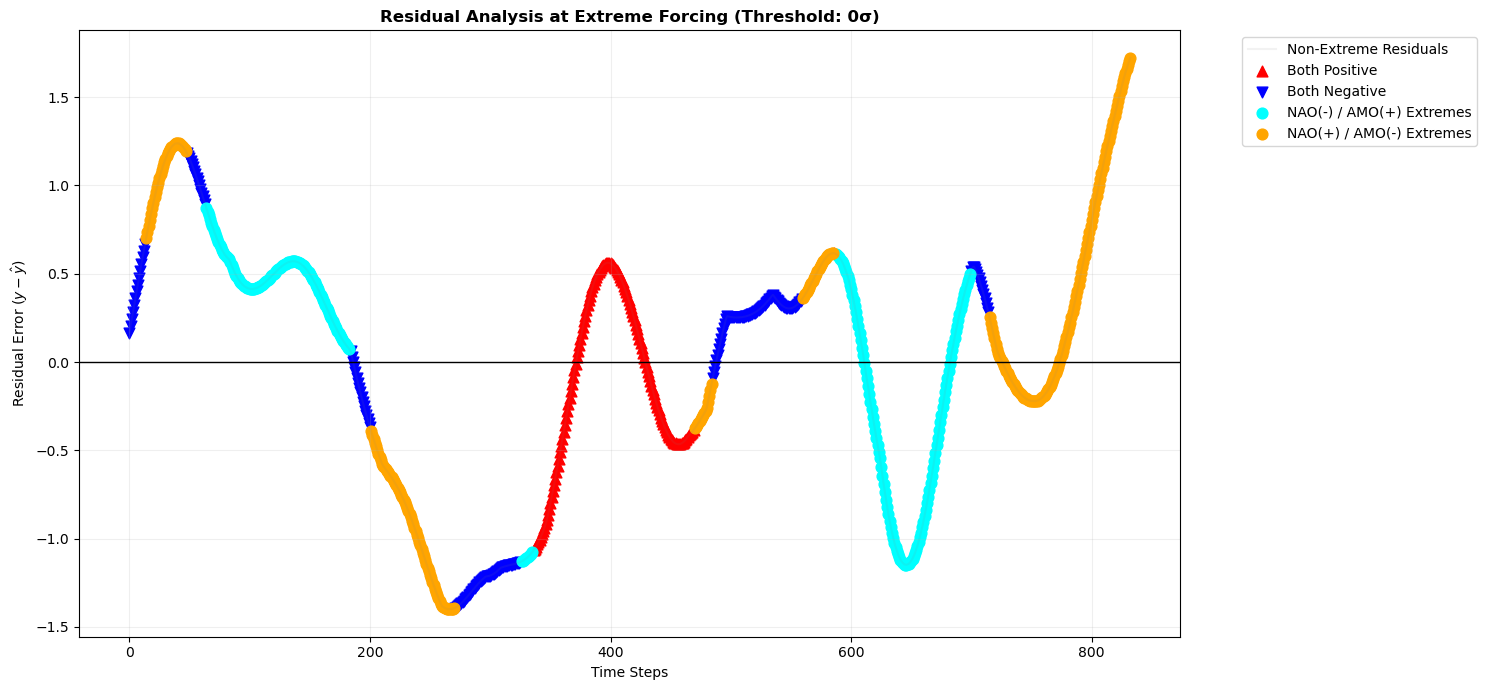

In [737]:
import numpy as np
import matplotlib.pyplot as plt

def plot_dual_extremes_residuals(model, X, y, threshold=1.5, time_index=None):
    """
    Diagnostic for residuals during simultaneous extreme phases of NAO and AMO.
    Categorizes events by the sign of the indices.
    """
    # 1. Calculate Total Prediction and Residuals
    y_pred = model.predict(X)
    residuals = y - y_pred
    
    # 2. Extract Raw Index Values
    raw_nao = X[:, 0]
    raw_amo = X[:, 1]
    
    # 3. Define the 4 Extreme Quadrant Masks
    # Quadrant 1: Both Positive (Synergistic High)
    q1_mask = (raw_nao > threshold) & (raw_amo > threshold)
    
    # Quadrant 2: Both Negative (Synergistic Low)
    q2_mask = (raw_nao < -threshold) & (raw_amo < -threshold)
    
    # Quadrant 3: NAO(-) / AMO(+) (Destructive A)
    q3_mask = (raw_nao < -threshold) & (raw_amo > threshold)
    
    # Quadrant 4: NAO(+) / AMO(-) (Destructive B)
    q4_mask = (raw_nao > threshold) & (raw_amo < -threshold)
    
    # 4. Visualization
    plt.figure(figsize=(15, 7))
    t = time_index if time_index is not None else np.arange(len(residuals))
    
    # Background: Total Residuals
    plt.plot(t, residuals, color='gray', alpha=0.1, label='Non-Extreme Residuals')
    
    # Scatter the 4 extreme states
    plt.scatter(t[q1_mask], residuals[q1_mask], color='red', marker='^', s=60, label=f'Both Positive')
    plt.scatter(t[q2_mask], residuals[q2_mask], color='blue', marker='v', s=60, label=f'Both Negative')
    plt.scatter(t[q3_mask], residuals[q3_mask], color='cyan', marker='o', s=60, label=f'NAO(-) / AMO(+) Extremes')
    plt.scatter(t[q4_mask], residuals[q4_mask], color='orange', marker='o', s=60, label=f'NAO(+) / AMO(-) Extremes')
    
    plt.axhline(0, color='black', linestyle='-', linewidth=1)
    plt.title(f'Residual Analysis at Extreme Forcing (Threshold: {threshold}σ)', fontweight='bold')
    plt.xlabel('Time Steps')
    plt.ylabel('Residual Error ($y - \hat{y}$)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.2)
    
    # 5. Statistical Diagnostic Table
    def get_stats(mask):
        if np.any(mask):
            res = residuals[mask]
            return len(res), np.mean(res), np.sqrt(np.mean(res**2))
        return 0, 0, 0

    stats_list = [
        ("Both Positive", q1_mask),
        ("Both Negative", q2_mask),
        ("NAO(-) / AMO(+)", q3_mask),
        ("NAO(+) / AMO(-)", q4_mask)
    ]
    
    print(f"{'Regime':<20} | {'N':<5} | {'Bias':<10} | {'RMSE':<10}")
    print("-" * 55)
    for name, mask in stats_list:
        n, bias, rmse = get_stats(mask)
        print(f"{name:<20} | {n:<5} | {bias:>+8.4f} | {rmse:>8.4f}")
    
    plt.tight_layout()
    plt.show()

# Execution
plot_dual_extremes_residuals(optimal_model, X_matrix, y_base, threshold=0)

<>:29: SyntaxWarning: invalid escape sequence '\h'
<>:30: SyntaxWarning: invalid escape sequence '\h'
<>:29: SyntaxWarning: invalid escape sequence '\h'
<>:30: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_744259/2630988048.py:29: SyntaxWarning: invalid escape sequence '\h'
  ax1.set_xlabel('Predicted Amplitude ($\hat{y}$)')
/tmp/ipykernel_744259/2630988048.py:30: SyntaxWarning: invalid escape sequence '\h'
  ax1.set_ylabel('Residual Error ($y - \hat{y}$)')


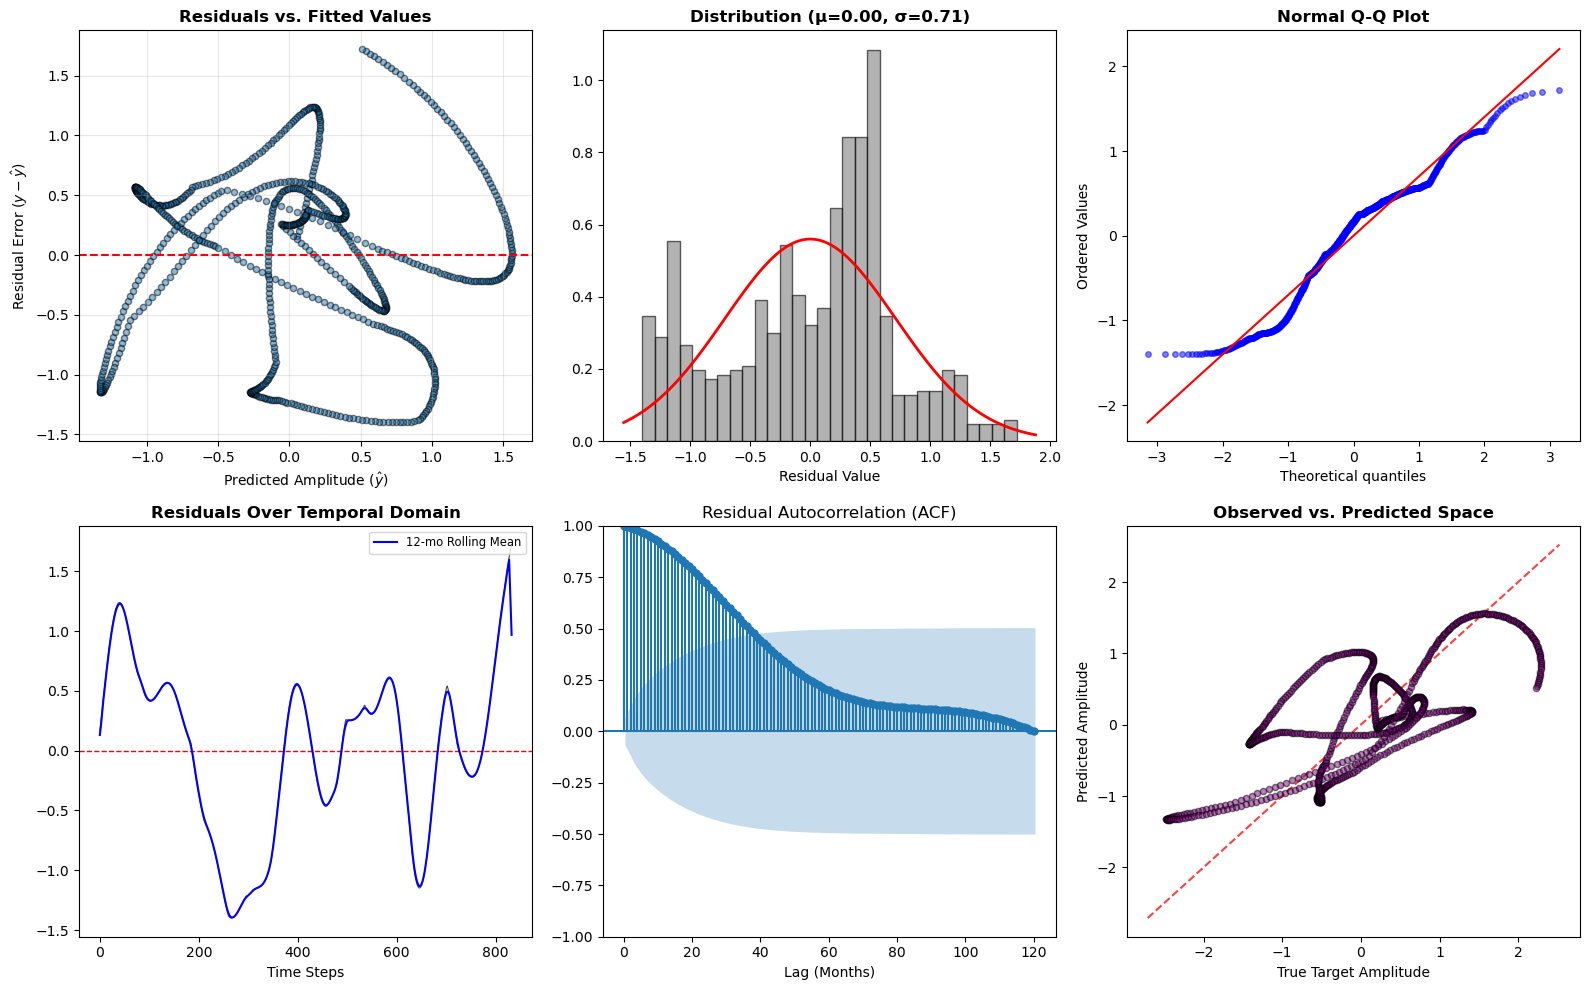

In [726]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf

def analyze_model_residuals(model, X, y, time_index=None):
    """
    Performs a strict visual diagnostic of GAM residuals.
    
    Parameters:
    model: Fitted LinearGAM instance.
    X: Feature matrix (standardized).
    y: Target vector (standardized).
    time_index: Optional array of timestamps or indices for temporal analysis.
    """
    # 1. Calculation of Residuals
    y_pred = model.predict(X)
    residuals = y - y_pred
    
    fig = plt.figure(figsize=(16, 10))
    
    # -------------------------------------------------------------------------
    # PANEL 1: Residuals vs. Fitted Values (Homoscedasticity)
    # -------------------------------------------------------------------------
    ax1 = fig.add_subplot(2, 3, 1)
    ax1.scatter(y_pred, residuals, alpha=0.5, edgecolors='k', s=20)
    ax1.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax1.set_title('Residuals vs. Fitted Values', fontweight='bold')
    ax1.set_xlabel('Predicted Amplitude ($\hat{y}$)')
    ax1.set_ylabel('Residual Error ($y - \hat{y}$)')
    ax1.grid(True, alpha=0.3)

    # -------------------------------------------------------------------------
    # PANEL 2: Histogram & KDE (Error Distribution)
    # -------------------------------------------------------------------------
    ax2 = fig.add_subplot(2, 3, 2)
    ax2.hist(residuals, bins=30, density=True, alpha=0.6, color='gray', edgecolor='black')
    # Fit a normal distribution curve
    mu, std = stats.norm.fit(residuals)
    xmin, xmax = ax2.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu, std)
    ax2.plot(x, p, 'r', linewidth=2)
    ax2.set_title(f'Distribution (μ={mu:.2f}, σ={std:.2f})', fontweight='bold')
    ax2.set_xlabel('Residual Value')

    # -------------------------------------------------------------------------
    # PANEL 3: Normal Q-Q Plot (Gaussian Convergence)
    # -------------------------------------------------------------------------
    ax3 = fig.add_subplot(2, 3, 3)
    stats.probplot(residuals, dist="norm", plot=ax3)
    ax3.get_lines()[0].set_markersize(4)
    ax3.get_lines()[0].set_alpha(0.5)
    ax3.set_title('Normal Q-Q Plot', fontweight='bold')

    # -------------------------------------------------------------------------
    # PANEL 4: Residuals Over Time (Deterministic Drift)
    # -------------------------------------------------------------------------
    ax4 = fig.add_subplot(2, 3, 4)
    t = time_index if time_index is not None else np.arange(len(residuals))
    ax4.plot(t, residuals, color='black', linewidth=0.8, alpha=0.7)
    ax4.axhline(0, color='red', linestyle='--', linewidth=1)
    # Add a rolling mean to detect unmodeled trends
    rolling_mean = np.convolve(residuals, np.ones(12)/12, mode='same')
    ax4.plot(t, rolling_mean, color='blue', linewidth=1.5, label='12-mo Rolling Mean')
    ax4.set_title('Residuals Over Temporal Domain', fontweight='bold')
    ax4.set_xlabel('Time Steps')
    ax4.legend(loc='upper right', fontsize='small')

    # -------------------------------------------------------------------------
    # PANEL 5: Autocorrelation Function (ACF - Memory Check)
    # -------------------------------------------------------------------------
    ax5 = fig.add_subplot(2, 3, 5)
    plot_acf(residuals, lags=120, ax=ax5, title='Residual Autocorrelation (ACF)')
    ax5.set_xlabel('Lag (Months)')

    # -------------------------------------------------------------------------
    # PANEL 6: Observed vs. Predicted (Accuracy Mapping)
    # -------------------------------------------------------------------------
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.scatter(y, y_pred, alpha=0.5, edgecolors='k', s=20, color='purple')
    lims = [np.min([ax6.get_xlim(), ax6.get_ylim()]), np.max([ax6.get_xlim(), ax6.get_ylim()])]
    ax6.plot(lims, lims, 'r--', alpha=0.75, zorder=0)
    ax6.set_title('Observed vs. Predicted Space', fontweight='bold')
    ax6.set_xlabel('True Target Amplitude')
    ax6.set_ylabel('Predicted Amplitude')

    plt.tight_layout()
    plt.show()

# Execution:
analyze_model_residuals(optimal_model, X_matrix, y_base, time_index=time_axis)

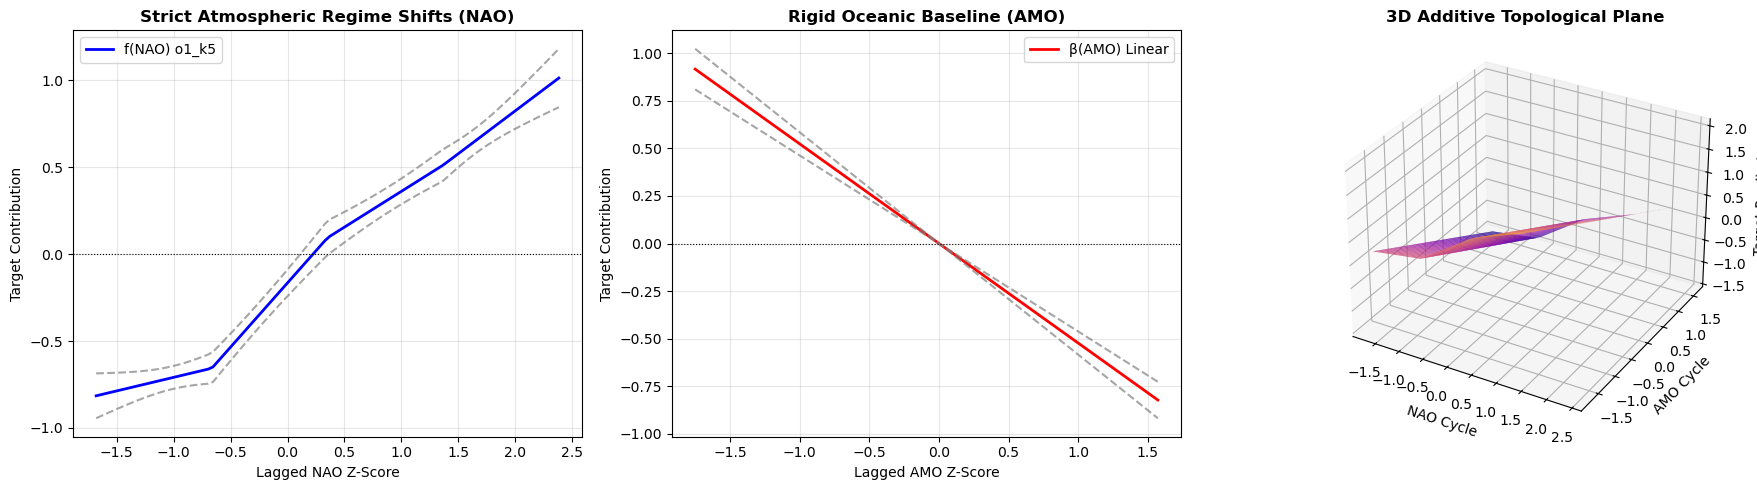

In [709]:
optimal_3d_model = LinearGAM(s(0, spline_order=1, n_splines=5, lam=7.5) + l(1))

def execute_strict_visual_analysis(model, X_matrix, y_target):
    """
    Renders the exact topological geometry and residual space of the optimized 
    piecewise-linear Additive Model.
    """
    model.fit(X_matrix, y_target)
    fig = plt.figure(figsize=(18, 5))

    # =========================================================================
    # PANEL 1: NAO PIECEWISE MARGINAL DEPENDENCE (o1_k5_L7.5)
    # =========================================================================
    ax1 = fig.add_subplot(1, 3, 1)
    XX_nao = model.generate_X_grid(term=0)
    pdep_nao, confi_nao = model.partial_dependence(term=0, X=XX_nao, width=0.95)
    
    ax1.plot(XX_nao[:, 0], pdep_nao, color='blue', linewidth=2, label='f(NAO) o1_k5')
    ax1.plot(XX_nao[:, 0], confi_nao, color='grey', linestyle='--', alpha=0.7)
    ax1.set_title('Strict Atmospheric Regime Shifts (NAO)', fontweight='bold')
    ax1.set_xlabel('Lagged NAO Z-Score')
    ax1.set_ylabel('Target Contribution')
    ax1.axhline(0, color='black', linewidth=0.8, linestyle=':')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # =========================================================================
    # PANEL 2: AMO RIGID LINEAR BASELINE (l1)
    # =========================================================================
    ax2 = fig.add_subplot(1, 3, 2)
    XX_amo = model.generate_X_grid(term=1)
    pdep_amo, confi_amo = model.partial_dependence(term=1, X=XX_amo, width=0.95)
    
    ax2.plot(XX_amo[:, 1], pdep_amo, color='red', linewidth=2, label='β(AMO) Linear')
    ax2.plot(XX_amo[:, 1], confi_amo, color='grey', linestyle='--', alpha=0.7)
    ax2.set_title('Rigid Oceanic Baseline (AMO)', fontweight='bold')
    ax2.set_xlabel('Lagged AMO Z-Score')
    ax2.set_ylabel('Target Contribution')
    ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    # =========================================================================
    # PANEL 3: 3D EXTRUDED PIECEWISE PLANE
    # =========================================================================
    ax3 = fig.add_subplot(1, 3, 3, projection='3d')
    x_grid = np.linspace(X_matrix[:, 0].min(), X_matrix[:, 0].max(), 50)
    y_grid = np.linspace(X_matrix[:, 1].min(), X_matrix[:, 1].max(), 50)
    X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)
    
    # Constructing the synthetic predictive space
    Z_pred = model.predict(np.column_stack((X_mesh.ravel(), Y_mesh.ravel()))).reshape(X_mesh.shape)
    
    ax3.plot_surface(X_mesh, Y_mesh, Z_pred, cmap='plasma', edgecolor='none', alpha=0.9)
    ax3.set_title('3D Additive Topological Plane', fontweight='bold')
    ax3.set_xlabel('NAO Cycle')
    ax3.set_ylabel('AMO Cycle')
    ax3.set_zlabel('Target Prediction')

    plt.tight_layout()
    plt.show()


execute_strict_visual_analysis(optimal_3d_model, X_matrix[:, :2], y_base)

=== STRICT ARCHITECTURE DIAGNOSTIC ===

MODEL A: LinearGAM(te(0, 1, spline_order=[1, 2], n_splines=[2, 3]))
  -> Pseudo R-Squared: 0.5202
  -> GCV Score:        0.0243
  -> AIC:              -734.87

MODEL B: LinearGAM(te(0,1, spline_order=[1,1], n_splines=[2,2]))
  -> Pseudo R-Squared: 0.4977
  -> GCV Score:        0.0254
  -> AIC:              -697.98

--- AIC DELTA: -36.89 ---
Verdict: The independent additive plane (Model A) is statistically superior. Model B is overfitting.


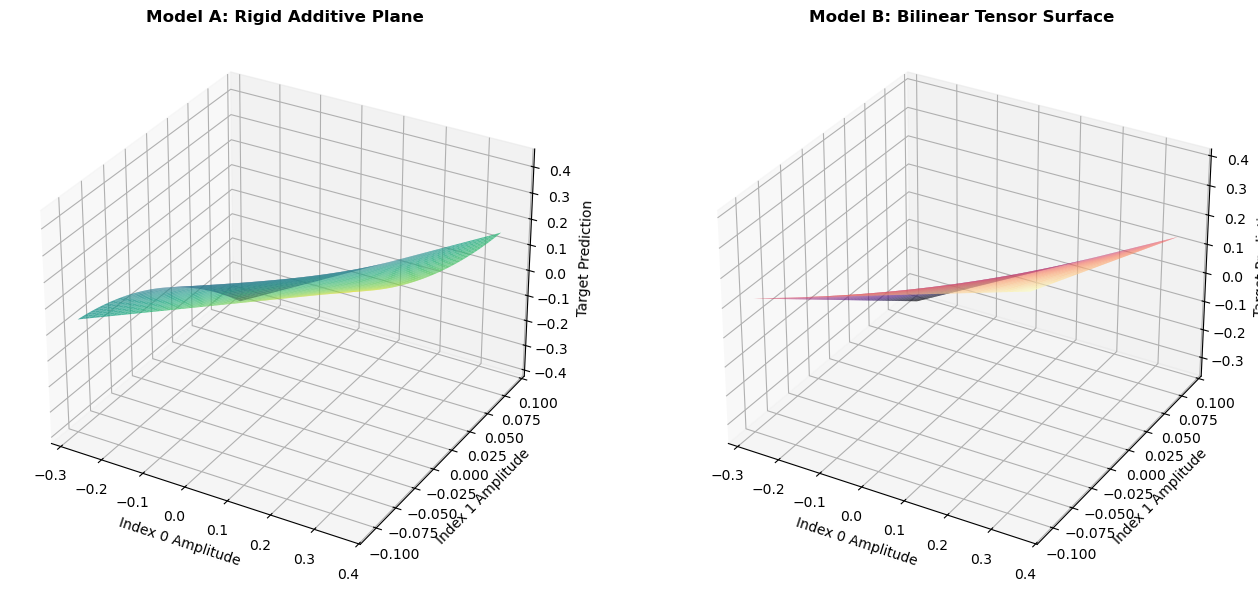

In [566]:
import numpy as np
import matplotlib.pyplot as plt
from pygam import LinearGAM, l, te
from sklearn.metrics import mean_squared_error

def execute_tensor_comparison(X_matrix, y_target):
    """
    Executes a strict mathematical comparison between an independent linear additive 
    architecture and a bilinear tensor product architecture.
    """
    # =========================================================================
    # 1. MODEL INITIALIZATION AND FITTING
    # =========================================================================
    model_A = LinearGAM(te(0, 1, spline_order=[1, 2], n_splines=[2, 3])).fit(X_matrix, y_target)
    model_B = LinearGAM(te(0, 1, spline_order=[1, 1], n_splines=[2, 2])).fit(X_matrix, y_target)

    # =========================================================================
    # 2. ECONOMETRIC METRICS EXTRACTION
    # =========================================================================
    print("=== STRICT ARCHITECTURE DIAGNOSTIC ===\n")
    
    print("MODEL A: LinearGAM(te(0, 1, spline_order=[1, 2], n_splines=[2, 3]))")
    print(f"  -> Pseudo R-Squared: {model_A.statistics_['pseudo_r2']['explained_deviance']:.4f}")
    print(f"  -> GCV Score:        {model_A.statistics_['GCV']:.4f}")
    print(f"  -> AIC:              {model_A.statistics_['AIC']:.2f}")
    
    print("\nMODEL B: LinearGAM(te(0,1, spline_order=[1,1], n_splines=[2,2]))")
    print(f"  -> Pseudo R-Squared: {model_B.statistics_['pseudo_r2']['explained_deviance']:.4f}")
    print(f"  -> GCV Score:        {model_B.statistics_['GCV']:.4f}")
    print(f"  -> AIC:              {model_B.statistics_['AIC']:.2f}")

    aic_delta = model_A.statistics_['AIC'] - model_B.statistics_['AIC']
    print(f"\n--- AIC DELTA: {aic_delta:.2f} ---")
    if aic_delta > 2:
        print("Verdict: The bilinear interaction (Model B) is statistically significant.")
    elif aic_delta < -2:
        print("Verdict: The independent additive plane (Model A) is statistically superior. Model B is overfitting.")
    else:
        print("Verdict: The interaction effect is statistically ambiguous. Default to the simpler architecture (Model A).")

    # =========================================================================
    # 3. 3D GEOMETRIC VISUALIZATION
    # =========================================================================
    fig = plt.figure(figsize=(14, 6))
    
    x_grid = np.linspace(X_matrix[:, 0].min(), X_matrix[:, 0].max(), 50)
    y_grid = np.linspace(X_matrix[:, 1].min(), X_matrix[:, 1].max(), 50)
    X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)
    
    # Predict arrays
    Z_A = model_A.predict(np.column_stack((X_mesh.ravel(), Y_mesh.ravel()))).reshape(X_mesh.shape)
    Z_B = model_B.predict(np.column_stack((X_mesh.ravel(), Y_mesh.ravel()))).reshape(X_mesh.shape)
    
    # Plot Model A
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.plot_surface(X_mesh, Y_mesh, Z_A, cmap='viridis', edgecolor='none', alpha=0.8)
    ax1.set_title('Model A: Rigid Additive Plane', fontweight='bold')
    ax1.set_xlabel('Index 0 Amplitude')
    ax1.set_ylabel('Index 1 Amplitude')
    ax1.set_zlabel('Target Prediction')
    
    # Plot Model B
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.plot_surface(X_mesh, Y_mesh, Z_B, cmap='magma', edgecolor='none', alpha=0.8)
    ax2.set_title('Model B: Bilinear Tensor Surface', fontweight='bold')
    ax2.set_xlabel('Index 0 Amplitude')
    ax2.set_ylabel('Index 1 Amplitude')
    ax2.set_zlabel('Target Prediction')

    plt.tight_layout()
    plt.show()

execute_tensor_comparison(X_matrix[:, :2], y_base)

Fitting varying coefficient tensor architecture...


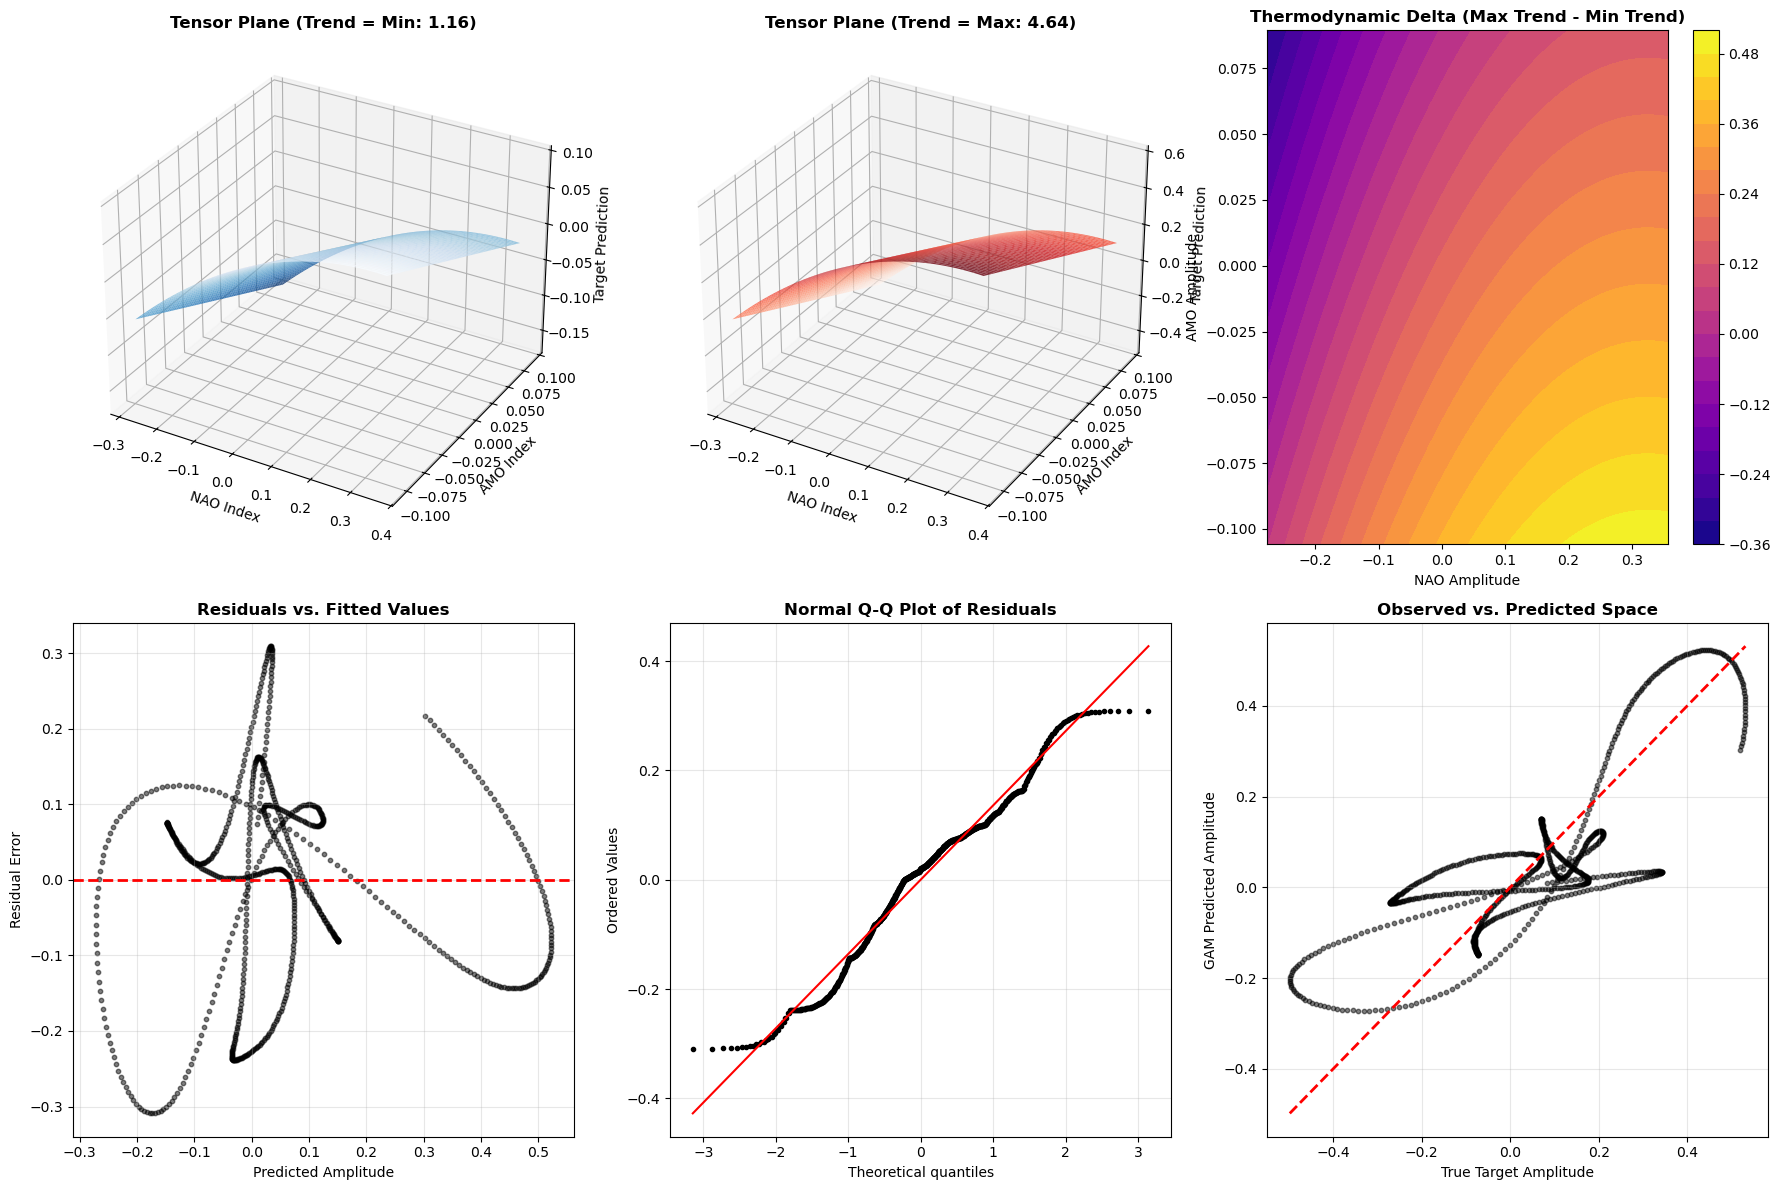

In [543]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.stats as stats

def visualize_varying_tensor_gam(model, X_matrix, y_target):
    """
    Executes a 6-panel diagnostic matrix strictly designed for a varying-coefficient
    tensor product model: te(0, 1, by=2).
    """
    if not model._is_fitted:
        print("Fitting varying coefficient tensor architecture...")
        model.fit(X_matrix, y_target)

    preds = model.predict(X_matrix)
    residuals = y_target - preds

    fig = plt.figure(figsize=(18, 12))

    # =========================================================================
    # 0. STRICT TENSOR GRID GENERATION
    # =========================================================================
    nao_lin = np.linspace(X_matrix[:, 0].min(), X_matrix[:, 0].max(), 50)
    amo_lin = np.linspace(X_matrix[:, 1].min(), X_matrix[:, 1].max(), 50)
    X_mesh, Y_mesh = np.meshgrid(nao_lin, amo_lin)

    # Isolate the minimum and maximum extremes of the Anthropogenic Trend
    trend_min = X_matrix[:, 2].min()
    trend_max = X_matrix[:, 2].max()

    n_points = len(X_mesh.ravel())
    X_pred_min = np.zeros((n_points, X_matrix.shape[1]))
    X_pred_max = np.zeros((n_points, X_matrix.shape[1]))

    # Maintain background variables at empirical mean
    for i in range(X_matrix.shape[1]):
        X_pred_min[:, i] = np.mean(X_matrix[:, i])
        X_pred_max[:, i] = np.mean(X_matrix[:, i])

    # Construct the Minimum Trend Tensor
    X_pred_min[:, 0] = X_mesh.ravel()
    X_pred_min[:, 1] = Y_mesh.ravel()
    X_pred_min[:, 2] = trend_min

    # Construct the Maximum Trend Tensor
    X_pred_max[:, 0] = X_mesh.ravel()
    X_pred_max[:, 1] = Y_mesh.ravel()
    X_pred_max[:, 2] = trend_max

    Z_min = model.predict(X_pred_min).reshape(X_mesh.shape)
    Z_max = model.predict(X_pred_max).reshape(X_mesh.shape)

    # =========================================================================
    # 1. TENSOR SURFACE AT HISTORICAL MINIMUM TREND
    # =========================================================================
    ax1 = fig.add_subplot(2, 3, 1, projection='3d')
    ax1.plot_surface(X_mesh, Y_mesh, Z_min, cmap='Blues_r', edgecolor='none', alpha=0.8)
    ax1.set_title(f'Tensor Plane (Trend = Min: {trend_min:.2f})', fontweight='bold')
    ax1.set_xlabel('NAO Index')
    ax1.set_ylabel('AMO Index')
    ax1.set_zlabel('Target Prediction')

    # =========================================================================
    # 2. TENSOR SURFACE AT MODERN MAXIMUM TREND
    # =========================================================================
    ax2 = fig.add_subplot(2, 3, 2, projection='3d')
    ax2.plot_surface(X_mesh, Y_mesh, Z_max, cmap='Reds', edgecolor='none', alpha=0.8)
    ax2.set_title(f'Tensor Plane (Trend = Max: {trend_max:.2f})', fontweight='bold')
    ax2.set_xlabel('NAO Index')
    ax2.set_ylabel('AMO Index')
    ax2.set_zlabel('Target Prediction')

    # =========================================================================
    # 3. THERMODYNAMIC DELTA (Modulation Magnitude)
    # Proves exactly how the trend physically warps the natural variance.
    # =========================================================================
    ax3 = fig.add_subplot(2, 3, 3)
    Z_delta = Z_max - Z_min
    contour = ax3.contourf(X_mesh, Y_mesh, Z_delta, 20, cmap='plasma')
    plt.colorbar(contour, ax=ax3)
    ax3.set_title('Thermodynamic Delta (Max Trend - Min Trend)', fontweight='bold')
    ax3.set_xlabel('NAO Amplitude')
    ax3.set_ylabel('AMO Amplitude')

    # =========================================================================
    # 4. RESIDUALS VS FITTED (Heteroscedasticity)
    # =========================================================================
    ax4 = fig.add_subplot(2, 3, 4)
    ax4.scatter(preds, residuals, alpha=0.5, color='black', s=10)
    ax4.axhline(0, color='red', linestyle='--', linewidth=2)
    ax4.set_title('Residuals vs. Fitted Values', fontweight='bold')
    ax4.set_xlabel('Predicted Amplitude')
    ax4.set_ylabel('Residual Error')
    ax4.grid(alpha=0.3)

    # =========================================================================
    # 5. NORMAL Q-Q PLOT
    # =========================================================================
    ax5 = fig.add_subplot(2, 3, 5)
    stats.probplot(residuals, dist="norm", plot=ax5)
    ax5.get_lines()[0].set_markerfacecolor('black')
    ax5.get_lines()[0].set_markeredgecolor('black')
    ax5.get_lines()[0].set_markersize(3)
    ax5.get_lines()[1].set_color('red')
    ax5.set_title('Normal Q-Q Plot of Residuals', fontweight='bold')
    ax5.grid(alpha=0.3)

    # =========================================================================
    # 6. GLOBAL R2 GEOMETRY
    # =========================================================================
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.scatter(y_target, preds, alpha=0.5, color='black', s=10)
    min_val = min(y_target.min(), preds.min())
    max_val = max(y_target.max(), preds.max())
    ax6.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
    ax6.set_title('Observed vs. Predicted Space', fontweight='bold')
    ax6.set_xlabel('True Target Amplitude')
    ax6.set_ylabel('GAM Predicted Amplitude')
    ax6.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Execution syntax:
visualize_varying_tensor_gam(LinearGAM(s(0, by=2, spline_order=2, n_splines=3) + s(1, by=2, spline_order=1, n_splines=2)), X_matrix, y_base)

Fitting topological architecture to continuous matrix...


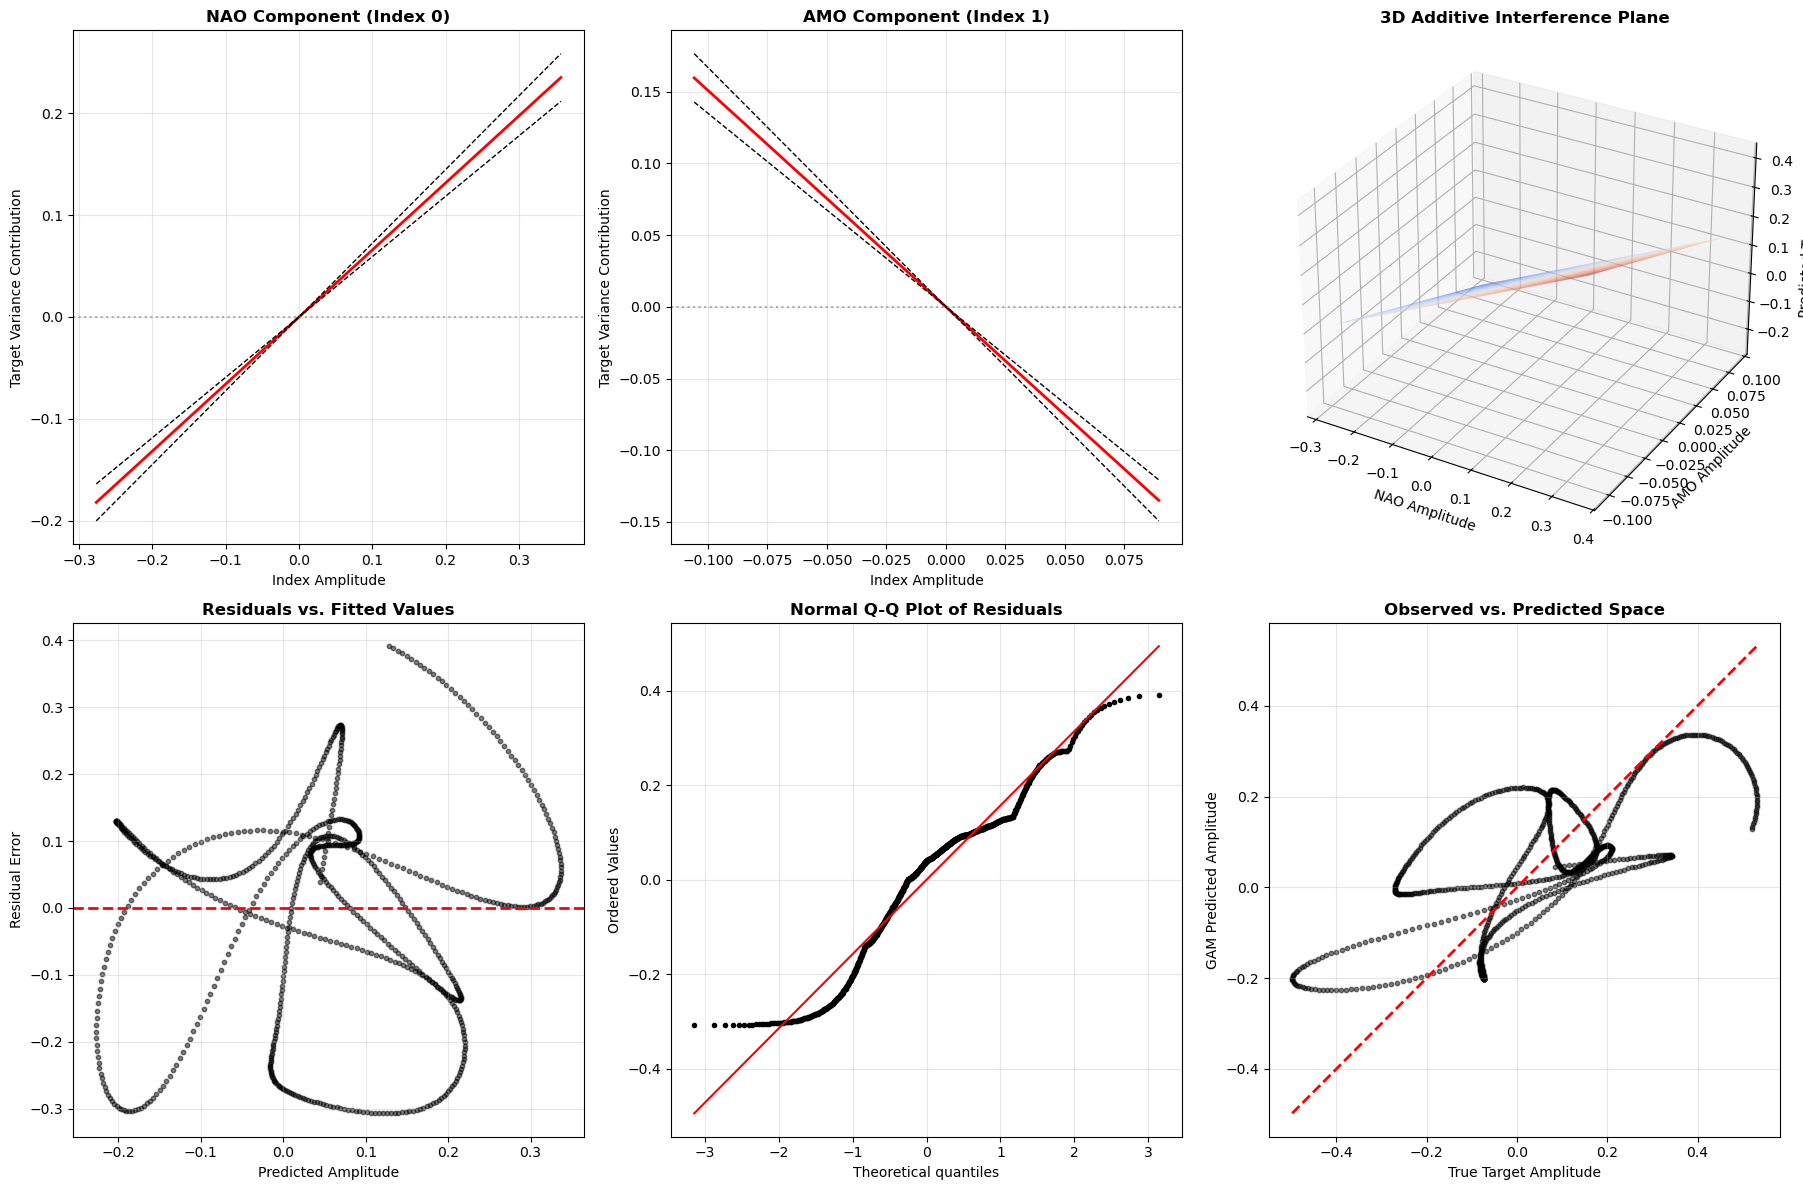

In [520]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.stats as stats

def generate_gam_diagnostic_matrix(model, X_matrix, y_target):
    """
    Executes a strict 4-panel diagnostic suite for a GAM architecture.
    Automatically pads missing background dimensions to prevent PyGAM tensor mismatch.
    """
    # =========================================================================
    # 0. STRICT MATRIX INITIALIZATION
    # =========================================================================
    if not model._is_fitted:
        print("Fitting topological architecture to continuous matrix...")
        model.fit(X_matrix, y_target)
        
    fig = plt.figure(figsize=(18, 12))
    preds = model.predict(X_matrix)
    residuals = y_target - preds

    # =========================================================================
    # 1. PARTIAL DEPENDENCE PLOTS (Component Functions)
    # =========================================================================
    titles = ['NAO Component (Index 0)', 'AMO Component (Index 1)']
    
    for i in range(2): 
        ax = fig.add_subplot(2, 3, i+1)
        XX = model.generate_X_grid(term=i)
        pdep, confi = model.partial_dependence(term=i, X=XX, width=0.95)
        
        ax.plot(XX[:, i], pdep, color='red', linewidth=2)
        ax.plot(XX[:, i], confi, color='black', linestyle='--', linewidth=1)
        ax.axhline(0, color='gray', linestyle=':', alpha=0.6)
        ax.set_title(titles[i], fontweight='bold')
        ax.set_xlabel('Index Amplitude')
        ax.set_ylabel('Target Variance Contribution')
        ax.grid(alpha=0.3)

    # =========================================================================
    # 2. 3D THERMODYNAMIC SURFACE (Interference Plane)
    # Dynamically scales to X_matrix.shape[1] to prevent dimensional collapse.
    # =========================================================================
    ax3 = fig.add_subplot(2, 3, 3, projection='3d')
    
    x_grid = np.linspace(X_matrix[:, 0].min(), X_matrix[:, 0].max(), 50)
    y_grid = np.linspace(X_matrix[:, 1].min(), X_matrix[:, 1].max(), 50)
    X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)
    
    # Extract total number of columns in the empirical tensor
    n_features = X_matrix.shape[1]
    
    # Initialize a baseline matrix padded strictly with the empirical means
    X_predict_padded = np.zeros((len(X_mesh.ravel()), n_features))
    for i in range(n_features):
        X_predict_padded[:, i] = np.mean(X_matrix[:, i])
        
    # Overwrite Index 0 and 1 with the 3D surface permutations
    X_predict_padded[:, 0] = X_mesh.ravel()
    X_predict_padded[:, 1] = Y_mesh.ravel()
    
    # Flatten, predict, and reshape
    Z_flat = model.predict(X_predict_padded)
    Z_mesh = Z_flat.reshape(X_mesh.shape)
    
    surf = ax3.plot_surface(X_mesh, Y_mesh, Z_mesh, cmap='coolwarm', edgecolor='none', alpha=0.8)
    ax3.set_title('3D Additive Interference Plane', fontweight='bold')
    ax3.set_xlabel('NAO Amplitude')
    ax3.set_ylabel('AMO Amplitude')
    ax3.set_zlabel('Predicted Temp Cycle')

    # =========================================================================
    # 3. RESIDUAL VS FITTED (Heteroscedasticity Test)
    # =========================================================================
    ax4 = fig.add_subplot(2, 3, 4)
    ax4.scatter(preds, residuals, alpha=0.5, color='black', s=10)
    ax4.axhline(0, color='red', linestyle='--', linewidth=2)
    ax4.set_title('Residuals vs. Fitted Values', fontweight='bold')
    ax4.set_xlabel('Predicted Amplitude')
    ax4.set_ylabel('Residual Error')
    ax4.grid(alpha=0.3)

    # =========================================================================
    # 4. Q-Q PLOT (Normality of Residuals)
    # =========================================================================
    ax5 = fig.add_subplot(2, 3, 5)
    stats.probplot(residuals, dist="norm", plot=ax5)
    ax5.get_lines()[0].set_markerfacecolor('black')
    ax5.get_lines()[0].set_markeredgecolor('black')
    ax5.get_lines()[0].set_markersize(3)
    ax5.get_lines()[1].set_color('red')
    ax5.set_title('Normal Q-Q Plot of Residuals', fontweight='bold')
    ax5.grid(alpha=0.3)

    # =========================================================================
    # 5. PREDICTED VS OBSERVED SCATTER (Global R2 Geometry)
    # =========================================================================
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.scatter(y_target, preds, alpha=0.5, color='black', s=10)
    
    min_val = min(y_target.min(), preds.min())
    max_val = max(y_target.max(), preds.max())
    ax6.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
    
    ax6.set_title('Observed vs. Predicted Space', fontweight='bold')
    ax6.set_xlabel('True Target Amplitude')
    ax6.set_ylabel('GAM Predicted Amplitude')
    ax6.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Execution Command:
generate_gam_diagnostic_matrix(LinearGAM(l(0) + l(1)), X_matrix, y_base)

In [ ]:
import numpy as np
from scipy.interpolate import UnivariateSpline

# Assuming 'y_raw' is your 1D array of raw temperature data
x_index = np.arange(len(df_climate["raw"]))

# Execute the 2nd-order spline approximation
# k=2 sets the polynomial order strictly to quadratic
# s=None allows the algorithm to estimate an initial smoothing penalty based on variance
# Increase 's' (e.g., s=5.0) to force a stiffer wave; decrease to track high-frequency variance
quadratic_spline = UnivariateSpline(x_index, df_climate["raw"], k=2, s=None)

# Extract the continuous approximated array
y_spline_approx = quadratic_spline(x_index)

In [675]:
import numpy as np
from pygam import LinearGAM, s

# Define the chronological coordinate vector
x_index = np.arange(len(df_climate["raw"])).reshape(-1, 1)

# Define the topological architecture
# s(0) isolates the time index
# spline_order=2 enforces the quadratic constraint
# n_splines dictates the maximum allowable basis functions (knots)
spline_model = LinearGAM(s(0, spline_order=2, n_splines=15))

# Fit the matrix using Generalized Cross-Validation (GCV) to optimize the lambda penalty
spline_model.fit(x_index, df_climate["raw"])

# Extract the continuous approximated array
y_gam_approx = spline_model.predict(x_index)

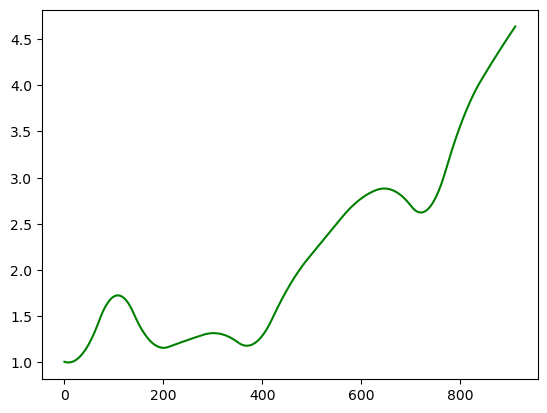

In [678]:
plt.plot(x_index, df_gam_filtered['Pred'], color='green', label='Residus', linewidth=1.5)
#plt.plot(x_index, df_climate["raw"], color='black', label='Residus', linewidth=1.5)

In [677]:
df_gam_filtered['Pred'] = (y_gam_approx - np.min(y_gam_approx))/np.std(y_gam_approx) +1
df_gam_filtered['Inv_Pred'] = 1/df_gam_filtered['Pred']

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_partial_dependence(model):
    """
    Isolates and plots the independent spline/linear topologies of the GAM.
    """
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    titles = ['V0: NAO (Spline Order 2)', 'V1: AMO (Spline Order 1)', 'V2: ERF Trend (Linear)']
    
    for i, ax in enumerate(axs):
        # Generate the partial dependence matrix and 95% confidence intervals
        XX = model.generate_X_grid(term=i)
        pdep, confi = model.partial_dependence(term=i, x=XX)
        
        ax.plot(XX[:, i], pdep, color='black', linewidth=2)
        ax.plot(XX[:, i], confi, c='red', ls='--', alpha=0.5)
        
        ax.set_title(titles[i], fontweight='bold')
        ax.set_ylabel('Target Anomaly Amplitude')
        ax.set_xlabel('Standardized Index')
        ax.axhline(0, color='gray', linestyle=':', alpha=0.7)
        ax.grid(alpha=0.3)
        
    plt.tight_layout()
    plt.show()

plot_partial_dependence(gam_3d_model)

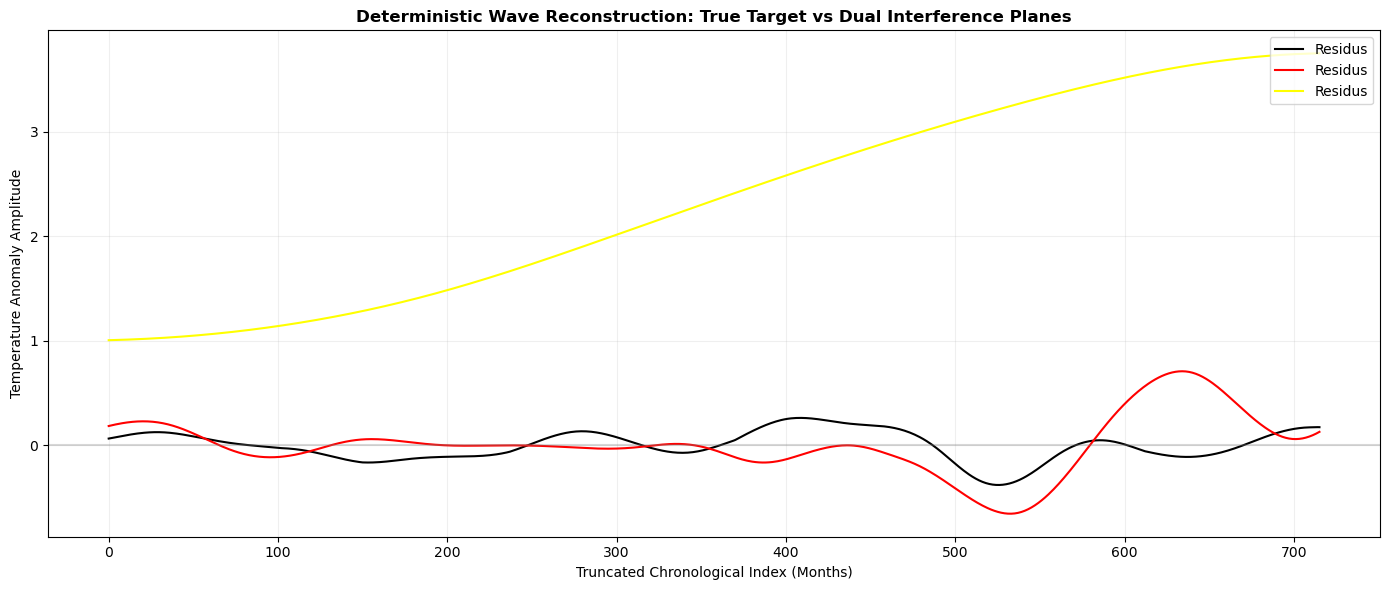

In [436]:
plt.figure(figsize=(14, 6))

time_axis = np.arange(len(y_base))

plt.plot(time_axis, y_base-y_pred, color='black', label='Residus', linewidth=1.5)
plt.plot(time_axis, (df_gam_filtered["AMO_Cycle"]*df_gam_filtered["NAO_Cycle"])[196:]*5, color='red', label='Residus', linewidth=1.5)
plt.plot(time_axis, (df_gam_filtered["Trend"])[196:], color='yellow', label='Residus', linewidth=1.5)


plt.axhline(0, color='gray', linestyle='-', alpha=0.3)
plt.title("Deterministic Wave Reconstruction: True Target vs Dual Interference Planes", fontweight='bold')
plt.xlabel("Truncated Chronological Index (Months)")
plt.ylabel("Temperature Anomaly Amplitude")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [393]:
compute_dominant_period(y_base-y_pred)


np.float64(356.0)

<>:43: SyntaxWarning: invalid escape sequence '\D'
<>:58: SyntaxWarning: invalid escape sequence '\D'
<>:67: SyntaxWarning: invalid escape sequence '\h'
<>:85: SyntaxWarning: invalid escape sequence '\e'
<>:86: SyntaxWarning: invalid escape sequence '\h'
<>:87: SyntaxWarning: invalid escape sequence '\e'
<>:43: SyntaxWarning: invalid escape sequence '\D'
<>:58: SyntaxWarning: invalid escape sequence '\D'
<>:67: SyntaxWarning: invalid escape sequence '\h'
<>:85: SyntaxWarning: invalid escape sequence '\e'
<>:86: SyntaxWarning: invalid escape sequence '\h'
<>:87: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_744259/3227984009.py:43: SyntaxWarning: invalid escape sequence '\D'
  ax1.set_ylabel('Partial Temperature Variance ($\Delta Y$)')
/tmp/ipykernel_744259/3227984009.py:58: SyntaxWarning: invalid escape sequence '\D'
  ax2.set_ylabel('Partial Temperature Variance ($\Delta Y$)')
/tmp/ipykernel_744259/3227984009.py:67: SyntaxWarning: invalid escape sequence '\h'
  ax3.plot(t

ValueError: x and y must have same first dimension, but have shapes (832,) and (798,)

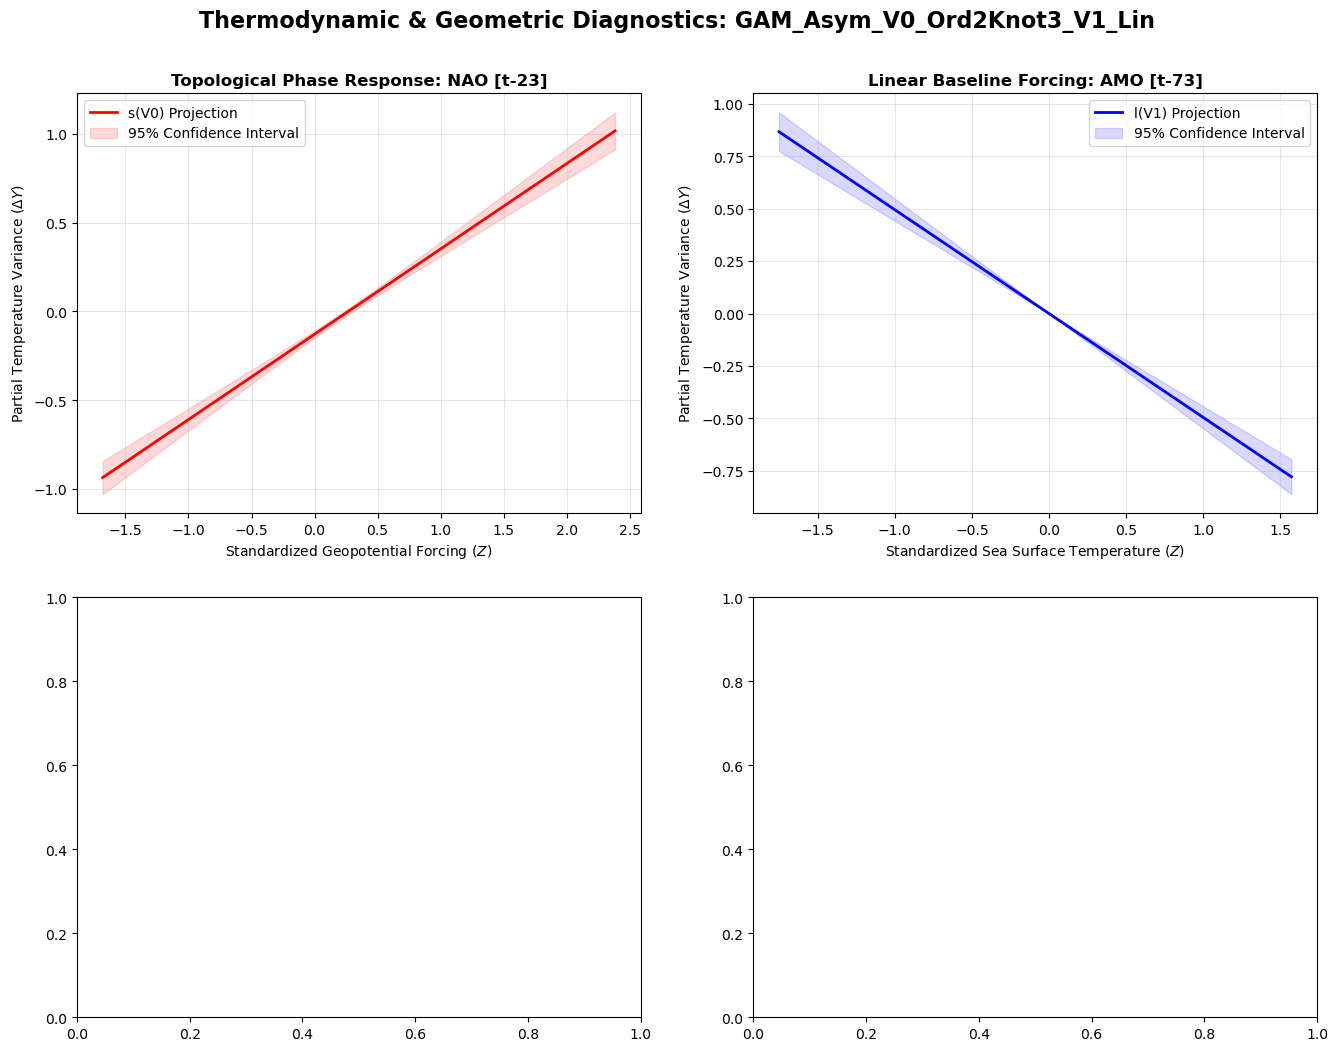

In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, l

def execute_gam_diagnostic_matrix(X_train, y_train, time_index, feature_names):
    """
    Computes and plots the complete topological diagnostic matrix for the 
    GAM_Asym_V0_Ord2Knot3_V1_Lin architecture.
    
    Parameters:
    X_train (ndarray): The N x 2 feature tensor (V0: Atmosphere lag 23, V1: Ocean lag 73).
    y_train (ndarray): The 1D target array (Temperature Cycle).
    time_index (ndarray/Series): Chronological coordinates for the time-series plot.
    feature_names (list): Strict string labels for the axes, e.g., ['Atmospheric Dipole (t-23)', 'AMO (t-73)'].
    """
    # 1. Instantiate and strictly fit the optimal mathematical architecture
    # V0: Quadratic spline (order=2) limited to 3 knots.
    # V1: Pure linear scalar projection.
    optimal_gam = LinearGAM(s(0, spline_order=1, n_splines=2) + l(1))
    optimal_gam.fit(X_train, y_train)
    
    # 2. Extract out-of-fold/fitted phase predictions and exact residual matrix
    y_pred = optimal_gam.predict(X_train)
    residuals = y_train - y_pred
    
    # 3. Initialize the 2x2 diagnostic spatial grid
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Thermodynamic & Geometric Diagnostics: GAM_Asym_V0_Ord2Knot3_V1_Lin', 
                 fontsize=16, fontweight='bold', y=0.95)
    
    # =========================================================================
    # QUADRANT 1: Partial Dependence Plot (V0 - The Non-Linear Atmosphere)
    # =========================================================================
    ax1 = axes[0, 0]
    XX_v0 = optimal_gam.generate_X_grid(term=0)
    pdp_v0, confidence_v0 = optimal_gam.partial_dependence(term=0, X=XX_v0, width=0.95)
    
    ax1.plot(XX_v0[:, 0], pdp_v0, color='red', linewidth=2, label='s(V0) Projection')
    ax1.fill_between(XX_v0[:, 0], confidence_v0[:, 0], confidence_v0[:, 1], color='red', alpha=0.15, label='95% Confidence Interval')
    ax1.set_title(f'Topological Phase Response: {feature_names[0]}', fontweight='bold')
    ax1.set_xlabel('Standardized Geopotential Forcing ($Z$)')
    ax1.set_ylabel('Partial Temperature Variance ($\Delta Y$)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # =========================================================================
    # QUADRANT 2: Partial Dependence Plot (V1 - The Linear Ocean)
    # =========================================================================
    ax2 = axes[0, 1]
    XX_v1 = optimal_gam.generate_X_grid(term=1)
    pdp_v1, confidence_v1 = optimal_gam.partial_dependence(term=1, X=XX_v1, width=0.95)
    
    ax2.plot(XX_v1[:, 1], pdp_v1, color='blue', linewidth=2, label='l(V1) Projection')
    ax2.fill_between(XX_v1[:, 1], confidence_v1[:, 0], confidence_v1[:, 1], color='blue', alpha=0.15, label='95% Confidence Interval')
    ax2.set_title(f'Linear Baseline Forcing: {feature_names[1]}', fontweight='bold')
    ax2.set_xlabel('Standardized Sea Surface Temperature ($Z$)')
    ax2.set_ylabel('Partial Temperature Variance ($\Delta Y$)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # =========================================================================
    # QUADRANT 3: Chronological Phase Trajectory (True vs. Predicted)
    # =========================================================================
    ax3 = axes[1, 0]
    ax3.plot(time_index, y_train, color='black', linewidth=1.5, label='True Target Matrix ($Y$)')
    ax3.plot(time_index, y_pred, color='green', linewidth=1.5, linestyle='--', label='GAM Projection ($\hat{Y}$)')
    ax3.set_title('Multidecadal Phase Alignment (Target vs Computed)', fontweight='bold')
    ax3.set_xlabel('Chronological Index')
    ax3.set_ylabel('Standardized Amplitude')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    # =========================================================================
    # QUADRANT 4: Residual Homoscedasticity Matrix
    # =========================================================================
    ax4 = axes[1, 1]
    ax4.scatter(y_pred, residuals, color='purple', alpha=0.5, marker='o', edgecolors='k', s=30)
    ax4.axhline(0, color='black', linestyle='--', linewidth=1.5)
    
    # Calculate symmetry limit for strictly scaled axes
    max_resid = np.max(np.abs(residuals)) * 1.1
    ax4.set_ylim(-max_resid, max_resid)
    
    ax4.set_title('Residual Geometric Distribution ($\epsilon = Y - \hat{Y}$)', fontweight='bold')
    ax4.set_xlabel('Computed Projection ($\hat{Y}$)')
    ax4.set_ylabel('Absolute Phase Error ($\epsilon$)')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# =========================================================================
# TENSOR EXECUTION 
# =========================================================================
# Assume X_train_tensor is your strictly preprocessed N x 2 numpy array
# Assume y_train_array is your target multidecadal target cycle
# Assume time_coordinates is your timestamp array

execute_gam_diagnostic_matrix(
     X_train=X_matrix, 
     y_train=y_base, 
     time_index= np.arange(905)[73:], 
     feature_names=['NAO [t-23]', 'AMO [t-73]']
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import coherence
from pygam import LinearGAM, s, l

def extract_residual_coherence_matrix(X_train, y_train, candidate_imf_dict, fs=1.0):
    """
    Extracts the deterministic residual loop from the optimal GAM architecture 
    and computes the Magnitude-Squared Coherence against candidate physical vectors.
    
    Parameters:
    X_train (ndarray): The N x 2 optimal feature tensor (NAO_Lag23, AMO_Lag73).
    y_train (ndarray): The 1D target array (Temperature Cycle).
    candidate_imf_dict (dict): Dictionary mapping string names to their respective 
                               1D numpy arrays (e.g., {'IPO': ipo_imf, 'SPG': spg_imf}).
    fs (float): Sampling frequency (1.0 for monthly data).
    """
    
    # =========================================================================
    # 1. EXACT RESIDUAL EXTRACTION
    # =========================================================================
    # Fit the mathematically optimal architecture
    print("Fitting Optimal Tensor: GAM_Asym_V0_Ord2Knot3_V1_Lin...")
    optimal_gam = LinearGAM(s(0, spline_order=2, n_splines=3) + l(1))
    optimal_gam.fit(X_train, y_train)
    
    # Extract the isolated error vector (epsilon)
    y_pred = optimal_gam.predict(X_train)
    epsilon_vector = y_train - y_pred
    
    # =========================================================================
    # 2. CROSS-SPECTRAL COHERENCE DIAGNOSTIC
    # =========================================================================
    num_candidates = len(candidate_imf_dict)
    fig, axes = plt.subplots(num_candidates, 1, figsize=(12, 3 * num_candidates), sharex=True)
    
    # Ensure axes is iterable even if there's only one candidate
    if num_candidates == 1:
        axes = [axes]
        
    fig.suptitle('Magnitude-Squared Coherence: Residuals ($\epsilon$) vs Candidate Forcing', 
                 fontsize=14, fontweight='bold', y=0.98)
    
    # Define the maximum spectral resolution window
    nperseg_window = len(epsilon_vector) // 2
    
    for i, (name, candidate_array) in enumerate(candidate_imf_dict.items()):
        ax = axes[i]
        
        # Verify strict geometric alignment
        assert len(candidate_array) == len(epsilon_vector), f"Dimensionality mismatch on vector: {name}"
        
        # Compute Welch's Coherence 
        freqs, coh = coherence(epsilon_vector, candidate_array, fs=fs, nperseg=nperseg_window)
        
        # Isolate valid frequencies to prevent zero-division when converting to period
        valid_idx = freqs > 0
        periods = 1 / freqs[valid_idx]
        coh_valid = coh[valid_idx]
        
        # Plotting the mathematical trace
        ax.semilogx(periods, coh_valid, color='black', linewidth=2)
        ax.fill_between(periods, 0, coh_valid, color='blue', alpha=0.1)
        ax.axhline(y=0.60, color='red', linestyle='--', linewidth=1.5, label='Significance Threshold ($C_{xy} = 0.60$)')
        
        ax.set_title(f"Target: {name} (Orthogonal Matrix)", fontweight='bold')
        ax.set_ylabel('Coherence ($C_{xy}$)')
        ax.set_ylim(0, 1.05)
        
        # Identify the peak coherence in the multidecadal band (>60 months)
        multidecadal_mask = periods > 60
        if np.any(multidecadal_mask):
            peak_coh = np.max(coh_valid[multidecadal_mask])
            peak_period = periods[multidecadal_mask][np.argmax(coh_valid[multidecadal_mask])]
            ax.plot(peak_period, peak_coh, marker='o', markersize=8, color='red')
            ax.annotate(f'Peak: {peak_coh:.2f} @ {peak_period:.0f}m', 
                        xy=(peak_period, peak_coh), xytext=(10, 10), 
                        textcoords='offset points', color='red', fontweight='bold')
        
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3, which='both')
    
    axes[-1].set_xlabel('Cycle Period (Months)')
    
    # Invert X-axis so low-frequency (multidecadal) cycles are on the right
    plt.xlim(max(periods), min(periods))
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# =========================================================================
# EXECUTION BATCH PREPARATION
# =========================================================================
# Ensure all candidate IMF arrays are strictly shifted and truncated to 
# identically match the chronological indices of your target temperature wave.

# execution_candidates = {
#     'IPO_Phase': ipo_imf_array_lagged,
#     'SPG_Index': spg_imf_array_lagged,
#     'AMM_Dipole': amm_imf_array_lagged,
#     'SAOD_Volcanic': saod_imf_array_lagged
# }

# extract_residual_coherence_matrix(
#     X_train=X_train_tensor, 
#     y_train=y_train_array, 
#     candidate_imf_dict=execution_candidates
# )

<>:26: SyntaxWarning: invalid escape sequence '\D'
<>:26: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_365596/3942664835.py:26: SyntaxWarning: invalid escape sequence '\D'
  ax.set_zlabel('French Temp Cycle ($\Delta T$)')


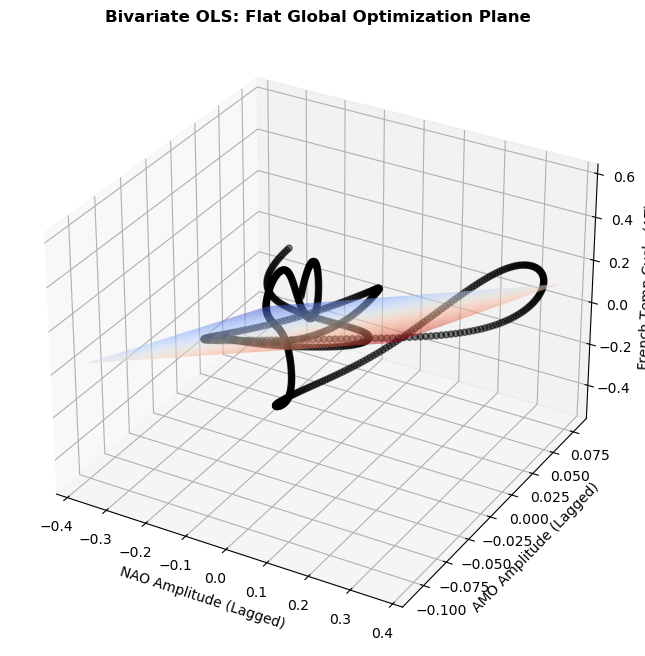

In [ ]:
# Extract the exact coefficients
beta_0 = ols_model.params['const']
beta_1 = ols_model.params['NAO_Lagged']
beta_2 = ols_model.params['AMO_Lagged']

# Construct the mathematical meshgrid
x_surf, y_surf = np.meshgrid(
    np.linspace(X_df['NAO_Lagged'].min(), X_df['NAO_Lagged'].max(), 50),
    np.linspace(X_df['AMO_Lagged'].min(), X_df['AMO_Lagged'].max(), 50)
)
z_surf = beta_0 + (beta_1 * x_surf) + (beta_2 * y_surf)

# Render the 3D topology
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot true coordinates
ax.scatter(X_df['NAO_Lagged'], X_df['AMO_Lagged'], y_series, 
           c='black', marker='o', alpha=0.5, label='True Temperature Anomalies')

# Plot the linear tensor surface
ax.plot_surface(x_surf, y_surf, z_surf, cmap='coolwarm', alpha=0.6, edgecolor='none')

ax.set_xlabel('NAO Amplitude (Lagged)')
ax.set_ylabel('AMO Amplitude (Lagged)')
ax.set_zlabel('French Temp Cycle ($\Delta T$)')
ax.set_title('Bivariate OLS: Flat Global Optimization Plane', fontweight='bold')
plt.show()

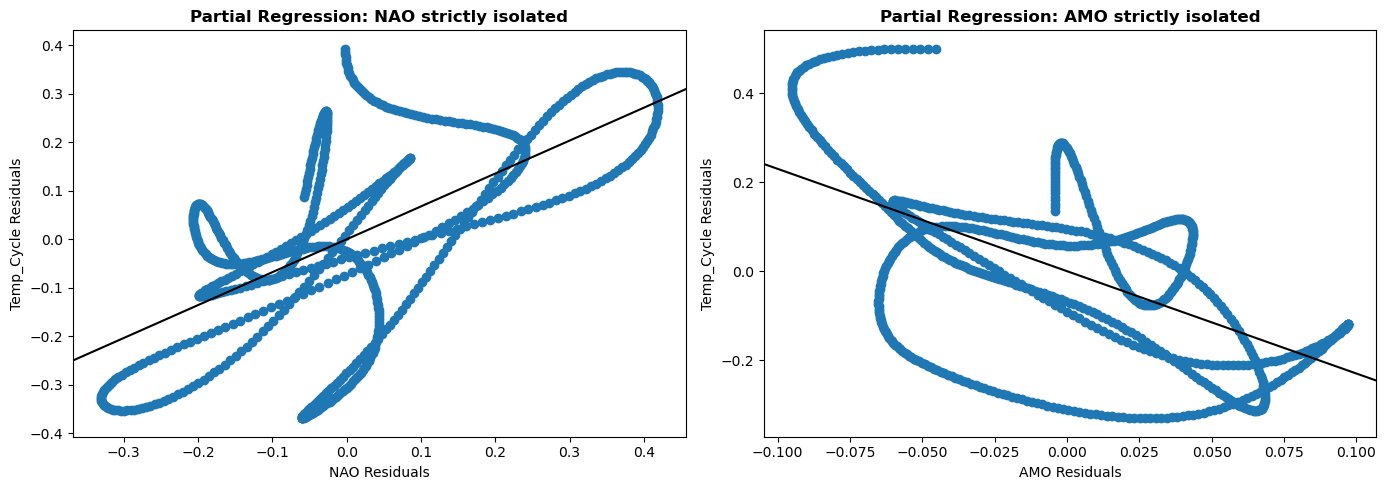

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Partial regression for NAO
sm.graphics.plot_partregress(
    endog='Temp_Cycle', 
    exog_i='NAO_Lagged', 
    exog_others=['AMO_Lagged'], 
    data=pd.concat([y_series, X_df], axis=1), 
    obs_labels=False, 
    ax=ax1
)
ax1.set_title('Partial Regression: NAO strictly isolated', fontweight='bold')
ax1.set_xlabel('NAO Residuals')
ax1.set_ylabel('Temp_Cycle Residuals')

# Partial regression for AMO
sm.graphics.plot_partregress(
    endog='Temp_Cycle', 
    exog_i='AMO_Lagged', 
    exog_others=['NAO_Lagged'], 
    data=pd.concat([y_series, X_df], axis=1), 
    obs_labels=False, 
    ax=ax2
)
ax2.set_title('Partial Regression: AMO strictly isolated', fontweight='bold')
ax2.set_xlabel('AMO Residuals')
ax2.set_ylabel('Temp_Cycle Residuals')

plt.tight_layout()
plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_365596/372941131.py:10: SyntaxWarning: invalid escape sequence '\e'
  axes[0].set_ylabel('Residual Error ($\epsilon$)')
/tmp/ipykernel_365596/372941131.py:15: SyntaxWarning: invalid escape sequence '\e'
  axes[1].set_xlabel('Residual Error ($\epsilon$)')


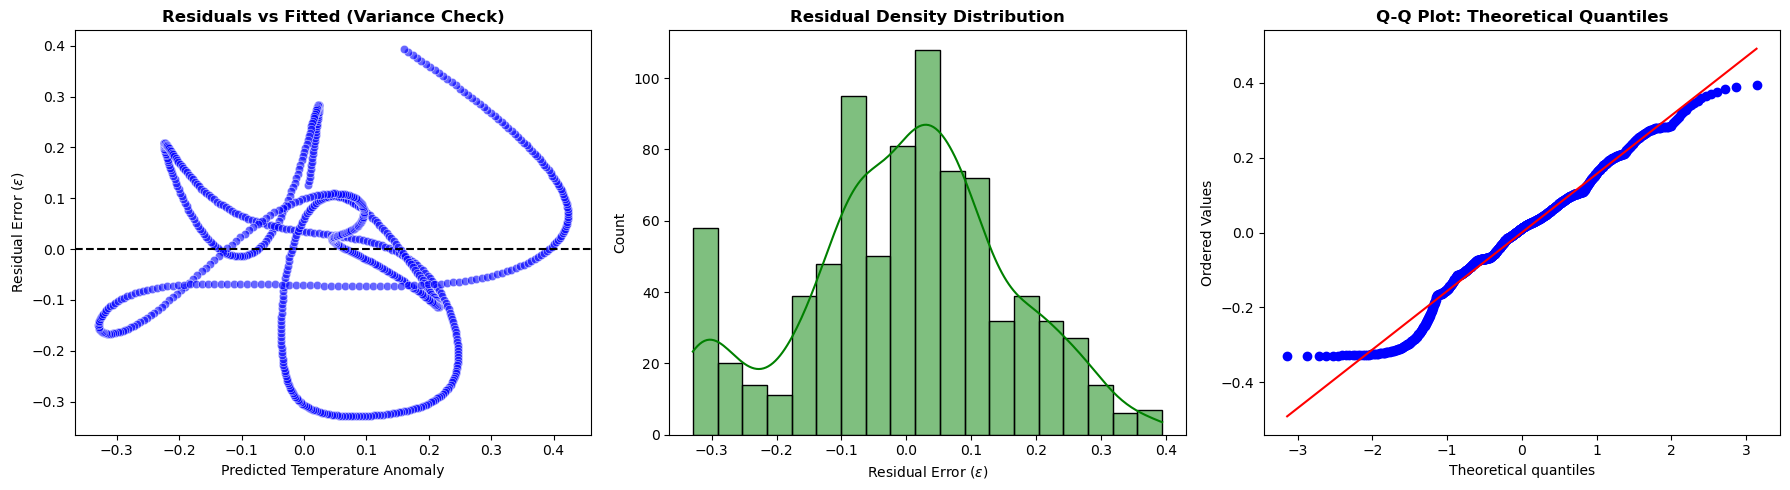

In [ ]:
residuals = ols_model.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residuals vs Fitted (Test for Homoscedasticity and Non-linearity)
sns.scatterplot(x=y_pred, y=residuals, ax=axes[0], color='blue', alpha=0.6)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Residuals vs Fitted (Variance Check)', fontweight='bold')
axes[0].set_xlabel('Predicted Temperature Anomaly')
axes[0].set_ylabel('Residual Error ($\epsilon$)')

# 2. Residual Distribution (Test for Normality)
sns.histplot(residuals, kde=True, ax=axes[1], color='green')
axes[1].set_title('Residual Density Distribution', fontweight='bold')
axes[1].set_xlabel('Residual Error ($\epsilon$)')

# 3. Q-Q Plot (Test for Heavy Tails / Outliers)
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot: Theoretical Quantiles', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
df_new = pd.DataFrame(data={"NAO" : nao_shifted, "AMO" : amo_shifted, "trend" : df_gam_filtered['Global_Warming'][max_lag_overall:],'Temp_Cycle' : df_gam_filtered['Temp_Cycle'][max_lag_overall:]})

optimal_formulation = amo_formulation

# Create a factory function for the model
gam_factory = lambda: LinearGAM(optimal_formulation, lam=20.0)

def grid_search_lags_cv(
    df: pd.DataFrame, 
    target_col: str, 
    lag_grid: dict, 
    static_features: list, 
    model_factory: callable, 
    n_splits: int = 5
) -> pd.DataFrame:
    """
    Evaluates different lag combinations for time-series features using K-Fold CV.
    
    Parameters:
    df (pd.DataFrame): The dataset containing all features and the target.
    target_col (str): The name of the target variable.
    lag_grid (dict): Dictionary mapping feature names to a list of integer lags to test.
                     e.g., {'NAO': [0, 60], 'EA': [160]}
    static_features (list): Features that should NOT be lagged (e.g., background trend).
    model_factory (callable): A function/lambda that returns a fresh, un-fitted model instance.
    n_splits (int): Number of K-Fold splits.
    
    Returns:
    pd.DataFrame: Ranked results sorted by Mean Out-of-Fold RMSE.
    """
    
    # 1. Determine the universal truncation limit to keep sample size constant
    max_lag_overall = max([max(lags) for lags in lag_grid.values()])
    print(f"Universal max lag limit set to: {max_lag_overall} steps.")
    
    # 2. Extract stationary base targets and static features
    y_base = df[target_col].values[max_lag_overall:]
    static_matrix = df[static_features].values[max_lag_overall:]
    
    # 3. Generate all permutations from the lag grid
    feature_names = list(lag_grid.keys())
    lag_combinations = list(itertools.product(*lag_grid.values()))
    
    # Initialize Time-Series safe K-Fold (no shuffling)
    kf = TimeSeriesSplit(n_splits=n_splits, test_size=len(y_base)//10)
    results = []
    
    total_tests = len(lag_combinations)
    print(f"Executing K-Fold CV across {total_tests} configurations...\n")
    
    # 4. Exhaustive Grid Search
    for idx, current_lags in enumerate(lag_combinations, 1):
        
        # Build the dynamic shifted feature matrix for this combination
        shifted_features = []
        for feature, lag in zip(feature_names, current_lags):
            shifted_col = df[feature].shift(lag).values[max_lag_overall:]
            shifted_features.append(shifted_col)
            
        # Combine shifted features with static features
        X_matrix = np.column_stack([*shifted_features, static_matrix])
        
        # K-Fold CV Loop
        fold_rmse = []
        fold_r2 = []
        
        for train_idx, test_idx in kf.split(X_matrix):
            X_train, X_test = X_matrix[train_idx], X_matrix[test_idx]
            y_train, y_test = y_base[train_idx], y_base[test_idx]
            
            # Instantiate a fresh model to prevent state leakage
            model = model_factory()
            
            try:
                # Fit and predict
                model.fit(X_train, y_train)
                preds = model.predict(X_test)
                
                # Calculate Out-of-Fold metrics
                fold_rmse.append(root_mean_squared_error(y_test, preds))
                fold_r2.append(r2_score(y_test, preds))
                
            except Exception as e:
                print(f"Fold failed for lags {current_lags}: {e}")
                fold_rmse.append(np.nan)
                fold_r2.append(np.nan)
        
        # Aggregate Results
        res_dict = {f"{feat}_Lag": lag for feat, lag in zip(feature_names, current_lags)}
        res_dict.update({
            "Mean_CV_RMSE": np.nanmean(fold_rmse),
            "Std_CV_RMSE": np.nanstd(fold_rmse),
            "Mean_CV_R2": np.nanmean(fold_r2)
        })
        results.append(res_dict)
        
        if idx % 20 == 0 or idx == total_tests:
            print(f"[{idx}/{total_tests}] Processed.")
            
    # 5. Format and Rank Output
    df_results = pd.DataFrame(results)
    df_ranked = df_results.sort_values(by="Mean_CV_RMSE", ascending=True).reset_index(drop=True)
    
    return df_ranked

ranked_results = grid_search_lags_cv(
    df=df_new,
    target_col='Temp_Cycle',
    lag_grid={"NAO": [0]},
    static_features=["AMO", 'trend'],
    model_factory=gam_factory,
    n_splits=5
)

print(ranked_results.head(10).to_string(index=False))

Universal max lag limit set to: 0 steps.
Executing K-Fold CV across 1 configurations...

[1/1] Processed.
 NAO_Lag  Mean_CV_RMSE  Std_CV_RMSE  Mean_CV_R2
       0      0.312798     0.095687   -1.182788


https://iopscience.iop.org/article/10.1088/1748-9326/aba925


Generating the 3D Bilinear Interaction Surface...


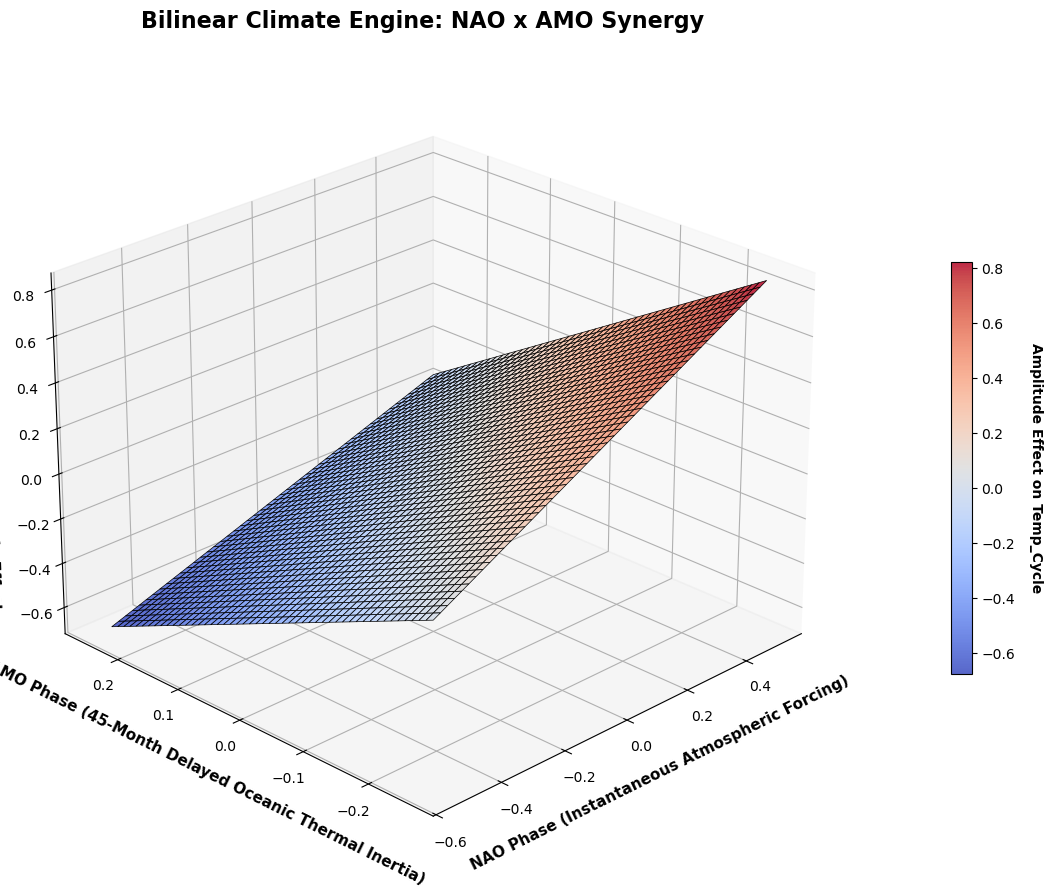

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from pygam import LinearGAM, te

# ==============================================================================
# 1. FIT THE OPTIMAL BILINEAR TENSOR MODEL
# ==============================================================================
# Assuming X_matrix_core is: Col 0 -> NAO (Lag 0), Col 1 -> AMO (Lag 45)
# We enforce spline_order=1 and n_splines=2 to create a strict bilinear surface
optimal_tensor_formulation = te(0, 1, spline_order=1, n_splines=[2, 2])

# Fit with your established penalization
final_model = LinearGAM(optimal_tensor_formulation, lam=50.0)
final_model.fit(X_matrix_core, y_base)

# ==============================================================================
# 2. FINAL VISUALIZATION: THE 3D CLIMATE INTERACTION ENGINE
# ==============================================================================
print("\nGenerating the 3D Bilinear Interaction Surface...")

# A. Generate a dense 50x50 coordinate grid across the physical ranges of NAO and AMO
XX_tensor = final_model.generate_X_grid(term=0, meshgrid=True, n=50)

# B. Extract the predicted temperature anomaly (Z-axis) across this grid
# FIX: Remove the tuple unpacking (`, _`). It returns a single 2D array.
Z_surface = final_model.partial_dependence(term=0, X=XX_tensor, meshgrid=True)

# C. Isolate the spatial axes directly from the tensor list
# FIX: Extract the 2D meshgrids directly
X_nao = XX_tensor[0]  # NAO Phase physical values
Y_amo = XX_tensor[1]  # AMO Phase physical values

# D. Construct the 3D Projection
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(X_nao, Y_amo, Z_surface, 
                       cmap='coolwarm', 
                       edgecolor='black', 
                       linewidth=0.5, 
                       alpha=0.85)

# Formatting and Physical Labels
ax.set_title('Bilinear Climate Engine: NAO x AMO Synergy', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('\nNAO Phase (Instantaneous Atmospheric Forcing)', fontsize=11, fontweight='bold')
ax.set_ylabel('\nAMO Phase (45-Month Delayed Oceanic Thermal Inertia)', fontsize=11, fontweight='bold')
ax.set_zlabel('\nTarget Temperature Anomaly Effect', fontsize=11, fontweight='bold')

# Quantifiable Color Bar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('Amplitude Effect on Temp_Cycle', rotation=270, labelpad=20, fontweight='bold')

# Optimal viewing angle to expose the structural "twist" of the interaction
ax.view_init(elev=25, azim=225)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
baseline_std = np.std(df_gam_filtered['Temp_Cycle'].values[max_lag_overall:])
print(f"Global Target Standard Deviation: {baseline_std:.6f}")

Global Target Standard Deviation: 0.412763


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, root_mean_squared_error
import numpy as np

# 1. Initialize TimeSeriesSplit (Matching your previous setup)
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# 2. Initialize Ridge Regression (Alpha is the L2 penalty, similar to GAM's lam)
ridge_model = Ridge(alpha=100.0)

fold_rmse = []
fold_r2 = []

print("-" * 50)
print("PURE LINEAR RIDGE REGRESSION CV (THE FINAL BASELINE)")
print("-" * 50)

for train_idx, test_idx in tscv.split(X_matrix_core):
    X_train, X_test = X_matrix_core[train_idx], X_matrix_core[test_idx]
    y_train, y_test = y_base[train_idx], y_base[test_idx]
    
    # Fit and Predict
    ridge_model.fit(X_train, y_train)
    preds = ridge_model.predict(X_test)
    
    # Calculate Metrics
    rmse = root_mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    fold_rmse.append(rmse)
    fold_r2.append(r2)
    
    print(f"Fold R2: {r2:8.4f} | RMSE: {rmse:8.4f}")

print("-" * 50)
print(f"Mean CV RMSE: {np.mean(fold_rmse):.4f}")
print(f"Mean CV R2:   {np.mean(fold_r2):.4f}")

--------------------------------------------------
PURE LINEAR RIDGE REGRESSION CV (THE FINAL BASELINE)
--------------------------------------------------
Fold R2:  -0.0557 | RMSE:   0.2641
Fold R2:  -0.2706 | RMSE:   0.5198
Fold R2:  -0.5566 | RMSE:   0.3111
Fold R2:  -0.2784 | RMSE:   0.4028
Fold R2:  -3.7273 | RMSE:   0.4708
--------------------------------------------------
Mean CV RMSE: 0.3937
Mean CV R2:   -0.9777


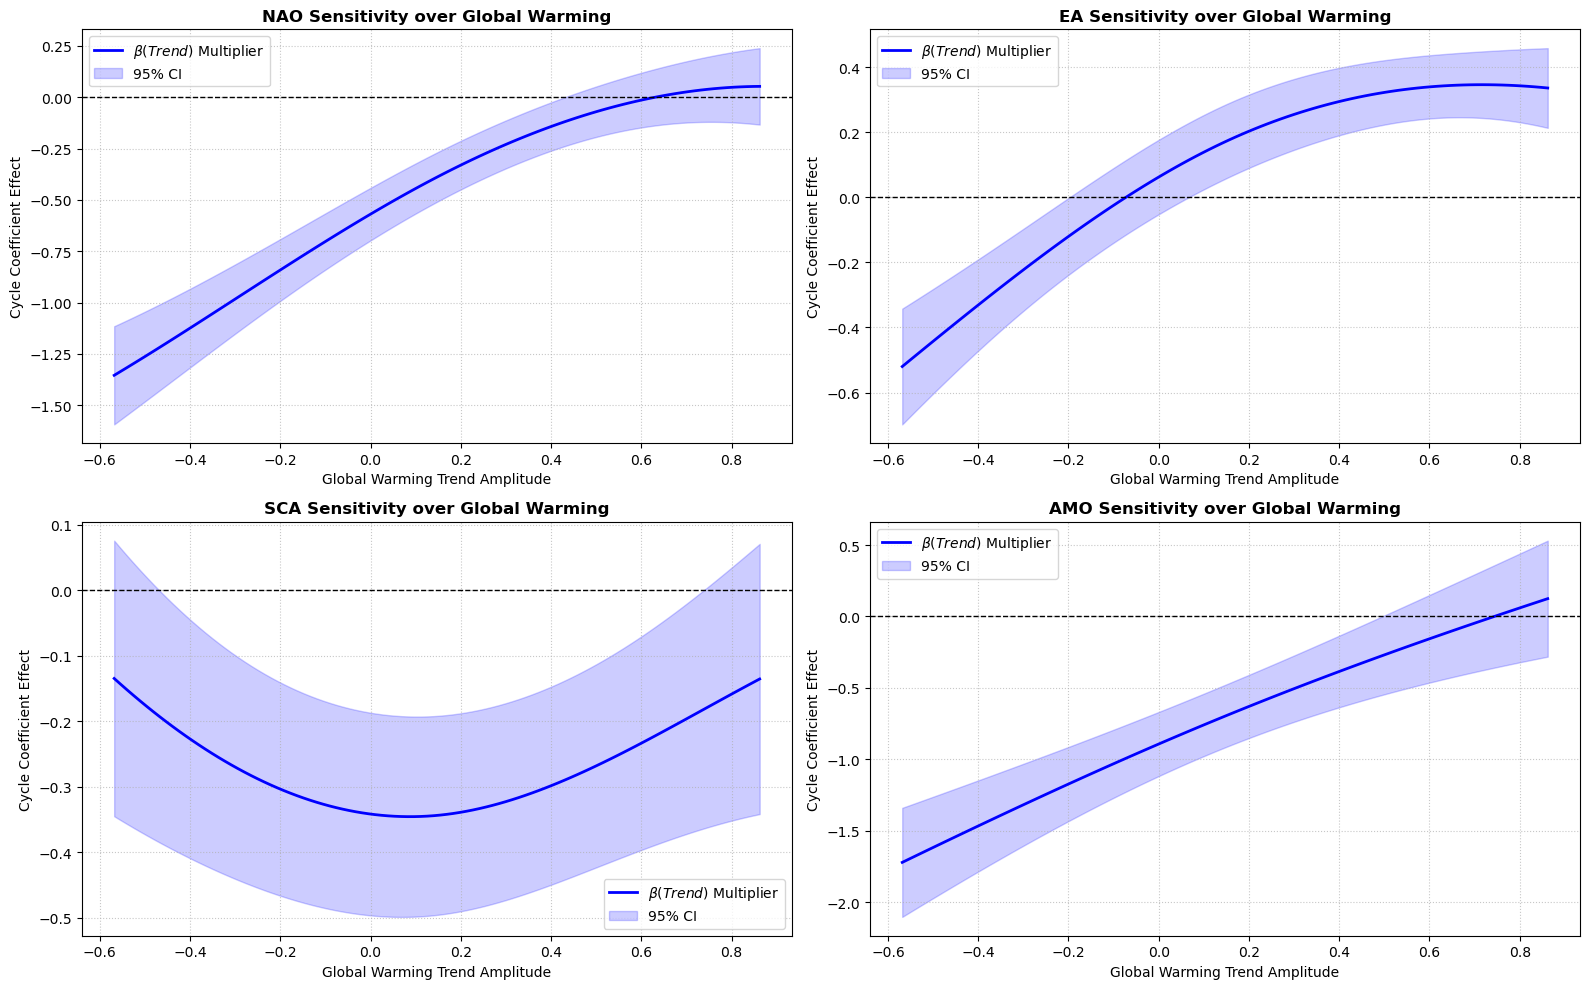

In [ ]:
import matplotlib.pyplot as plt

# Define the exact term indices based on the architecture:
# l(0) [0], l(1) [1], l(2) [2], l(3) [3], s(4) [4]
# s(4, by=0) [5], s(4, by=1) [6], s(4, by=2) [7], s(4, by=3) [8]

interaction_terms = {
    'NAO Sensitivity': 5,
    'EA Sensitivity': 6,
    'SCA Sensitivity': 7,
    'AMO Sensitivity': 8
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (title, term_idx) in enumerate(interaction_terms.items()):
    ax = axes[idx]
    
    # Generate a dense grid strictly for the Trend variable (feature index 4)
    XX = best_model.generate_X_grid(term=term_idx)
    
    # Extract the partial dependence (the beta multiplier) and confidence intervals
    pdep, confi = best_model.partial_dependence(term=term_idx, X=XX, width=0.95)
    
    # XX[:, 4] isolates the Global Warming Trend values generated for the grid
    trend_grid = XX[:, 4]
    
    # Plotting
    ax.plot(trend_grid, pdep, color='blue', linewidth=2, label=r'$\beta(Trend)$ Multiplier')
    ax.fill_between(trend_grid, confi[:, 0], confi[:, 1], color='blue', alpha=0.2, label='95% CI')
    
    # Add a horizontal zero-line to identify phase inversions
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    
    ax.set_title(f'{title} over Global Warming', fontsize=12, fontweight='bold')
    ax.set_xlabel('Global Warming Trend Amplitude', fontsize=10)
    ax.set_ylabel(f'Cycle Coefficient Effect', fontsize=10)
    ax.legend(loc='best')
    ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from typing import List, Dict, Tuple

def engineer_time_series_features(
    df: pd.DataFrame, 
    lag_config: Dict[str, List[int]], 
    interaction_pairs: List[Tuple[str, str, str]]
) -> pd.DataFrame:
    """
    Expands a dataframe with specified lags and cross-feature interactions.
    
    Parameters:
    df (pd.DataFrame): Time-indexed dataframe.
    lag_config (Dict[str, List[int]]): Mapping of column names to lists of integer lags.
                                       e.g., {'price': [1, 2, 3], 'volume': [1, 5]}
    interaction_pairs (List[Tuple[str, str, str]]): List of tuples defining the interactions
                                                    (col_A, col_B, operation).
                                                    Valid operations: 'mul', 'add', 'div'.
    
    Returns:
    pd.DataFrame: DataFrame containing the original and newly engineered features.
    """
    df_expanded = df.copy()
    
    # 1. Generate Multiple Lags
    for feature, lags in lag_config.items():
        if feature not in df.columns:
            raise KeyError(f"Feature '{feature}' not found in DataFrame.")
            
        for lag in lags:
            lagged_col_name = f"{feature}_lag_{lag}"
            df_expanded[lagged_col_name] = df_expanded[feature].shift(lag)
            
    # 2. Generate Non-Independent Relations
    for col1, col2, op in interaction_pairs:
        if col1 not in df_expanded.columns or col2 not in df_expanded.columns:
            raise KeyError(f"Interaction features '{col1}' or '{col2}' not found.")
            
        interaction_name = f"{col1}_{op}_{col2}"
        
        if op == 'mul':
            df_expanded[interaction_name] = df_expanded[col1] * df_expanded[col2]
        elif op == 'add':
            df_expanded[interaction_name] = df_expanded[col1] + df_expanded[col2]
        elif op == 'div':
            # Replaces 0 with NaN to prevent ZeroDivisionError propagation into inf
            df_expanded[interaction_name] = df_expanded[col1] / df_expanded[col2].replace(0, pd.NA)
        else:
            raise ValueError(f"Unsupported operation: '{op}'")
            
    return df_expanded

# Example execution parameters:
# lag_config = {
#     'feature_A': [1, 2, 4],
#     'feature_B': [1, 12]
# }
# interaction_pairs = [
#     ('feature_A_lag_1', 'feature_B_lag_1', 'mul'), 
#     ('feature_A_lag_4', 'feature_A', 'div')       
# ]

In [ ]:
import pandas as pd

# ==============================================================================
# 1. APPLYING THE TEMPORAL SHIFTS (LAGS)
# ==============================================================================
# We create a copy to avoid altering the original extracted cycles
df_predictive = df_gam_filtered.copy()

# The Atmospheric predictors operate concurrently (Lag 0), so we leave them alone.
# df_predictive['NAO_Cycle'] = df_gam_filtered['NAO_Cycle']
# df_predictive['EA_Cycle']  = df_gam_filtered['EA_Cycle']
# df_predictive['SCA_Cycle'] = df_gam_filtered['SCA_Cycle']

# The Oceanic predictor must be shifted FORWARD to align its past with the present target.
# A shift of +160 means the AMO value from row 0 is pushed down to row 160.


# ==============================================================================
# 2. MATRIX ALIGNMENT
# ==============================================================================
# Shifting arrays creates missing data (NaNs) at the beginning of the dataset.
# The first 160 months of the target variable no longer have a corresponding AMO history.
# We must drop these rows to ensure the GAM receives a complete, dense matrix.
df_predictive = df_predictive.dropna()

# ==============================================================================
# 3. DEFINING THE FINAL FEATURE TENSOR
# ==============================================================================
# Re-extract the aligned arrays
y_final = df_predictive['Temp_Cycle'].values

# The feature matrix X is now perfectly phase-aligned based on physical causality
X_final = df_predictive[['NAO_Cycle', 'EA_Cycle', 'SCA_Cycle', 'AMO_Cycle', 'Global_Warming']].values

In [ ]:
import pandas as pd
from pygam import LinearGAM, l, s, te

# ==============================================================================
# 1. MATRIX DEFINITION (CONCURRENT STRICT)
# ==============================================================================
# IMPORTANT: Ensure X_final is an np.column_stack of all 5 arrays
X_concurrent = X_final
y_concurrent = y_final

# Index 0: NAO_Cycle (Concurrent)
# Index 1: EA_Cycle (Concurrent)
# Index 2: SCA_Cycle (Concurrent)
# Index 3: AMO_Cycle (Lagged or Concurrent based on your X_final construction)
# Index 4: Background_Trend (CEEMDAN Residual)

# ==============================================================================
# 2. ARCHITECTURE DEFINITIONS
# ==============================================================================
architectures = {
    # Baselines + Background Trend
    "1. Strictly Linear (Additive)": l(0) + l(1) + l(2) + l(3) + s(4, spline_order=2),
    "2. Independent Splines (Non-Linear Additive)": s(0, spline_order=2) + s(1, spline_order=2) + s(2, spline_order=2) + s(3, spline_order=2) + s(4, spline_order=2),
    
    # 2-Way Atmospheric Interactions + Independent Ocean + Background Trend
    "3. Interaction: [NAO x EA] + Splines(SCA, AMO)": te(0, 1, n_splines=(2, 2), spline_order=1) + s(2, spline_order=2) + s(3, spline_order=2) + s(4, spline_order=2),
    "4. Interaction: [NAO x SCA] + Splines(EA, AMO)": te(0, 2, n_splines=(2, 2), spline_order=1) + s(1, spline_order=2) + s(3, spline_order=2) + s(4, spline_order=2),
    "5. Interaction: [EA x SCA] + Splines(NAO, AMO)": te(1, 2, n_splines=(2, 2), spline_order=1) + s(0, spline_order=2) + s(3, spline_order=2) + s(4, spline_order=2),
    
    # 3-Way Atmospheric Tensors + Independent Ocean + Background Trend
    "6. 3-Way Atmospheric Tensor + Linear AMO": te(0, 1, 2, n_splines=(2, 2, 2), spline_order=1) + l(3) + s(4, spline_order=2),
    "7. 3-Way Atmospheric Tensor + Spline AMO": te(0, 1, 2, n_splines=(2, 2, 2), spline_order=1) + s(3, spline_order=2) + s(4, spline_order=2),
    
    # Fully Coupled 4-Dimensional Interaction + Background Trend
    "8. Full 4-Way Tensor (Atmosphere x Ocean)": te(0, 1, 2, 3, n_splines=(2, 2, 2, 2), spline_order=1) + s(4, spline_order=2)
    
}
architectures2 = {
    # -------------------------------------------------------------------------
    # CONTROL: The baseline we established (Trend is purely an additive intercept)
    "1. CONTROL: 3D Atmosphere + Lagged Ocean + Additive Trend": 
        te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + l(3) + s(4, spline_order=2),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS A: The Trend only modulates the Ocean's heat release. 
    # The Atmosphere distributes it normally.
    "2. Trend x Ocean: [AMO x Trend] + 3D Atmosphere": 
        te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + te(3, 4, n_splines=(4, 4), spline_order=2),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS B: The Trend modulates the Atmosphere INDIVIDUALLY.
    # The pressure networks are independent of each other, but dependent on the warming era.
    "3. Trend x Isolated Atmosphere: [NAO x Trend] + [EA x Trend] + [SCA x Trend]": 
        te(0, 4, n_splines=(3, 3), spline_order=2) + te(1, 4, n_splines=(3, 3), spline_order=2) + te(2, 4, n_splines=(3, 3), spline_order=2) + l(3),

    # -------------------------------------------------------------------------
    # HYPOTHESIS C: The Trend modulates the specific 2-Way atmospheric couplings.
    "4. Trend x 2-Way Atmosphere: [NAO x EA x Trend] + Splines(SCA, AMO)": 
        te(0, 1, 4, n_splines=(2, 2, 2), spline_order=1) + s(2, spline_order=2) + l(3),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS D: The Trend modulates the ENTIRE 3D atmospheric boundary layer.
    # The tri-pole behaves fundamentally differently in a hotter world.
    "5. Trend x 3D Atmosphere: [NAO x EA x SCA x Trend] + Linear Ocean": 
        te(0, 1, 2, 4, n_splines=(2, 2, 2, 2), spline_order=1) + l(3),
        
    # -------------------------------------------------------------------------
    # HYPOTHESIS E: Total System Coupling (The absolute limit of PyGAM math).
    # Everything interacts with everything, shifting dynamically with global warming.
    "6. Fully Coupled 5D System: [Atmosphere x Ocean x Trend]": 
        te(0, 1, 2, 3, 4, n_splines=(2, 2, 2, 2, 2), spline_order=1)
}
# ==============================================================================
# 3. EXECUTION AND DIAGNOSTICS
# ==============================================================================
results = []

print(f"Executing Exhaustive Concurrent GAM Test on {len(X_concurrent)} rows with 5 Dimensions...")

for name, formulation in architectures2.items():
    try:
        model = LinearGAM(formulation)
        model.gridsearch(X_concurrent, y_concurrent, progress=False)
        
        results.append({
            "Architecture": name,
            "AIC": model.statistics_['AIC'],
            "GCV": model.statistics_['GCV'],
            "EDOF": model.statistics_['edof'],
            "Pseudo R-Squared": model.statistics_['pseudo_r2']['explained_deviance']
        })
    except Exception as e:
        results.append({
            "Architecture": name,
            "AIC": float('inf'),
            "GCV": float('inf'),
            "EDOF": 0,
            "Pseudo R-Squared": 0.0
        })
        print(f"Failed on {name}: {e}")

# ==============================================================================
# 4. OUTPUT
# ==============================================================================
df_results = pd.DataFrame(results).sort_values(by="AIC")

print("\n========================================================================================")
print("ARCHITECTURE PERFORMANCE RANKING (ANCHORED TREND)")
print("========================================================================================")
print(df_results.to_string(index=False))

Executing Exhaustive Concurrent GAM Test on 905 rows with 5 Dimensions...

ARCHITECTURE PERFORMANCE RANKING (ANCHORED TREND)
                                                                Architecture          AIC      GCV      EDOF  Pseudo R-Squared
                   1. CONTROL: 3D Atmosphere + Lagged Ocean + Additive Trend -3916.796446 0.000795 32.473415          0.985105
                    6. Fully Coupled 5D System: [Atmosphere x Ocean x Trend] -2011.096087 0.006525 31.999850          0.877537
3. Trend x Isolated Atmosphere: [NAO x Trend] + [EA x Trend] + [SCA x Trend] -1756.819022 0.008532 18.981026          0.833004
                             2. Trend x Ocean: [AMO x Trend] + 3D Atmosphere -1669.260027 0.009474 27.124123          0.819363
           5. Trend x 3D Atmosphere: [NAO x EA x SCA x Trend] + Linear Ocean -1405.021393 0.012562 16.937372          0.752538
         4. Trend x 2-Way Atmosphere: [NAO x EA x Trend] + Splines(SCA, AMO) -1195.462168 0.015962 25.239080     

In [ ]:
import pandas as pd
from pygam import LinearGAM, l, s, te

# ==============================================================================
# 1. MATRIX DEFINITION
# ==============================================================================
# Index 0: NAO_Cycle 
# Index 1: EA_Cycle 
# Index 2: SCA_Cycle 
# Index 3: AMO_Lagged (160 Months)
# Index 4: Background_Trend (CEEMDAN Residual)

X_concurrent = X_final
y_concurrent = y_final

# ==============================================================================
# 2. TREND-DEPENDENT ARCHITECTURE DEFINITIONS
# ==============================================================================
architectures = {
    # -------------------------------------------------------------------------
    # CONTROL: The baseline we established (Trend is purely an additive intercept)
    "1. CONTROL: 3D Atmosphere + Lagged Ocean + Additive Trend": 
        te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + l(3) + s(4, spline_order=2),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS A: The Trend only modulates the Ocean's heat release. 
    # The Atmosphere distributes it normally.
    "2. Trend x Ocean: [AMO x Trend] + 3D Atmosphere": 
        te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + te(3, 4, n_splines=(4, 4), spline_order=2),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS B: The Trend modulates the Atmosphere INDIVIDUALLY.
    # The pressure networks are independent of each other, but dependent on the warming era.
    "3. Trend x Isolated Atmosphere: [NAO x Trend] + [EA x Trend] + [SCA x Trend]": 
        te(0, 4, n_splines=(3, 3), spline_order=2) + te(1, 4, n_splines=(3, 3), spline_order=2) + te(2, 4, n_splines=(3, 3), spline_order=2) + l(3),

    # -------------------------------------------------------------------------
    # HYPOTHESIS C: The Trend modulates the specific 2-Way atmospheric couplings.
    "4. Trend x 2-Way Atmosphere: [NAO x EA x Trend] + Splines(SCA, AMO)": 
        te(0, 1, 4, n_splines=(2, 2, 2), spline_order=1) + s(2, spline_order=2) + l(3),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS D: The Trend modulates the ENTIRE 3D atmospheric boundary layer.
    # The tri-pole behaves fundamentally differently in a hotter world.
    "5. Trend x 3D Atmosphere: [NAO x EA x SCA x Trend] + Linear Ocean": 
        te(0, 1, 2, 4, n_splines=(2, 2, 2, 2), spline_order=1) + l(3),
        
    # -------------------------------------------------------------------------
    # HYPOTHESIS E: Total System Coupling (The absolute limit of PyGAM math).
    # Everything interacts with everything, shifting dynamically with global warming.
    "6. Fully Coupled 5D System: [Atmosphere x Ocean x Trend]": 
        te(0, 1, 2, 3, 4, n_splines=(2, 2, 2, 2, 2), spline_order=1)
}

# ==============================================================================
# 3. EXECUTION AND DIAGNOSTICS (Using 5-Fold Walk-Forward Validation)
# ==============================================================================
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score

tscv = TimeSeriesSplit(n_splits=5)
fold_metrics = []

print(f"Executing Walk-Forward Validation on Trend-Dependent Architectures...")

for name, formulation in architectures.items():
    print(f"Testing: {name}")
    
    for fold, (train_index, test_index) in enumerate(tscv.split(X_concurrent), 1):
        X_train, X_test = X_concurrent[train_index], X_concurrent[test_index]
        y_train, y_test = y_concurrent[train_index], y_concurrent[test_index]

        model = LinearGAM(formulation)
        
        try:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            r2 = r2_score(y_test, y_pred)
            
            fold_metrics.append({
                'Architecture': name,
                'Fold': fold,
                'R2': r2
            })
        except Exception as e:
            fold_metrics.append({
                'Architecture': name,
                'Fold': fold,
                'R2': np.nan
            })

df_folds = pd.DataFrame(fold_metrics)
df_summary = df_folds.groupby('Architecture')['R2'].mean().sort_values(ascending=False).reset_index()

print("\n===========================================================")
print("TREND-DEPENDENT OUT-OF-SAMPLE STABILITY RANKING (5 FOLDS)")
print("===========================================================")
print(df_summary.to_string(index=False))

Executing Walk-Forward Validation on Trend-Dependent Architectures...
Testing: 1. CONTROL: 3D Atmosphere + Lagged Ocean + Additive Trend
Testing: 2. Trend x Ocean: [AMO x Trend] + 3D Atmosphere
Testing: 3. Trend x Isolated Atmosphere: [NAO x Trend] + [EA x Trend] + [SCA x Trend]
Testing: 4. Trend x 2-Way Atmosphere: [NAO x EA x Trend] + Splines(SCA, AMO)
Testing: 5. Trend x 3D Atmosphere: [NAO x EA x SCA x Trend] + Linear Ocean
Testing: 6. Fully Coupled 5D System: [Atmosphere x Ocean x Trend]

TREND-DEPENDENT OUT-OF-SAMPLE STABILITY RANKING (5 FOLDS)
                                                                Architecture           R2
                             2. Trend x Ocean: [AMO x Trend] + 3D Atmosphere   -99.752978
                   1. CONTROL: 3D Atmosphere + Lagged Ocean + Additive Trend  -103.352609
         4. Trend x 2-Way Atmosphere: [NAO x EA x Trend] + Splines(SCA, AMO)  -634.333999
3. Trend x Isolated Atmosphere: [NAO x Trend] + [EA x Trend] + [SCA x Trend]  -681.

In [ ]:
np.mean(df_climate['EA'])

np.float64(-0.1309060773480663)

In [ ]:
import pandas as pd
from pygam import LinearGAM, l, s, te

# ==============================================================================
# 1. MATRIX DEFINITION (CONCURRENT STRICT)
# ==============================================================================
# We use the clean, un-shifted CEEMDAN DataFrame.
# Drop any existing NaNs just to ensure matrix integrity.
df_concurrent = df_gam_filtered.dropna()

# Index 0: NAO_Cycle (Concurrent)
# Index 1: EA_Cycle (Concurrent)
# Index 2: SCA_Cycle (Concurrent)
# Index 3: AMO_Cycle (Concurrent)
X_concurrent = X_final
y_concurrent = y_final

# ==============================================================================
# 2. ARCHITECTURE DEFINITIONS
# ==============================================================================
# We constrain the tensors (n_splines) to prevent the EDOF from exploding past 30-40,
# ensuring we test general physics rather than overfitting the exact time series.

architectures = {
    # Baselines
    "1. Strictly Linear (Additive)": l(0) + l(1) + l(2) + l(3),
    "2. Independent Splines (Non-Linear Additive)": s(0, spline_order=2) + s(1, spline_order=2) + s(2, spline_order=2) + s(3, spline_order=2),
    
    # 2-Way Atmospheric Interactions + Independent Ocean
    "3. Interaction: [NAO x EA] + Splines(SCA, AMO)": te(0, 1, n_splines=(2, 2), spline_order=1) + s(2, spline_order=2) + s(3, spline_order=2),
    "4. Interaction: [NAO x SCA] + Splines(EA, AMO)": te(0, 2, n_splines=(2, 2), spline_order=1) + s(1, spline_order=2) + s(3, spline_order=2),
    "5. Interaction: [EA x SCA] + Splines(NAO, AMO)": te(1, 2, n_splines=(2, 2), spline_order=1) + s(0, spline_order=2) + s(3, spline_order=2),
    
    # 3-Way Atmospheric Tensors + Independent Ocean
    "6. 3-Way Atmospheric Tensor + Linear AMO": te(0, 1, 2, n_splines=(2, 2, 2), spline_order=1) + l(3),
    "7. 3-Way Atmospheric Tensor + Spline AMO": te(0, 1, 2, n_splines=(2, 2, 2), spline_order=1) + s(3, spline_order=2),
    
    # Fully Coupled 4-Dimensional Interaction (Highly Constrained)
    "8. Full 4-Way Tensor (Atmosphere x Ocean)": te(0, 1, 2, 3, n_splines=(2, 2, 2, 2), spline_order=1)
}

# ==============================================================================
# 3. EXECUTION AND DIAGNOSTICS
# ==============================================================================
results = []

print(f"Executing Exhaustive Concurrent GAM Test on {len(X_concurrent)} rows...")

for name, formulation in architectures.items():
    try:
        model = LinearGAM(formulation)
        model.gridsearch(X_concurrent, y_concurrent, progress=False)
        
        results.append({
            "Architecture": name,
            "AIC": model.statistics_['AIC'],
            "GCV": model.statistics_['GCV'],
            "EDOF": model.statistics_['edof'],
            "Pseudo R-Squared": model.statistics_['pseudo_r2']['explained_deviance']
        })
    except Exception as e:
        # Failsafe in case a specific tensor constraint collapses the solver
        results.append({
            "Architecture": name,
            "AIC": float('inf'),
            "GCV": float('inf'),
            "EDOF": 0,
            "Pseudo R-Squared": 0.0
        })
        print(f"Failed on {name}: {e}")

# ==============================================================================
# 4. OUTPUT
# ==============================================================================
df_results = pd.DataFrame(results).sort_values(by="AIC")

print("\n========================================================================================")
print("CONCURRENT ARCHITECTURE PERFORMANCE RANKING")
print("========================================================================================")
print(df_results.to_string(index=False))

Executing Exhaustive Concurrent GAM Test on 905 rows...

CONCURRENT ARCHITECTURE PERFORMANCE RANKING
                                  Architecture          AIC      GCV      EDOF  Pseudo R-Squared
  2. Independent Splines (Non-Linear Additive) -1271.379780 0.015454 73.110053          0.974307
3. Interaction: [NAO x EA] + Splines(SCA, AMO)  -234.512228 0.046741 37.796608          0.912422
4. Interaction: [NAO x SCA] + Splines(EA, AMO)  -106.794250 0.053829 37.869704          0.899164
5. Interaction: [EA x SCA] + Splines(NAO, AMO)   -45.846239 0.057396 34.760827          0.891380
      7. 3-Way Atmospheric Tensor + Spline AMO   134.094628 0.069367 25.331188          0.864648
     8. Full 4-Way Tensor (Atmosphere x Ocean)   281.374012 0.080898 15.999994          0.837369
      6. 3-Way Atmospheric Tensor + Linear AMO   590.210778 0.113061  8.994277          0.767630
                 1. Strictly Linear (Additive)   602.199312 0.114144  4.908828          0.762388


Training Observations: 724
Testing Observations:  181

--- OUT-OF-SAMPLE DIAGNOSTICS ---
Out-of-Sample R-Squared: -15.2317
Out-of-Sample MSE:       1.5240


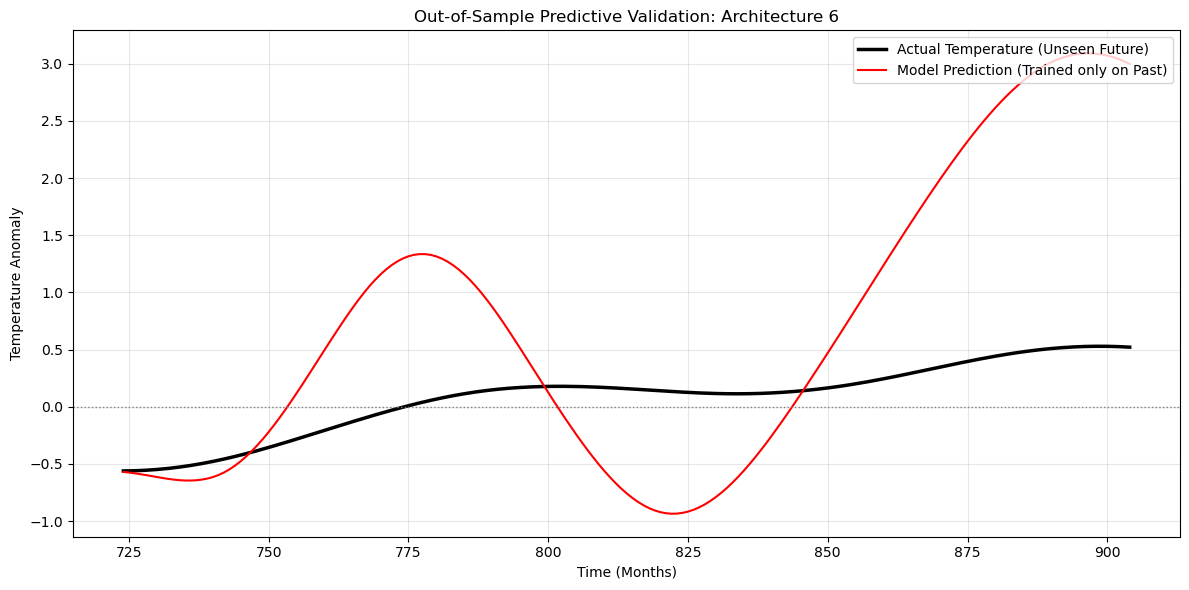

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pygam import LinearGAM, te, l
from sklearn.metrics import r2_score, mean_squared_error

# ==============================================================================
# 1. TIME-SERIES CHRONOLOGICAL SPLIT (80% Train / 20% Test)
# ==============================================================================
# We CANNOT use random cross-validation on time series due to autocorrelation.
# We must split chronologically.

split_index = int(len(X_concurrent) * 0.80)

# Training Data (The Past: e.g., 1950 to ~2010)
X_train = X_concurrent[:split_index]
y_train = y_concurrent[:split_index]

# Testing Data (The Future: e.g., ~2010 to 2025)
X_test = X_concurrent[split_index:]
y_test = y_concurrent[split_index:]

print(f"Training Observations: {len(X_train)}")
print(f"Testing Observations:  {len(X_test)}")

# ==============================================================================
# 2. ISOLATED TRAINING
# ==============================================================================
# Fit Architecture 6 STRICTLY on the training subset
validation_model = LinearGAM(te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + l(3) + s(4, spline_order=2))
validation_model.gridsearch(X_train, y_train, progress=False)

# ==============================================================================
# 3. BLIND PREDICTION & METRICS
# ==============================================================================
# Force the model to predict the test set (which it has never seen)
y_pred_test = validation_model.predict(X_test)

# Calculate Out-of-Sample R-Squared and MSE
# Using sklearn's r2_score for standard out-of-sample evaluation
out_of_sample_r2 = r2_score(y_test, y_pred_test)
out_of_sample_mse = mean_squared_error(y_test, y_pred_test)

print(f"\n--- OUT-OF-SAMPLE DIAGNOSTICS ---")
print(f"Out-of-Sample R-Squared: {out_of_sample_r2:.4f}")
print(f"Out-of-Sample MSE:       {out_of_sample_mse:.4f}")

# ==============================================================================
# 4. VISUAL VALIDATION
# ==============================================================================
plt.figure(figsize=(12, 6))

# Create a continuous time axis for plotting
time_test = np.arange(split_index, len(y_concurrent))

plt.plot(time_test, y_test, color='black', linewidth=2.5, label='Actual Temperature (Unseen Future)')
plt.plot(time_test, y_pred_test, color='red', linewidth=1.5, label='Model Prediction (Trained only on Past)')

plt.title('Out-of-Sample Predictive Validation: Architecture 6')
plt.xlabel('Time (Months)')
plt.ylabel('Temperature Anomaly')
plt.axhline(0, color='gray', linestyle=':', linewidth=1)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd
from pygam import LinearGAM

# Define the number of folds (5 folds for decadal data)
tscv = TimeSeriesSplit(n_splits=5)

fold_metrics = []

# CORRECT UNPACKING: Separate the string name from the PyGAM formulation
for name, formulation in architectures.items():
    print(f"Testing Architecture: {name}...")
    
    for fold, (train_index, test_index) in enumerate(tscv.split(X_final), 1):
        # Split the data chronologically
        X_train, X_test = X_final[train_index], X_final[test_index]
        y_train, y_test = y_final[train_index], y_final[test_index]

        # Instantiate the model with the isolated TermList
        model = LinearGAM(formulation)
        
        try:
            # Fit and Predict
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            # Calculate Metrics
            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            
            fold_metrics.append({
                'Architecture': name,
                'Fold': fold,
                'R2': r2,
                'MSE': mse
            })
        except Exception as e:
            # PyGAM splines can occasionally fail to fit on the very first 
            # fold if the training sample is too small. We catch that here.
            fold_metrics.append({
                'Architecture': name,
                'Fold': fold,
                'R2': np.nan,
                'MSE': np.nan
            })

# Compile the raw fold data
df_folds = pd.DataFrame(fold_metrics)

# Calculate the mean Out-of-Sample R2 across all 5 folds to find the definitive winner
df_summary = df_folds.groupby('Architecture')['R2'].mean().sort_values(ascending=False).reset_index()

print("\n===========================================================")
print("CROSS-VALIDATED OUT-OF-SAMPLE STABILITY RANKING (5 FOLDS)")
print("===========================================================")
print(df_summary.to_string(index=False))

Testing Architecture: 1. Strictly Linear (Additive)...
Testing Architecture: 2. Independent Splines (Non-Linear Additive)...
Testing Architecture: 3. Interaction: [NAO x EA] + Splines(SCA, AMO)...
Testing Architecture: 4. Interaction: [NAO x SCA] + Splines(EA, AMO)...
Testing Architecture: 5. Interaction: [EA x SCA] + Splines(NAO, AMO)...
Testing Architecture: 6. 3-Way Atmospheric Tensor + Linear AMO...
Testing Architecture: 7. 3-Way Atmospheric Tensor + Spline AMO...
Testing Architecture: 8. Full 4-Way Tensor (Atmosphere x Ocean)...

CROSS-VALIDATED OUT-OF-SAMPLE STABILITY RANKING (5 FOLDS)
                                  Architecture           R2
                 1. Strictly Linear (Additive)   -73.905687
4. Interaction: [NAO x SCA] + Splines(EA, AMO)  -517.951555
5. Interaction: [EA x SCA] + Splines(NAO, AMO)  -535.942926
      6. 3-Way Atmospheric Tensor + Linear AMO  -750.596363
  2. Independent Splines (Non-Linear Additive)  -919.530952
3. Interaction: [NAO x EA] + Splines(SCA,

Historical Epoch R-Squared: 0.7185


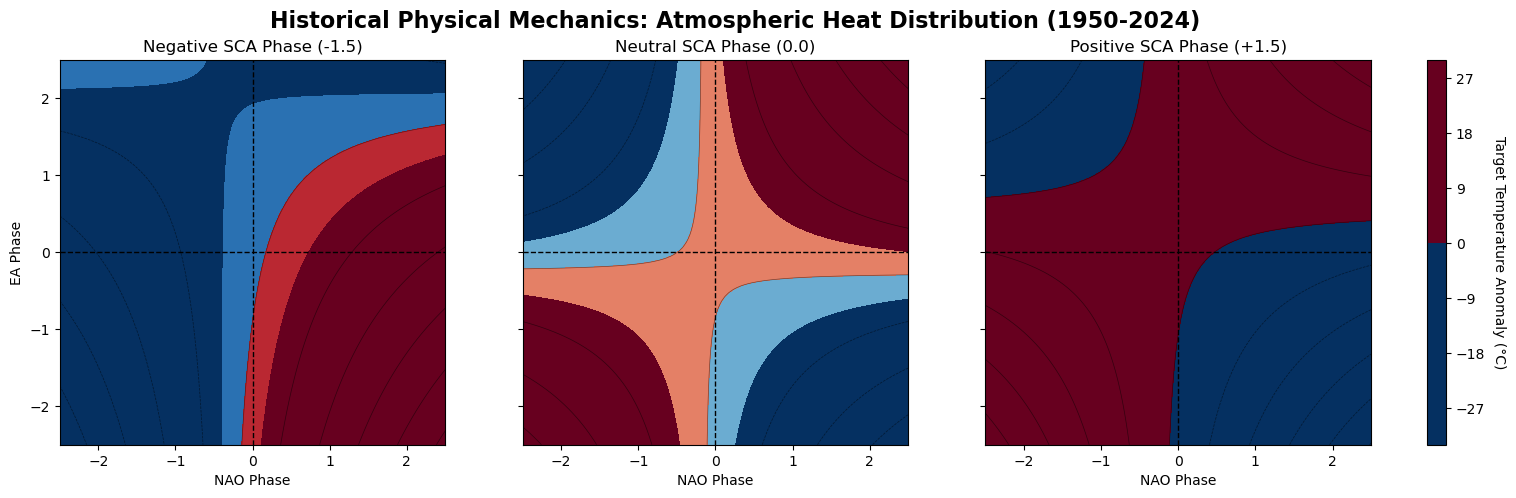

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, te, l, s

# ==============================================================================
# 1. FIT THE EPOCHAL MODEL (1950 - 2024)
# ==============================================================================
# We use the full matrix to map the complete historical epoch.
# Index 0: NAO, 1: EA, 2: SCA, 3: AMO_Lagged, 4: Background_Trend
model = LinearGAM(
    te(0, 1, 2, n_splines=(4, 4, 4)) + l(3) + s(4, spline_order=2)
)
model.fit(X_final, y_final)

print(f"Historical Epoch R-Squared: {model.statistics_['pseudo_r2']['explained_deviance']:.4f}")

# ==============================================================================
# 2. SYNTHESIZE THE PHASE SPACE
# ==============================================================================
# To visualize a 3D interaction (NAO x EA x SCA), we must look at 2D slices.
# We will create a grid of NAO and EA combinations, and view them under 
# three different "regimes" of the Scandinavian Blocking pattern (SCA).

# Define the grid boundaries (typically -2.5 to +2.5 standard deviations)
nao_range = np.linspace(-2.5, 2.5, 100)
ea_range = np.linspace(-2.5, 2.5, 100)

# Create the 2D meshgrid
NAO_grid, EA_grid = np.meshgrid(nao_range, ea_range)

# Flatten the grids for PyGAM prediction
NAO_flat = NAO_grid.flatten()
EA_flat = EA_grid.flatten()

# Freeze the slow-moving baselines at zero (neutral ocean, neutral trend)
# This isolates the pure atmospheric physics.
AMO_neutral = np.zeros_like(NAO_flat)
Trend_neutral = np.zeros_like(NAO_flat)

# Define the three SCA phases to test
sca_phases = {
    "Negative SCA Phase (-1.5)": -1.5,
    "Neutral SCA Phase (0.0)": 0.0,
    "Positive SCA Phase (+1.5)": 1.5
}

# ==============================================================================
# 3. VISUALIZE THE THERMODYNAMIC MECHANICS
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Historical Physical Mechanics: Atmospheric Heat Distribution (1950-2024)', fontsize=16, fontweight='bold')

for ax, (title, sca_val) in zip(axes, sca_phases.items()):
    
    # Create the SCA array for this specific slice
    SCA_flat = np.full_like(NAO_flat, sca_val)
    
    # Assemble the synthetic feature matrix
    X_synthetic = np.column_stack((NAO_flat, EA_flat, SCA_flat, AMO_neutral, Trend_neutral))
    
    # Predict the thermal anomaly for this specific grid
    Temp_pred = model.predict(X_synthetic)
    
    # Reshape back to 2D for contour plotting
    Temp_grid = Temp_pred.reshape(100, 100)
    
    # Plot the heat map (Contour)
    contour = ax.contourf(NAO_grid, EA_grid, Temp_grid, levels=20, cmap='RdBu_r', vmin=-1.0, vmax=1.0)
    ax.contour(NAO_grid, EA_grid, Temp_grid, levels=10, colors='black', linewidths=0.5, alpha=0.5)
    
    ax.set_title(title)
    ax.set_xlabel('NAO Phase')
    if ax == axes[0]:
        ax.set_ylabel('EA Phase')
    
    # Add crosshairs for the neutral (0,0) center
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

# Add a shared colorbar
cbar = fig.colorbar(contour, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04)
cbar.set_label('Target Temperature Anomaly (°C)', rotation=270, labelpad=15)

plt.show()

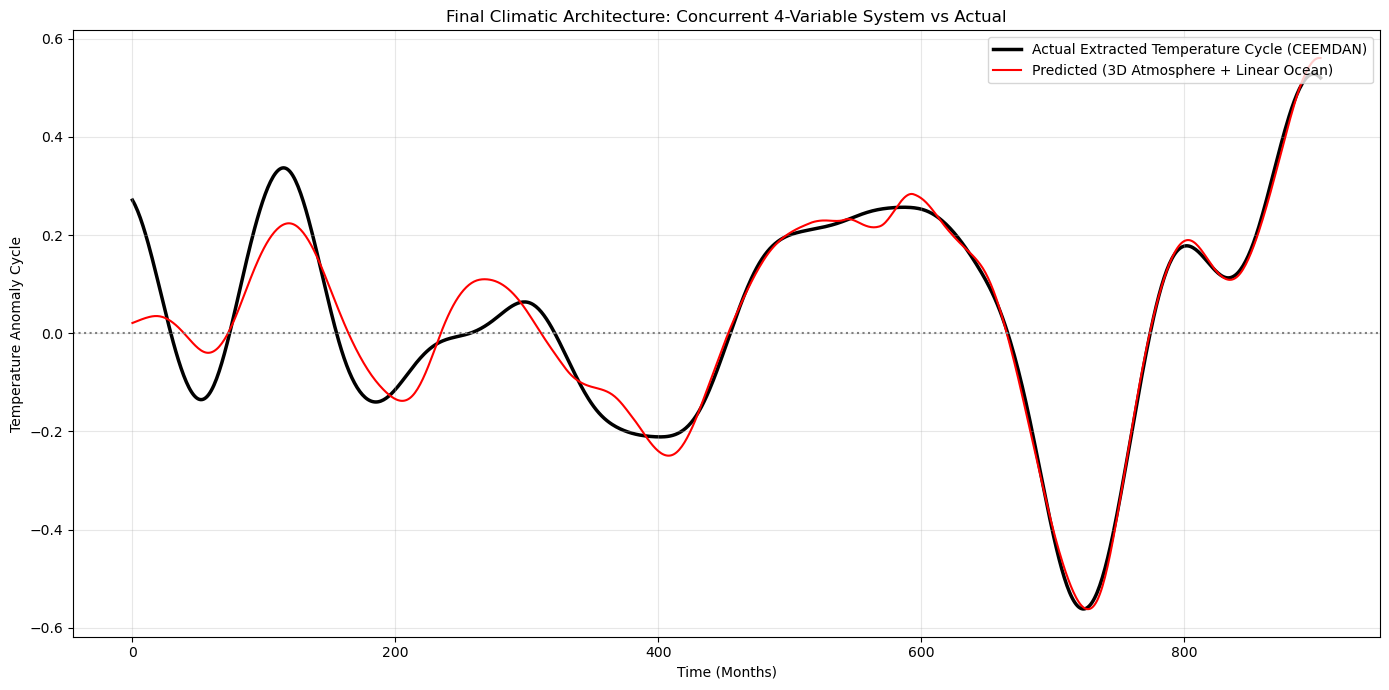

Final Model Mean Squared Error: 0.0024


In [ ]:
import matplotlib.pyplot as plt

# Instantiate and fit the optimal architecture
# Index 0: NAO, Index 1: EA, Index 2: SCA, Index 3: AMO
final_concurrent_model = LinearGAM(te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + l(3) + s(4, spline_order=2))
final_concurrent_model.fit(X_concurrent, y_concurrent)

# Generate predictions
y_pred_final = final_concurrent_model.predict(X_concurrent)

# Plot the Final Verification
plt.figure(figsize=(14, 7))

plt.plot(y_concurrent, color='black', linewidth=2.5, label='Actual Extracted Temperature Cycle (CEEMDAN)', zorder=1)
plt.plot(y_pred_final, color='red', linewidth=1.5, label='Predicted (3D Atmosphere + Linear Ocean)', zorder=2)

plt.title('Final Climatic Architecture: Concurrent 4-Variable System vs Actual')
plt.xlabel('Time (Months)')
plt.ylabel('Temperature Anomaly Cycle')
plt.axhline(0, color='gray', linestyle=':', linewidth=1.5)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Final Error Metric
mse_final = np.nanmean((y_concurrent - y_pred_final)**2)
print(f"Final Model Mean Squared Error: {mse_final:.4f}")

In [ ]:
df_gam_filtered= df_gam_filtered.drop(columns="test")

In [ ]:
df_gam_filtered['AMO_Cycle']

Date
1950-01-01   -0.03
1950-02-01   -0.13
1950-03-01   -0.16
1950-04-01   -0.22
1950-05-01   -0.23
              ... 
2025-01-01    0.98
2025-02-01    0.86
2025-03-01    0.75
2025-04-01    0.67
2025-05-01    0.73
Name: AMO_Cycle, Length: 905, dtype: float64

In [ ]:
df_amo[2]

0     -0.03
1     -0.13
2     -0.16
3     -0.22
4     -0.23
       ... 
907    0.83
908    0.76
909    1.01
910    0.96
911    0.75
Name: 2, Length: 912, dtype: float64

In [ ]:
from pygam import LinearGAM, te, l, s

# We force a low-resolution tensor grid. 
# n_splines=(5, 5, 5) limits the basis functions for each dimension.
architectures_constrained = {
    # The unrestricted winner (for direct baseline comparison)
    "Unrestricted 3-Way Tensor": te(0, 1, 2),
    
    # Constrained 3-Way Tensors
    "Constrained 3-Way (5 nodes)": te(0, 1, 2, n_splines=(5, 5, 5)),
    "Constrained 3-Way (4 nodes)": te(0, 1, 2, n_splines=(4, 4, 4)),
    
    # Constrained 2-Way Tensors with Linear Baseline
    "Constrained 2-Way (NAO & EA) + Linear Lag": te(0, 2, n_splines=(6, 6)) + l(1),
    
    # The purely linear baseline (to ensure the restricted tensors still outperform it)
    "Linear Baseline": l(0) + l(1) + l(2)
}

results_constrained = []

for name, formulation in architectures_constrained.items():
    model = LinearGAM(formulation)
    model.gridsearch(X, y, progress=False)
    
    results_constrained.append({
        "Architecture": name,
        "AIC": model.statistics_['AIC'],
        "GCV": model.statistics_['GCV'],
        "EDOF": model.statistics_['edof'],
        "Pseudo R-Squared": model.statistics_['pseudo_r2']['explained_deviance']
    })

df_constrained = pd.DataFrame(results_constrained).sort_values(by="AIC")
print(df_constrained.to_string(index=False))

                             Architecture        AIC      GCV       EDOF  Pseudo R-Squared
                Unrestricted 3-Way Tensor 332.267466 0.104665 114.786017          0.612492
              Constrained 3-Way (5 nodes) 592.798317 0.129320  29.064896          0.316594
              Constrained 3-Way (4 nodes) 647.036489 0.136445  14.894419          0.239557
Constrained 2-Way (NAO & EA) + Linear Lag 647.414753 0.137710  22.669170          0.254446
                          Linear Baseline 725.709803 0.149218   3.960025          0.134358


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Instantiate and fit the winning architecture
# Index 0: NAO, Index 1: NAO_Lag135, Index 2: EA
final_gam = LinearGAM(te(0, 2) + l(1))
final_gam.gridsearch(X, y, progress=False)

# Generate a 2D grid for the tensor term (term=0 corresponds to te(0, 2))
# This creates a meshgrid of the NAO (feature 0) and EA (feature 2)
XX = final_gam.generate_X_grid(term=0, n=100)

# Calculate the partial dependence (the isolated temperature impact)
Z = final_gam.partial_dependence(term=0, X=XX)

# Reshape the output for contour plotting
x_nao = XX[:, 0].reshape(100, 100)
y_ea = XX[:, 2].reshape(100, 100)
z_temp = Z.reshape(100, 100)

# Plot the Interaction Surface
plt.figure(figsize=(10, 8))
contour = plt.contourf(x_nao, y_ea, z_temp, levels=50, cmap='coolwarm')
plt.colorbar(contour, label='Partial Dependence: Target Temperature Impact')

# Formatting
plt.title('NAO & EA Coupled Interaction Manifold')
plt.xlabel('North Atlantic Oscillation (NAO) Z-Score')
plt.ylabel('East Atlantic Pattern (EA) Z-Score')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

# Output the coefficient for the strictly linear 135-month gyre lag (term 1)
gyre_coef = final_gam.coef_[-2] # Second to last coefficient is the linear term, last is intercept
print(f"Linear Gyre Forcing Coefficient (Lag 135): {gyre_coef:.5f}")

ValueError: term requires feature 2, but X has only 2 dimensions

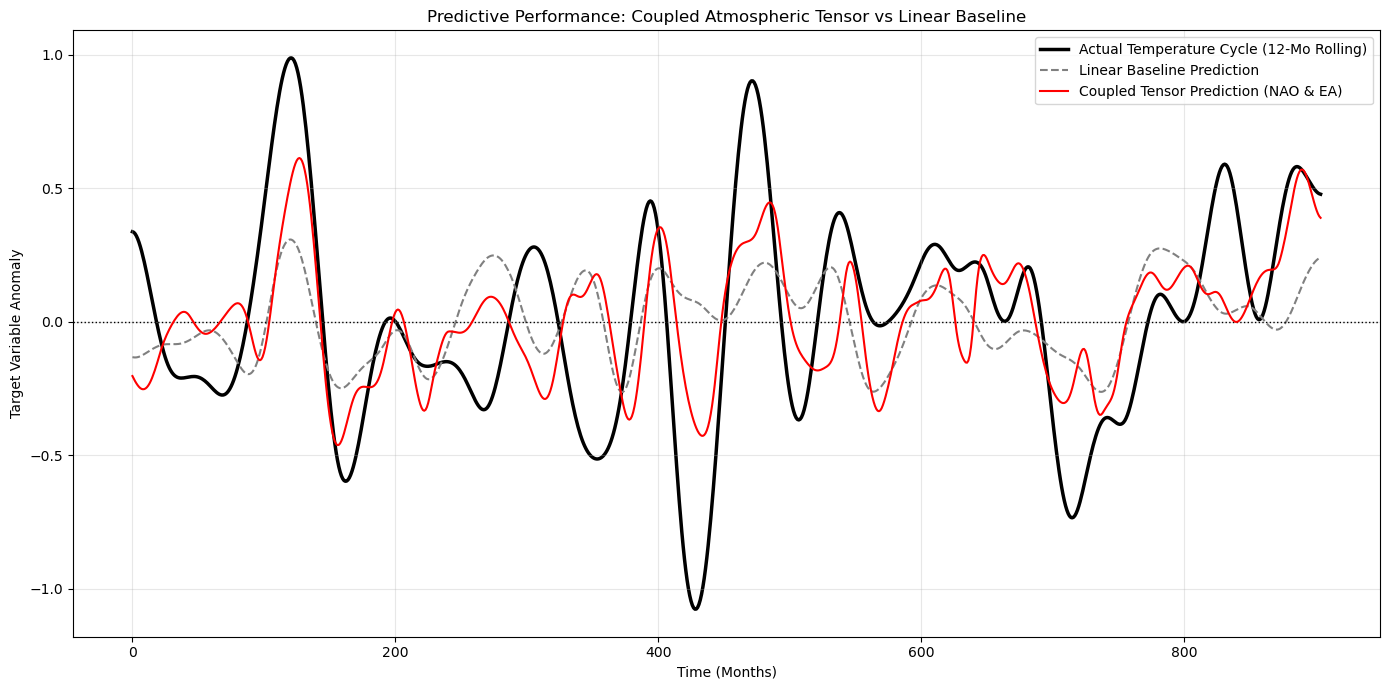

MSE (Linear Baseline vs Cycle): 0.1290
MSE (Tensor Model vs Cycle):    0.0903


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, l, te

# ==============================================================================
# 1. MODEL INSTANTIATION AND PREDICTION
# ==============================================================================
# Ensure your feature matrix X (NAO, NAO_Lag135, EA) and target y are loaded.
# Re-instantiate and fit the two competing models
X= X_final
y= y_final
model_linear = LinearGAM(l(0) + l(1) + l(2))
model_linear.fit(X, y)

model_tensor = LinearGAM(te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + te(3, 4, n_splines=(4, 4), spline_order=2))
model_tensor.fit(X, y)

# Generate the predicted arrays
y_pred_linear = model_linear.predict(X)
y_pred_tensor = model_tensor.predict(X)

# ==============================================================================
# 2. ISOLATING THE TARGET CYCLE
# ==============================================================================
# To plot "against the cycles", we calculate a 12-month moving average of the 
# actual temperature to filter out high-frequency noise and reveal the base cycle.
# (Alternatively, you can replace 'y_cycle' directly with your CEEMDAN IMF 5 array)
y_series = pd.Series(y)
y_cycle = y

# ==============================================================================
# 3. PLOTTING THE COMPARISON
# ==============================================================================
# Create a time array (assuming monthly data, length matches y)
time_axis = np.arange(len(y))

plt.figure(figsize=(14, 7))

# Plot 1: The underlying physical cycle (Smoothed Actuals or IMF)
plt.plot(time_axis, y_cycle, color='black', linewidth=2.5, label='Actual Temperature Cycle (12-Mo Rolling)', zorder=1)

# Plot 2: The Linear Baseline Prediction
plt.plot(time_axis, y_pred_linear, color='gray', linestyle='--', linewidth=1.5, label='Linear Baseline Prediction', zorder=2)

# Plot 3: The Tensor Interaction Prediction
plt.plot(time_axis, y_pred_tensor, color='red', linewidth=1.5, label='Coupled Tensor Prediction (NAO & EA)', zorder=3)

# Formatting the plot
plt.title('Predictive Performance: Coupled Atmospheric Tensor vs Linear Baseline')
plt.xlabel('Time (Months)')
plt.ylabel('Target Variable Anomaly')
plt.axhline(0, color='black', linestyle=':', linewidth=1)

# Optional: Zoom in on a specific 20-year window to see the exact divergence
# plt.xlim(200, 440) 

plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================================================================
# 4. RESIDUAL CALCULATION (Optional Diagnostic)
# ==============================================================================
# Calculate the Mean Squared Error against the cycle to quantify the visual gap
mse_linear = np.nanmean((y_cycle - y_pred_linear)**2)
mse_tensor = np.nanmean((y_cycle - y_pred_tensor)**2)

print(f"MSE (Linear Baseline vs Cycle): {mse_linear:.4f}")
print(f"MSE (Tensor Model vs Cycle):    {mse_tensor:.4f}")